# PetFinder — Modelo Tabular
**Maestría en Ciencia de Datos — Laboratorio de Implementación**

Este notebook cubre tres etapas en secuencia:
1. **Baseline** — LightGBM con features crudas, sin ingeniería
2. **Feature Engineering iterativo** — creación y evaluación incremental de variables
3. **Tuning** — optimización de hiperparámetros con Optuna

**Métrica principal:** Cohen's Kappa Cuadrático (QWK)  
**Métricas de seguimiento:** accuracy por clase, F1 macro  
**Validación:** StratifiedKFold(n_splits=5)

---
### Arquitectura anti-leakage

> **Regla de oro:** toda transformación que aprende parámetros de los datos  
> (target encoding, aggregations, TF-IDF/SVD) se recalcula **dentro de cada fold**,  
> usando exclusivamente los datos de entrenamiento de ese fold.  
>  
> Esto garantiza que el fold de validación nunca influye en los valores  
> que el modelo recibe durante su evaluación.

El punto de entrada para cada experimento es `run_cv(...)`.  
Los parámetros `te_cols`, `agg_config` y `tfidf_col` controlan  
qué transformaciones riesgosas se ejecutan dentro del loop.  
Las features "seguras" (flags, logs, bins) se pre-calculan fuera como siempre.

---

# 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
import re
import time
import datetime
from collections import defaultdict

# Modelado
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import (
    cohen_kappa_score, accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder, TargetEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import TargetEncoder

# Tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})
sns.set_palette('Set2')
PALETTE = sns.color_palette('Set2', 5)

SEED    = 42
TARGET  = 'AdoptionSpeed'
N_FOLDS = 5
np.random.seed(SEED)

print('Librerías cargadas OK')
print(f'LightGBM version: {lgb.__version__}')

Librerías cargadas OK
LightGBM version: 4.6.0


In [2]:
input_path = '/kaggle/input/competitions/petfinder-adoption-prediction/'

train  = pd.read_csv(os.path.join(input_path, 'train/train.csv'))
breeds = pd.read_csv(os.path.join(input_path, 'breed_labels.csv'))
colors = pd.read_csv(os.path.join(input_path, 'color_labels.csv'))
states = pd.read_csv(os.path.join(input_path, 'state_labels.csv'))

print(f'Train: {train.shape[0]:,} filas × {train.shape[1]} columnas')
train.head(2)

Train: 14,993 filas × 24 columnas


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0


---
# 1. Preprocesamiento base

Limpieza de `Name` y `Description`, merge con labels de razas, y variables derivadas.  

In [3]:
df = train.copy()

# ── Limpieza de Name ──────────────────────────────────────────────────────────
invalid_kw = ['adoption','urgent','none','unknown','name','nan','n/a','yet','help']
df['Name'] = df['Name'].astype(str).str.lower().str.strip()
mask_name = (
    df['Name'].str.contains('|'.join(invalid_kw), na=False) |
    (df['Name'].str.len() <= 1) |
    df['Name'].str.match(r'^[^a-zA-Z0-9]+$') |
    df['Name'].str.isnumeric() |
    (df['Name'] == 'nan')
)
df.loc[mask_name, 'Name'] = np.nan

# ── Limpieza de Description ───────────────────────────────────────────────────
generic_phrases = ['adoption','to be adopted','looking for a home','please','available','urgent']
mask_kw    = df['Description'].str.lower().str.contains('|'.join(generic_phrases), na=False)
mask_short = df['Description'].str.len() < 40
df.loc[mask_kw & mask_short, 'Description'] = np.nan
df['Description'] = df['Description'].str.strip()
df.loc[df['Description'].str.len() < 5, 'Description'] = np.nan

# ── Merge con labels de razas ─────────────────────────────────────────────────
breeds_ = breeds.copy()
breeds_['Type']    = breeds_['Type'].astype(int)
breeds_['BreedID'] = breeds_['BreedID'].astype(int)
df['Type']   = df['Type'].astype(int)
df['Breed1'] = df['Breed1'].astype(int)
df['Breed2'] = df['Breed2'].astype(int)

df = df.merge(breeds_, left_on=['Type','Breed1'], right_on=['Type','BreedID'], how='left')
df.rename(columns={'BreedName': 'Breed1Name'}, inplace=True)
df.drop(columns=['BreedID'], inplace=True)

df = df.merge(breeds_, left_on=['Type','Breed2'], right_on=['Type','BreedID'], how='left')
df.rename(columns={'BreedName': 'Breed2Name'}, inplace=True)
df.drop(columns=['BreedID'], inplace=True)

# ── Mapeos de color y estado ──────────────────────────────────────────────────
color_map = colors.set_index('ColorID')['ColorName'].to_dict()
state_map = states.set_index('StateID')['StateName'].to_dict()
df['StateName']   = df['State'].map(state_map)
df['Color1Label'] = df['Color1'].map(color_map)

# ── Deduplicación ─────────────────────────────────────────────────────────────
df = df.sort_values(by='PetID').drop_duplicates(
    subset=df.columns.difference(['PetID']), keep='first'
)

print(f'Dataset preprocesado: {df.shape}')
df.head(2)

Dataset preprocesado: (14982, 28)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,Breed1Name,Breed2Name,StateName,Color1Label
3057,2,ollie,6,265,0,1,4,7,0,2,...,a0f2046e9c9ee30051e07a8e2f5fb392,0,Ollie was rescued from the construction site b...,0008c5398,6.0,3,Domestic Medium Hair,NaN,Selangor,Yellow
4839,1,cutie pie,2,307,0,2,1,2,7,2,...,fd970cc91d06d82eebf046340137b272,0,went to teluk kumba kuanthai restaurant saw th...,000a290e4,2.0,2,Mixed Breed,NaN,Pulau Pinang,Black


---
# 2. Infraestructura de evaluación

### La función `run_cv` — punto de entrada principal

Función que ejecuta todo el pipeline desde el preprocesamiento de datos hasta la ejecución del modelo.

**Parámetros siempre presentes:**
- `X` — DataFrame con las features. Puede incluir columnas auxiliares (ej. `RescuerID`, `Description`) que se usan para calcular encodings internamente pero no entran directamente al modelo si son de tipo texto o ID.
- `y` — Serie con el target.
- `params` — dict con hiperparámetros de LightGBM.

**Parámetros anti-leakage (opcionales):**

| Parámetro | Qué hace | Cuándo usarlo |
|---|---|---|
| `te_cols` | Target encoding dentro del fold | Variables de alta cardinalidad (Breed1, RescuerID) |
| `te_smoothing` | Suavizado del TE (default='auto') | Ajustar si hay pocas observaciones por categoría |
| `agg_config` | Aggregations por grupo dentro del fold | Estadísticas de comportamiento (mean_age, mean_fee por rescatista) |
| `tfidf_col` | TF-IDF + SVD sobre texto dentro del fold | Columna de descripción de texto libre |
| `n_svd` | Componentes SVD (default=15) | Reducir si hay poca varianza explicada |

In [4]:
def qwk(y_true, y_pred):
    """Cohen's Kappa Cuadrático — métrica principal del problema."""
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

def run_cv(
    X, y, params,
    cat_features=None,
    n_folds=N_FOLDS,
    verbose=True,
    experiment_name='exp',
    # ── Parámetros anti-leakage ───────────────────────────────────────────────
    te_cols=None,
    te_smoothing=50,
    agg_config=None,
    agg_smoothing=0,
    aux_cols=None,
):
    """
    Entrena LightGBM con StratifiedKFold(5) y retorna métricas OOF.

    Toda transformación que depende del target o de estadísticas globales
    se recalcula DENTRO de cada fold usando solo datos de train.
    Esto garantiza que el fold de validación nunca contamina las features.

    Parámetros
    ----------
    X : pd.DataFrame
        Features. Puede incluir columnas auxiliares para TE/agg/tfidf.
        Esas columnas también entrarán al modelo a menos que las excluyas
        explícitamente de CURRENT_FEATURES.
    y : pd.Series
        Target (AdoptionSpeed).
    params : dict
        Hiperparámetros de LightGBMClassifier.
    cat_features : list[str] | None
        Columnas categóricas para LightGBM. Si None, usa 'auto'.
    n_folds : int
        Número de folds del StratifiedKFold.
    verbose : bool
        Si True, imprime métricas por fold.
    experiment_name : str
        Nombre del experimento para el tracker.
    te_cols : list[str] | None
        Columnas sobre las que aplicar target encoding dentro del fold.
        Por cada col en te_cols, se genera una nueva columna col+'_te'.
        La columna original sigue estando disponible en X.
    te_smoothing : float | 'auto'
        Factor de suavizado del TargetEncoder de sklearn.
        Con 'auto' usa empirical Bayes. Con un float (ej: 50) equivale
        al Laplace smoothing anterior: mayor valor → encoding se acerca
        más a la media global. Usar 30-100 para columnas de alta
        cardinalidad como RescuerID.
    agg_config : dict | None
        Aggregations por grupo a calcular dentro del fold.
        Formato esperado:
            {
                'RescuerID': {
                    'resc_mean_age'  : ('Age',      'mean'),
                    'resc_mean_fee'  : ('Fee',      'mean'),
                    'resc_pct_free'  : ('IsFree',   'mean'),
                }
            }
        La clave del dict es la columna de agrupación.
        Los valores son dicts: {nombre_nueva_col: (col_fuente, función_agg)}.
        Categorías que aparecen en val pero no en train → fillna con media de train.
    agg_smoothing : float
        Factor de suavizado para las aggregations por grupo.
    aux_cols : list[str] | None
        Columnas que viajan en X para ser usadas por agg_config o tfidf_col
        pero que no son features del modelo (strings, IDs, etc.).

    Retorna
    -------
    dict con claves:
        'name'      : nombre del experimento
        'qwk_mean'  : QWK medio de los 5 folds
        'qwk_std'   : desvío estándar del QWK
        'acc_mean'  : accuracy media
        'f1_mean'   : F1 macro media
        'oof_preds' : predicciones OOF (array de largo len(y))
        'feat_imp'  : DataFrame con importancia gain y split por feature
        'fold_qwk'  : lista con QWK por fold (para diagnóstico de varianza)

    Notas sobre el TargetEncoder de sklearn
    ----------------------------------------
    - fit_transform(X_tr, y_tr) aplica cross-fitting interno (cv=5 por
      defecto) para evitar leakage dentro del set de train.
    - transform(X_val) usa los encodings del fit completo sobre X_tr,
      lo que es correcto: el fold de val nunca influye en el encoding.
    - NO se usa fit(X_tr).transform(X_tr): eso sí genera leakage
      (sklearn mismo lo advierte en la documentación).
    - target_type='continuous' fuerza una sola columna de salida por
      feature, en lugar de n_clases columnas (comportamiento multiclass).
      Esto es preferible para pasar a LightGBM con un target ordinal.
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    fold_qwk, fold_acc, fold_f1 = [], [], []
    oof_preds = np.zeros(len(y))
    oof_proba  = np.zeros((len(y), 5))

    # Se inicializan en el primer fold cuando ya sabemos el shape final de X
    feature_names  = None
    feat_imp_gain  = None
    feat_imp_split = None

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr  = X.iloc[tr_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_tr  = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        # ── PASO 1: Target Encoding con sklearn.TargetEncoder ────────────────
        # fit_transform en train usa cross-fitting interno (cv=5 por defecto)
        # para evitar leakage. transform en val usa los encodings del fit
        # completo sobre train → correcto, sin contaminación del fold de val.
        #
        # IMPORTANTE: NO usar fit(X_tr, y_tr).transform(X_tr) — eso sí leakea.
        # fit_transform != fit + transform en este encoder (ver docs de sklearn).
        if te_cols:
            te = TargetEncoder(
                smooth=te_smoothing,      # Laplace smoothing; 'auto' = empirical Bayes
                target_type='continuous', # una sola col de salida por feature (no multiclass)
                cv=5,                     # folds del cross-fitting interno
                random_state=SEED,
            )
            # fit_transform aplica cross-fitting internamente sobre X_tr/y_tr
            te_tr  = te.fit_transform(X_tr[te_cols], y_tr)
            # transform usa los encodings del fit completo sobre train
            te_val = te.transform(X_val[te_cols])

            te_col_names = [f'{col}_te' for col in te_cols]
            for i, col_name in enumerate(te_col_names):
                X_tr[col_name]  = te_tr[:, i]
                X_val[col_name] = te_val[:, i]

        # ── PASO 2: Aggregations por grupo (solo con datos de train) ─────────
        if agg_config:
            for group_col, aggs in agg_config.items():
                
                # Smoothing: dict por group_col o valor global para todos
                if isinstance(agg_smoothing, dict):
                    sm = agg_smoothing.get(group_col, 0)  # 0 si no está definido
                else:
                    sm = agg_smoothing
                    
                # ── Asegurar que group_col es unidimensional antes de agrupar ────
                # Merges sucesivos pueden duplicar columnas si group_col aparece
                # tanto como clave de agrupación como columna fuente en otro agg.
                if isinstance(X_tr.index, pd.MultiIndex) or X_tr[group_col].ndim != 1:
                    X_tr[group_col] = X_tr[group_col].iloc[:, 0]
                    X_val[group_col] = X_val[group_col].iloc[:, 0]
                
                # ── Eliminar columnas duplicadas que pudo introducir el merge ────
                X_tr = X_tr.loc[:, ~X_tr.columns.duplicated()]
                X_val = X_val.loc[:, ~X_val.columns.duplicated()]
                
                agg_kwargs = {
                    new_name: pd.NamedAgg(column=src_col, aggfunc=func)
                    for new_name, (src_col, func) in aggs.items()
                }
        
                # ── Cross-fitting sobre train (misma lógica que TargetEncoder) ────
                # Cada fila de train se encodea con estadísticas calculadas
                # sin ella misma, usando los otros subfolds.
                n_cv = 5
                inner_skf = KFold(n_splits=n_cv, shuffle=True, random_state=SEED)
                new_col_names = list(aggs.keys())
        
                # Inicializar columnas en X_tr con NaN
                for new_name in new_col_names:
                    X_tr[new_name] = np.nan
        
                for inner_tr_idx, inner_val_idx in inner_skf.split(X_tr):
                    inner_X_tr = X_tr.iloc[inner_tr_idx]
        
                    agg_df_inner = inner_X_tr.groupby(group_col).agg(**agg_kwargs)
                    agg_df_inner['__n__'] = inner_X_tr.groupby(group_col).size()
                    agg_df_inner = agg_df_inner.reset_index()
        
                    global_means_inner = {
                        new_name: agg_df_inner[new_name].mean()
                        for new_name in new_col_names
                    }
        
                    # Mergear solo sobre las filas del subfold de val interno
                    inner_val_rows = X_tr.iloc[inner_val_idx][[group_col]].merge(
                        agg_df_inner, on=group_col, how='left'
                    )
        
                    for new_name in new_col_names:
                        gm = global_means_inner[new_name]
                        n  = inner_val_rows['__n__']
                        vals = (
                            (inner_val_rows[new_name] * n + gm * sm)
                            / (n + sm)
                        ).fillna(gm)
                        X_tr.iloc[inner_val_idx, X_tr.columns.get_loc(new_name)] = vals.values
        
                # ── Val: fit sobre todo train, transform sobre val ────────────────
                # Igual que TargetEncoder.transform(): usa estadísticas del fold
                # completo de train, sin ver val en ningún momento.
                agg_df_full = X_tr.groupby(group_col).agg(**agg_kwargs)
                agg_df_full['__n__'] = X_tr.groupby(group_col).size()
                agg_df_full = agg_df_full.reset_index()
        
                global_means_full = {
                    new_name: agg_df_full[new_name].mean()
                    for new_name in new_col_names
                }
        
                X_val = X_val.merge(agg_df_full, on=group_col, how='left')
                for new_name in new_col_names:
                    gm = global_means_full[new_name]
                    n  = X_val['__n__']
                    X_val[new_name] = (
                        (X_val[new_name] * n + gm * sm)
                        / (n + sm)
                    ).fillna(gm)
                X_val = X_val.drop(columns=['__n__'])
        
            agg_group_cols = list(agg_config.keys())
            X_tr  = X_tr.drop(columns=agg_group_cols, errors='ignore')
            X_val = X_val.drop(columns=agg_group_cols, errors='ignore')

        # ── DROP de columnas auxiliares globales ──────────────────────────────
        # Columnas que viajan en X para ser usadas por agg_config o tfidf_col
        # pero que no son features del modelo (strings, IDs, etc.)
        if aux_cols:
            X_tr  = X_tr.drop(columns=aux_cols, errors='ignore')
            X_val = X_val.drop(columns=aux_cols, errors='ignore')

        # ── PASO 4: Inicializar acumuladores en el primer fold ────────────────
        # (no antes, porque el shape final de X depende de TE/agg/tfidf)
        if fold == 0:
            feature_names  = list(X_tr.columns)
            n_feat         = len(feature_names)
            feat_imp_gain  = np.zeros(n_feat)
            feat_imp_split = np.zeros(n_feat)

        # ── PASO 4.5: Restaurar dtypes categóricos ───────────────────────────
        # Los merges y transformaciones pueden cambiar el dtype de columnas
        # categóricas (ej: int → float por NaNs introducidos en el join).
        # LightGBM requiere que las columnas declaradas en categorical_feature
        # sean int o category, nunca float u object.
        if cat_features:
            for col in cat_features:
                for df_ in [X_tr, X_val]:
                    if col in df_.columns:
                        df_[col] = df_[col].fillna(-1).astype(int)

        # ── PASO 5: Entrenamiento ─────────────────────────────────────────────
        model = lgb.LGBMClassifier(**params, random_state=SEED)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            categorical_feature=cat_features or 'auto',
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(period=-1),
            ]
        )

        proba = model.predict_proba(X_val)        # ← agregar
        oof_proba[val_idx] = proba                # ← agregar
        preds = proba.argmax(axis=1)             # ← reemplaza model.predict(X_val)
        oof_preds[val_idx] = preds
        fold_qwk.append(qwk(y_val, preds))
        fold_acc.append(accuracy_score(y_val, preds))
        fold_f1.append(f1_score(y_val, preds, average='macro'))
        feat_imp_gain  += model.booster_.feature_importance(importance_type='gain')  / n_folds
        feat_imp_split += model.booster_.feature_importance(importance_type='split') / n_folds

        if verbose:
            print(f'  Fold {fold+1}: QWK={fold_qwk[-1]:.4f}  '
                  f'Acc={fold_acc[-1]:.4f}  F1={fold_f1[-1]:.4f}  '
                  f'(best iter={model.best_iteration_})')

    feat_imp_df = pd.DataFrame({
        'feature': feature_names,
        'gain':    feat_imp_gain,
        'split':   feat_imp_split,
    }).sort_values('gain', ascending=False).reset_index(drop=True)

    results = {
        'name'     : experiment_name,
        'qwk_mean' : np.mean(fold_qwk),
        'qwk_std'  : np.std(fold_qwk),
        'acc_mean' : np.mean(fold_acc),
        'f1_mean'  : np.mean(fold_f1),
        'oof_preds': oof_preds,
        'oof_proba': oof_proba,
        'feat_imp' : feat_imp_df,
        'fold_qwk' : fold_qwk,
    }

    if verbose:
        print(f'\n  ► {experiment_name}')
        print(f'    QWK  {results["qwk_mean"]:.4f} ± {results["qwk_std"]:.4f}')
        print(f'    Acc  {results["acc_mean"]:.4f}')
        print(f'    F1   {results["f1_mean"]:.4f}')

    return results


class ExperimentTracker:
    """Registra y compara todos los experimentos del notebook."""
    def __init__(self):
        self.records = []

    def log(self, result):
        self.records.append({
            'Experimento': result['name'],
            'QWK'        : round(result['qwk_mean'], 4),
            'QWK±std'    : round(result['qwk_std'],  4),
            'Accuracy'   : round(result['acc_mean'],  4),
            'F1 macro'   : round(result['f1_mean'],   4),
        })

    def table(self):
        df_t = pd.DataFrame(self.records)
        return df_t.sort_values('QWK', ascending=False).reset_index(drop=True)

    def plot(self):
        df_t = self.table()
        fig, ax = plt.subplots(figsize=(10, 0.55 * len(df_t) + 2))
        colors_bar = [PALETTE[0] if i == 0 else PALETTE[2] for i in range(len(df_t))]
        bars = ax.barh(df_t['Experimento'][::-1], df_t['QWK'][::-1],
                       color=colors_bar[::-1], edgecolor='white')
        ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
        ax.set_title('Comparación de experimentos — QWK (CV)', fontweight='bold')
        ax.set_xlabel('QWK medio (5-fold)')
        ax.set_xlim(0, df_t['QWK'].max() + 0.05)
        plt.tight_layout()
        plt.show()


tracker = ExperimentTracker()
print('Infraestructura lista.')

Infraestructura lista.


In [5]:
def plot_results(y_true, oof_preds, title=''):
    """Matriz de confusión normalizada por fila + distribución real vs. predicha."""
    y_true = np.asarray(y_true).astype(int)
    preds  = np.asarray(oof_preds).astype(int)
    labels  = ['0\nMismo día', '1\n1-7d', '2\n8-30d', '3\n31-90d', '4\nNo adopt.']
    classes = [0, 1, 2, 3, 4]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    cm = confusion_matrix(y_true, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    axes[0].set_title(
        f'Matriz de confusión (recall por fila)\n'
        f'QWK={qwk(y_true, preds):.4f}  Acc={accuracy_score(y_true, preds):.4f}'
    )
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicho')

    x = np.arange(len(classes))
    w = 0.35
    r_counts = [(y_true == c).sum() for c in classes]
    p_counts = [(preds  == c).sum() for c in classes]
    axes[1].bar(x - w/2, r_counts, w, label='Real',    color=PALETTE[0], edgecolor='white')
    axes[1].bar(x + w/2, p_counts, w, label='Predicho', color=PALETTE[2], edgecolor='white')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([str(c) for c in classes])
    axes[1].set_title('Distribución real vs. predicha')
    axes[1].set_ylabel('Cantidad')
    axes[1].legend()

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(classification_report(
        y_true, preds,
        target_names=['0-MismoDía', '1-1ªSemana', '2-1erMes', '3-2do3erMes', '4-NoAdopt.']
    ))


def plot_importance(feat_imp_df, top_n=20, title='Feature Importance'):
    """
    Gráfico de importancia de features: gain (izquierda) y split (derecha).

    Gain = reducción total de impureza aportada por la feature → mide calidad.
    Split = número de veces que la feature aparece en un split → mide frecuencia.
    Una feature con alto gain y bajo split es muy discriminante pero poco usada.
    """
    top              = feat_imp_df.sort_values('gain', ascending=False).head(top_n)
    features_ordered = top['feature'].values[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(14, top_n * 0.3 + 1), sharey=True)

    axes[0].barh(features_ordered, top['gain'].values[::-1],
                 color=PALETTE[0], edgecolor='white')
    axes[0].set_title('Gain', fontweight='bold')
    axes[0].set_xlabel('Importancia media (gain)')

    axes[1].barh(features_ordered, top['split'].values[::-1],
                 color=PALETTE[2], edgecolor='white')
    axes[1].set_title('Split', fontweight='bold')
    axes[1].set_xlabel('Importancia media (split)')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def delta(result_new, result_ref):
    """Imprime el delta de QWK entre el experimento nuevo y la referencia."""
    d    = result_new['qwk_mean'] - result_ref['qwk_mean']
    sign = '+' if d >= 0 else ''
    print(f'  ΔQWK vs. referencia: {sign}{d:.4f}')
    return d


print('Funciones de visualización listas.')

Funciones de visualización listas.


---
# 3. Baseline — LightGBM sin Feature Engineering

Establece el piso de performance con features originales crudas.  
Cualquier experimento que no supere este número descarta sus features. Comenzaremos con todas las variables numéricas, y las variables categóricas que no tengan una cardinalidad alta (RescuerID, Name, Description).

In [6]:
BASELINE_FEATURES = [
    # Numéricas originales
    'Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt',
    # Categóricas ordinales (como enteros)
    'Type', 'Gender', 'Color1', 'Color2', 'Color3',
    'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized',
    'Health', 'State', 'Breed1', 'Breed2',
]

BASELINE_PARAMS = {
    'objective'        : 'multiclass',
    'num_class'        : 5,
    'metric'           : 'multi_logloss',
    'n_estimators'     : 2000,
    'learning_rate'    : 0.05,
    'num_leaves'       : 63,
    'min_child_samples': 20,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.1,
    'verbose'          : -1,
}

X_base = df[BASELINE_FEATURES].copy()
y      = df[TARGET].copy()

print(f'Shape baseline: {X_base.shape}')

Shape baseline: (14982, 19)


In [7]:
print('=' * 55)
print('EXPERIMENTO 0: BASELINE')
print('=' * 55)

result_baseline = run_cv(X = X_base, 
                         y = y, 
                         params = BASELINE_PARAMS, 
                         experiment_name='00_baseline')
tracker.log(result_baseline)

EXPERIMENTO 0: BASELINE
  Fold 1: QWK=0.3460  Acc=0.4097  F1=0.3194  (best iter=82)
  Fold 2: QWK=0.3499  Acc=0.4057  F1=0.3146  (best iter=55)
  Fold 3: QWK=0.3296  Acc=0.4042  F1=0.3126  (best iter=64)
  Fold 4: QWK=0.3705  Acc=0.4122  F1=0.3207  (best iter=64)
  Fold 5: QWK=0.3741  Acc=0.4142  F1=0.3347  (best iter=75)

  ► 00_baseline
    QWK  0.3540 ± 0.0164
    Acc  0.4092
    F1   0.3204


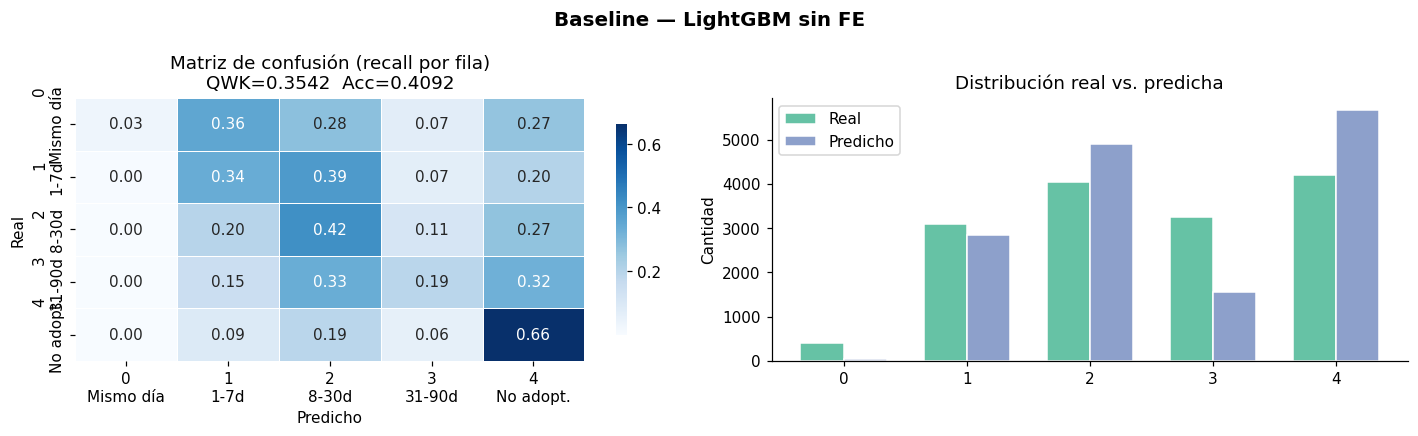

              precision    recall  f1-score   support

  0-MismoDía       0.35      0.03      0.05       410
  1-1ªSemana       0.37      0.34      0.35      3090
    2-1erMes       0.34      0.42      0.38      4035
 3-2do3erMes       0.40      0.19      0.26      3255
  4-NoAdopt.       0.49      0.66      0.56      4192

    accuracy                           0.41     14982
   macro avg       0.39      0.33      0.32     14982
weighted avg       0.40      0.41      0.39     14982



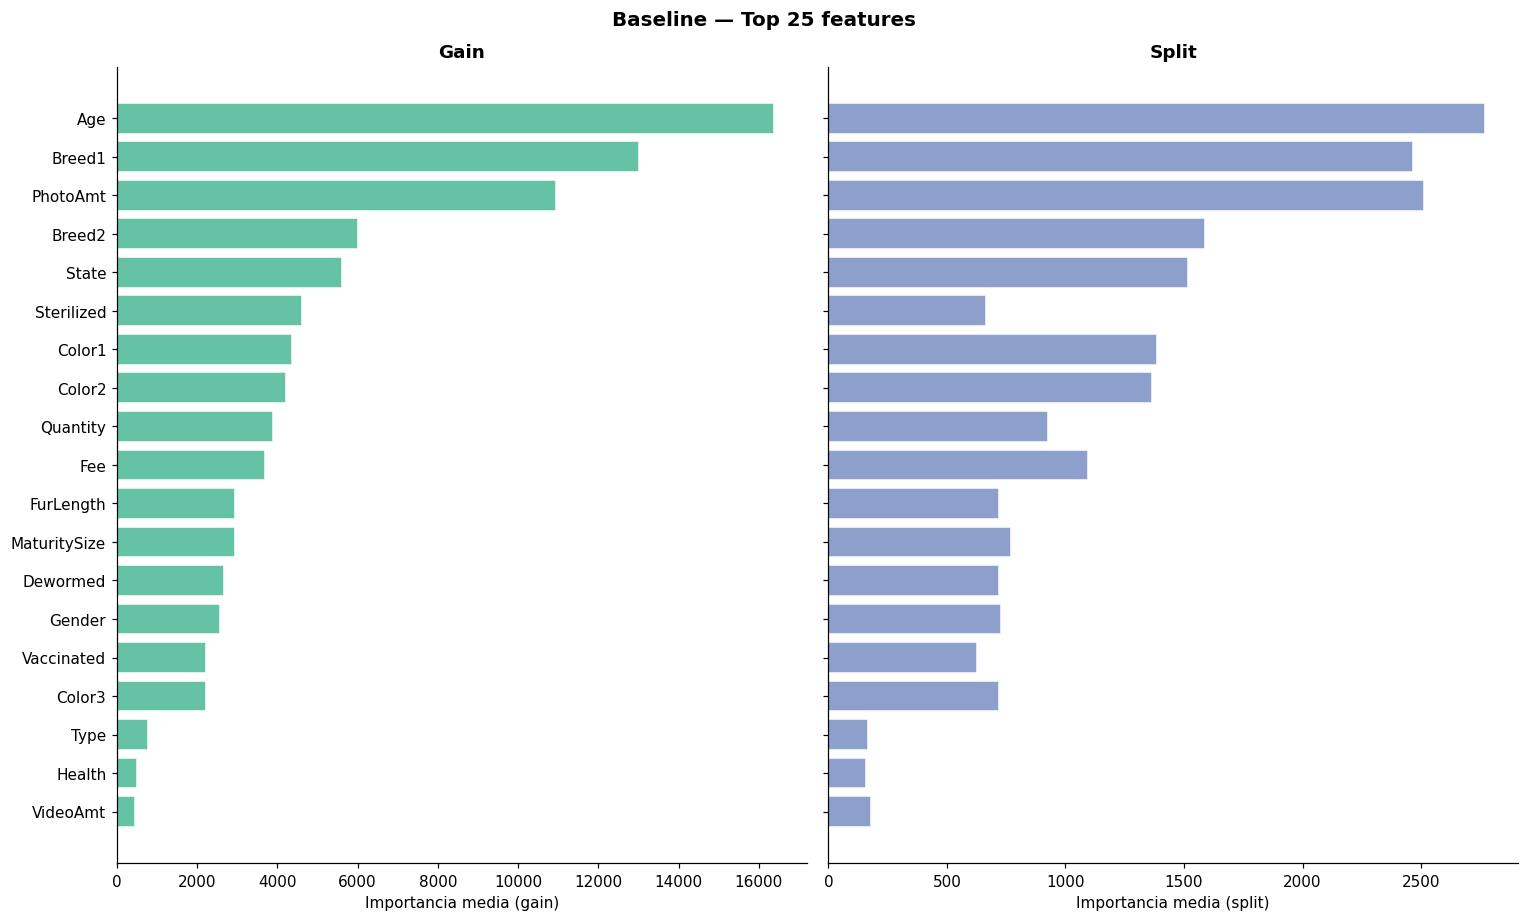

In [8]:
plot_results(y, result_baseline['oof_preds'], title='Baseline — LightGBM sin FE')
plot_importance(result_baseline['feat_imp'], top_n=25, title='Baseline — Top 25 features')

## 3b Baseline con definición de categóricas
Se evaluará como definición preliminar si utilizar el parámetro de cat_features de LGBM mejora la predicción.

In [9]:


print('=' * 55)
print('EXPERIMENTO 0a: BASELINE con definición de categóricas para LGBM')
print('=' * 55)

categoricals = ['Type', 'Gender', 'Color1', 'Color2', 'Color3',
    'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized',
    'Health', 'State', 'Breed1', 'Breed2']

result_baseline = run_cv(X = X_base, 
                         y = y, 
                         params = BASELINE_PARAMS, 
                         cat_features = categoricals,
                         experiment_name='00a_baseline_categoricals')
tracker.log(result_baseline)

EXPERIMENTO 0a: BASELINE con definición de categóricas para LGBM
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 1: QWK=0.3580  Acc=0.4248  F1=0.3405  (best iter=80)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 2: QWK=0.3414  Acc=0.4067  F1=0.3196  (best iter=53)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 3: QWK=0.3519  Acc=0.4172  F1=0.3261  (best iter=61)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 4: QWK=0.3545  Acc=0.4029  F1=0.3068  (best iter=54)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fol

Con una mejora leve en todas las métricas, y una disminución en el desvío estándar de los folds de CV, se observa que definir las variables categóricas según el parámetro de la librería de LGBM mejora la performance.
Se observa 

---
# 4. Feature Engineering iterativo

### Flujo de trabajo para agregar un experimento nuevo

1. Calcula las features **seguras** sobre todo el dataset `df_fe`
2. Define `CURRENT_FEATURES_XX = CURRENT_FEATURES + [nuevas_features]`
3. Llama `run_cv(X, y, params, ...)` con los parámetros que correspondan
4. Si mejora → actualiza `CURRENT_FEATURES = CURRENT_FEATURES_XX`

In [10]:
def should_keep(result_new, result_ref, feat_imp_new,
                qwk_tol=0.002, top_n_check=5):
    """
    Decide si incorporar un bloque de features usando tres criterios combinados:

    1. QWK: mejora, empata dentro del ruido, o cae poco
    2. Varianza: el desvío estándar entre folds no empeoró mucho
    3. Feature importance: alguna de las nuevas features está en el top-N

    Parámetros
    ----------
    qwk_tol : float
        Caída máxima de QWK tolerable para seguir evaluando los otros criterios.
        0.002 es razonable para datasets de ~15k filas con 5-fold CV.
    top_n_check : int
        Cuántas posiciones del ranking de gain se consideran "top".
    """
    delta_qwk  = result_new['qwk_mean'] - result_ref['qwk_mean']
    delta_std  = result_new['qwk_std']  - result_ref['qwk_std']

    # Features nuevas que aparecen en el top-N del ranking de gain
    top_features    = feat_imp_new['feature'].head(top_n_check).tolist()
    new_cols        = [c for c in feat_imp_new['feature'] if c not in
                       result_ref['feat_imp']['feature'].tolist()]
    new_in_top      = [f for f in new_cols if f in top_features]

    print(f'  ΔQWK:          {delta_qwk:+.4f}')
    print(f'  Δstd:          {delta_std:+.4f}  (negativo = más estable)')
    print(f'  Nuevas en top-{top_n_check}: {new_in_top}')

    if delta_qwk >= 0:
        print('  → Mejora. Se sugiere INCORPORAR.')
        return True
    elif delta_qwk >= -qwk_tol:
        if new_in_top:
            print('  → Caída dentro del ruido + feature importante. Se sugiere INCORPORAR.')
            return True
        elif delta_std < 0:
            print('  → Caída dentro del ruido + modelo más estable. Se sugiere INCORPORAR.')
            return True
        else:
            print('  → Caída dentro del ruido sin señal positiva. MARGINAL.')
            return False
    else:
        print(f'  → Caída mayor a {qwk_tol}. Se sugiere DESCARTAR.')
        return False

In [11]:
# ── Estado acumulado ──────────────────────────────────────────────────────────
# CURRENT_FEATURES es la lista de features del mejor experimento hasta ahora.
# Cada bloque propone CURRENT_FEATURES_XX y lo incorpora solo si mejora el QWK.
CURRENT_FEATURES = BASELINE_FEATURES.copy()
df_fe = df.copy()   # DataFrame de trabajo; acumula todas las features nuevas
best_result = result_baseline

print('FE iterativo listo.')

FE iterativo listo.


## 4.1a Variables de Name y Description

Extracción de señales simples del texto:
- Si tiene o no Nombre y Descripción.
- La cantidad de caracteres del Nombre y la Descripción.
- La cantidad de palabras de la Descripción.
- Un ratio entre cantidad de caracteres y de palabras, con la expectativa de que palabras más largas implican descripciones más complejas/elaboradas.

In [12]:
# ── Señales de Name ───────────────────────────────────────────────────────────
df_fe['HasName']    = df_fe['Name'].notna().astype(int)
df_fe['NameLength'] = df_fe['Name'].str.len().fillna(0)

# ── Señales de Description ───────────────────────────────────────────────────
df_fe['HasDesc']       = df_fe['Description'].notna().astype(int)
df_fe['DescLength']    = df_fe['Description'].str.len().fillna(0)
df_fe['DescWordCount'] = df_fe['Description'].fillna('').str.split().str.len()
# Largo promedio de palabra: proxy de vocabulario usado
df_fe['DescRatio']     = df_fe['DescLength'] / df_fe['DescWordCount'].replace(0, np.nan)

NEW_VAR = ['HasName', 
          'NameLength', 
          'HasDesc', 
          'DescLength', 
          'DescWordCount', 
          'DescRatio']

CURRENT_FEATURES_41a = CURRENT_FEATURES + NEW_VAR
X_41a = df_fe[CURRENT_FEATURES_41a]

print(f'Features nuevas (4.1a): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41a)}')
print('\n' + '='*55)
print('EXPERIMENTO 1a: + Señales de Name y Description')
print('='*55)

result_41a = run_cv(X_41a, 
                    y, 
                    BASELINE_PARAMS, 
                    cat_features = categoricals,
                    experiment_name='01a_name_desc')
tracker.log(result_41a)
delta(result_41a, best_result)

Features nuevas (4.1a): ['HasName', 'NameLength', 'HasDesc', 'DescLength', 'DescWordCount', 'DescRatio']
Total features: 25

EXPERIMENTO 1a: + Señales de Name y Description
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 1: QWK=0.3470  Acc=0.4137  F1=0.3256  (best iter=65)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 2: QWK=0.3359  Acc=0.4101  F1=0.3226  (best iter=70)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 3: QWK=0.3548  Acc=0.4146  F1=0.3236  (best iter=79)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 4: QWK=0.3658  Acc=0.4099  F1=0.3232  (best iter=73)
[LightGBM] [Warning] Met categorica

np.float64(-0.001052403229068466)

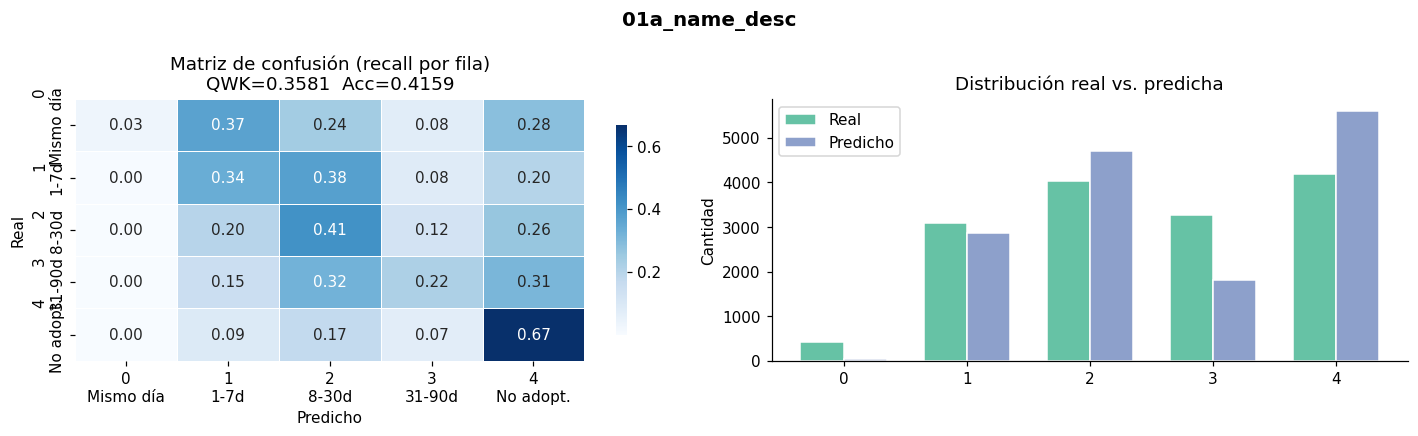

              precision    recall  f1-score   support

  0-MismoDía       0.35      0.03      0.06       410
  1-1ªSemana       0.36      0.34      0.35      3090
    2-1erMes       0.36      0.41      0.38      4035
 3-2do3erMes       0.40      0.22      0.28      3255
  4-NoAdopt.       0.50      0.67      0.57      4192

    accuracy                           0.42     14982
   macro avg       0.39      0.33      0.33     14982
weighted avg       0.41      0.42      0.40     14982



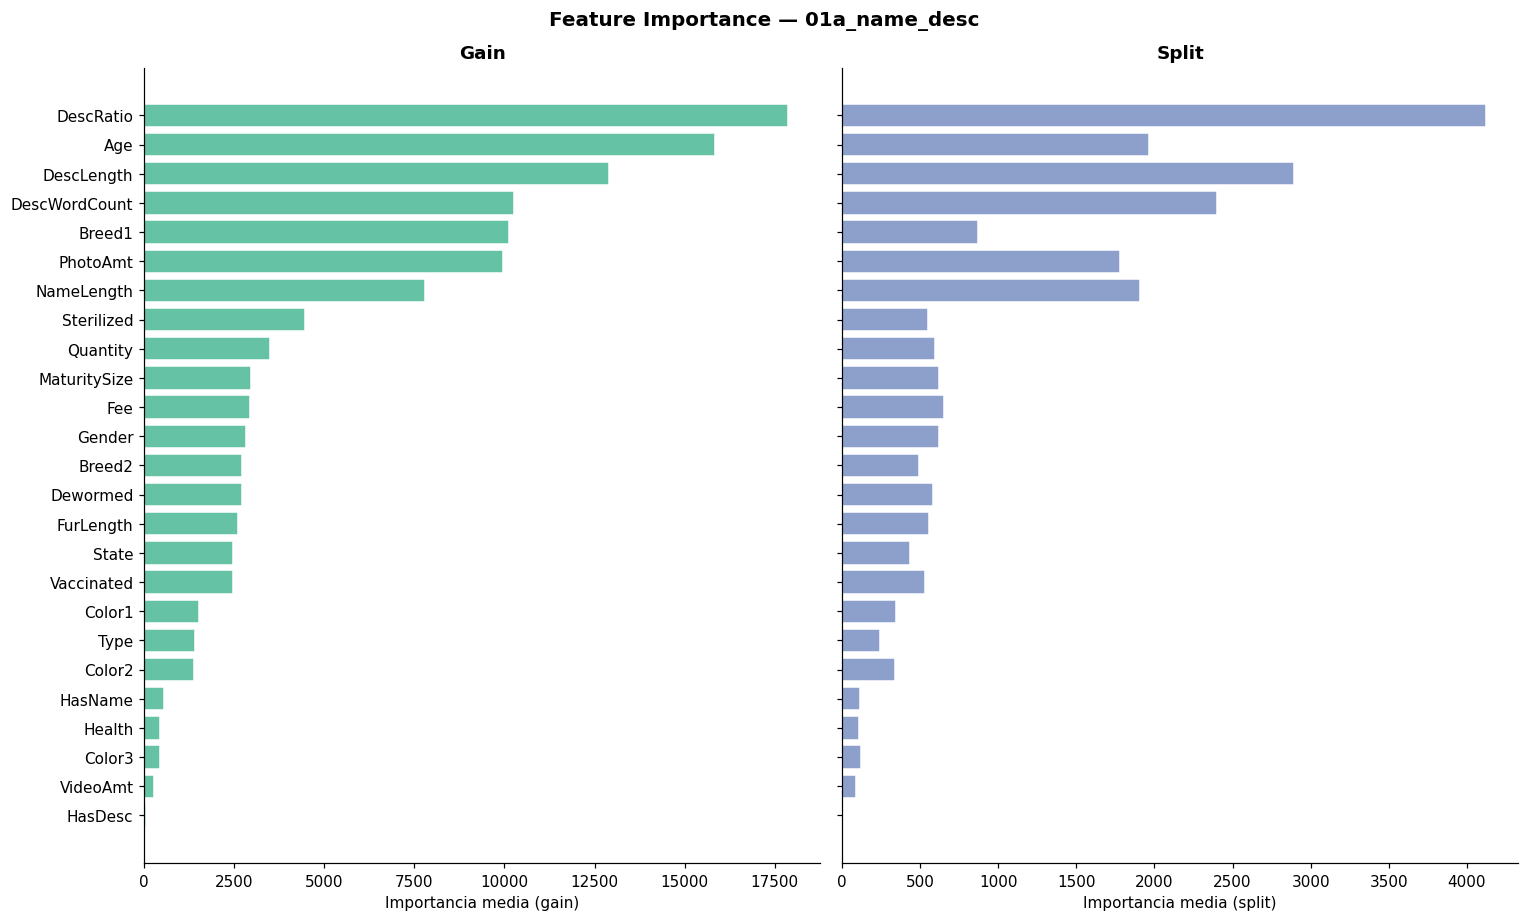

In [13]:
plot_results(y, result_41a['oof_preds'], title='01a_name_desc')
plot_importance(result_41a['feat_imp'], top_n=25, title='Feature Importance — 01a_name_desc')

In [14]:
should_keep(result_41a, best_result, result_41a['feat_imp'])

  ΔQWK:          -0.0011
  Δstd:          +0.0011  (negativo = más estable)
  Nuevas en top-5: ['DescRatio', 'DescLength', 'DescWordCount']
  → Caída dentro del ruido + feature importante. Se sugiere INCORPORAR.


True

El QWK cae muy levemente, y no presenta un desvío estándar que refleje mucha inestabilidad. Además, hay tres variables que alcanzan el top 5 de Feature Importance según Ganancia y Split, todas derivadas de la Descripción.
Se realiza el mismo experimento utilizando todas las variables derivadas solo de la Descripción.

In [15]:
NEW_VAR = [#'HasName', 
          #'NameLength', 
          'HasDesc', 
          'DescLength', 
          'DescWordCount', 
          'DescRatio']

CURRENT_FEATURES_41adesc = CURRENT_FEATURES + NEW_VAR
X_41adesc = df_fe[CURRENT_FEATURES_41adesc]

print(f'Features nuevas (4.1adesc): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41adesc)}')
print('\n' + '='*55)
print('EXPERIMENTO 1a: + Señales de Description')
print('='*55)

result_41adesc = run_cv(X_41adesc, 
                    y, 
                    BASELINE_PARAMS, 
                    cat_features = categoricals,
                    experiment_name='01a_desc')
tracker.log(result_41adesc)
delta(result_41adesc, best_result)

Features nuevas (4.1adesc): ['HasDesc', 'DescLength', 'DescWordCount', 'DescRatio']
Total features: 23

EXPERIMENTO 1a: + Señales de Description
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 1: QWK=0.3641  Acc=0.4181  F1=0.3303  (best iter=83)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 2: QWK=0.3464  Acc=0.4127  F1=0.3296  (best iter=56)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 3: QWK=0.3670  Acc=0.4199  F1=0.3259  (best iter=62)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 4: QWK=0.3534  Acc=0.4099  F1=0.3254  (best iter=80)
[LightGBM] [Warning] Met categorical feature which contains spa

np.float64(0.006782088819455134)

El desempeño es mejor: el QWK aumenta medio punto. Se incorporan las variables derivadas de Descripción.

In [16]:
should_keep(result_41adesc, best_result, result_41adesc['feat_imp'])
CURRENT_FEATURES = CURRENT_FEATURES_41adesc
best_result = result_41adesc

  ΔQWK:          +0.0068
  Δstd:          +0.0016  (negativo = más estable)
  Nuevas en top-5: ['DescRatio', 'DescLength', 'DescWordCount']
  → Mejora. Se sugiere INCORPORAR.


## 4.1b Variables sobre fotos y videos.


Transformación de las variables de PhotoAmt y VideoAmt:
- Si tiene Foto o Video.
- Una transformación logarítmica de las variables de PhotoAmt y VideoAmt, que presentan asimetría.

In [17]:
# ── Flags de presencia ────────────────────────────────────────────────────────
df_fe['HasPhoto']   = (df_fe['PhotoAmt'].fillna(0) > 0).astype(int)
df_fe['HasVideo']   = (df_fe['VideoAmt'].fillna(0) > 0).astype(int)
df_fe['PhotoAmt_log'] = np.log1p(df_fe['PhotoAmt'])
df_fe['VideoAmt_log'] = np.log1p(df_fe['VideoAmt'])

NEW_VAR = ['HasPhoto', 
          'HasVideo', 
          'PhotoAmt_log', 
          'VideoAmt_log'
         ]

CURRENT_FEATURES_41badd = CURRENT_FEATURES + NEW_VAR
X_41badd = df_fe[CURRENT_FEATURES_41badd]

print(f'Features nuevas (4.1b): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41badd)}')
print('\n' + '='*55)
print('EXPERIMENTO 1b: + Videos y fotos sin reemplazo')
print('='*55)

result_41badd = run_cv(X_41badd, 
                    y, 
                    BASELINE_PARAMS, 
                    cat_features = categoricals,
                    experiment_name='01b_video_photo_add')
tracker.log(result_41badd)
delta(result_41badd, best_result)

Features nuevas (4.1b): ['HasPhoto', 'HasVideo', 'PhotoAmt_log', 'VideoAmt_log']
Total features: 27

EXPERIMENTO 1b: + Videos y fotos sin reemplazo
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 1: QWK=0.3729  Acc=0.4291  F1=0.3480  (best iter=77)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 2: QWK=0.3439  Acc=0.4111  F1=0.3230  (best iter=59)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 3: QWK=0.3716  Acc=0.4232  F1=0.3349  (best iter=93)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 4: QWK=0.3695  Acc=0.4146  F1=0.3250  (best iter=75)
[LightGBM] [Warning] Met categorical feature which contains 

np.float64(0.0026012425247197712)

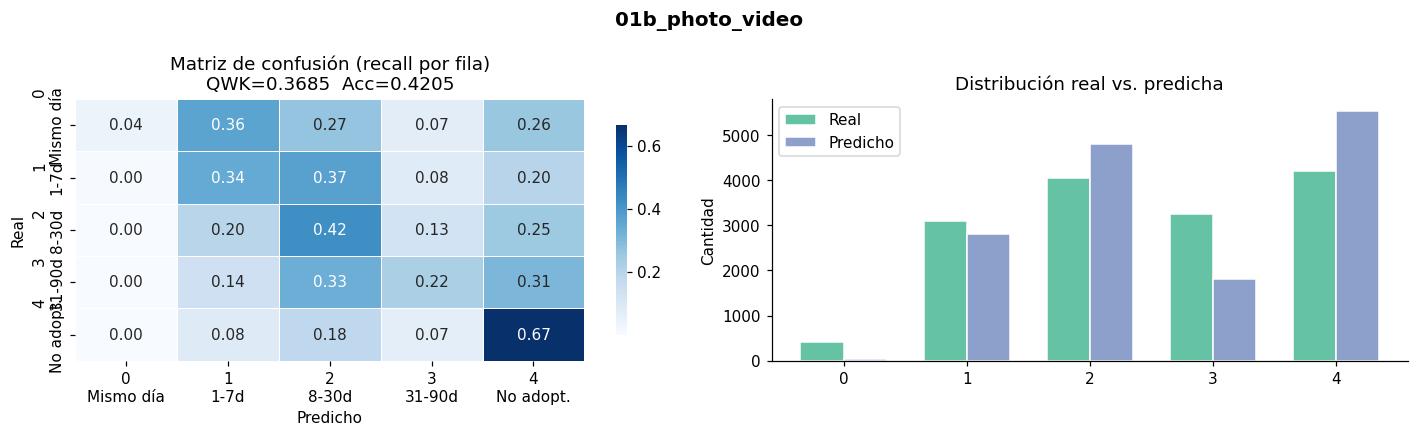

              precision    recall  f1-score   support

  0-MismoDía       0.41      0.04      0.08       410
  1-1ªSemana       0.38      0.34      0.36      3090
    2-1erMes       0.36      0.42      0.39      4035
 3-2do3erMes       0.40      0.22      0.29      3255
  4-NoAdopt.       0.51      0.67      0.57      4192

    accuracy                           0.42     14982
   macro avg       0.41      0.34      0.34     14982
weighted avg       0.41      0.42      0.40     14982



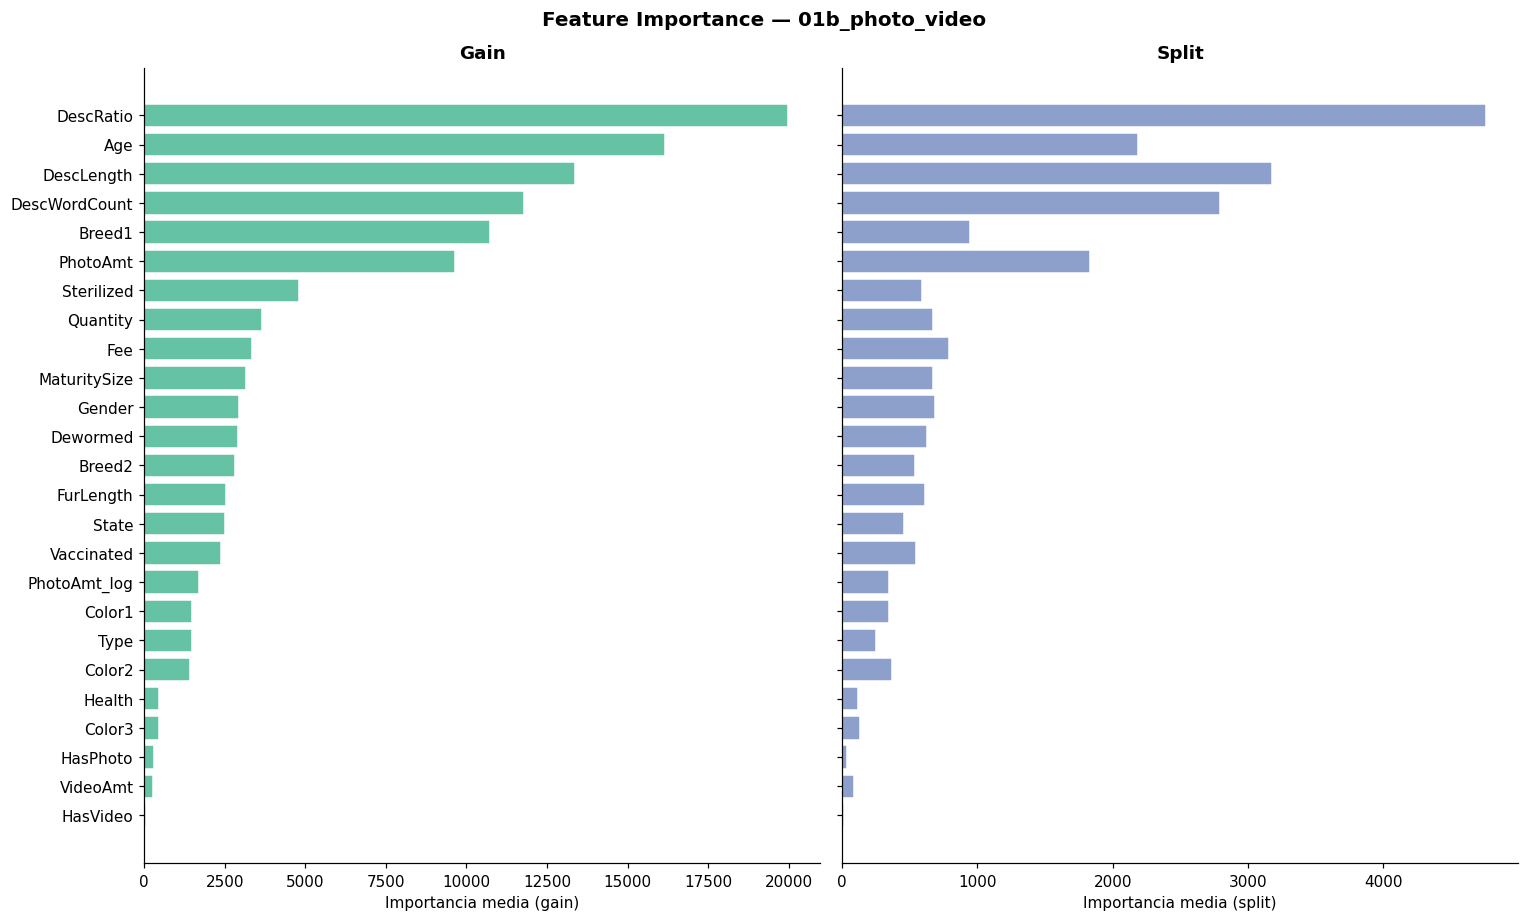

In [18]:
plot_results(y, result_41badd['oof_preds'], title='01b_photo_video')
plot_importance(result_41badd['feat_imp'], top_n=25, title='Feature Importance — 01b_photo_video')

In [19]:
should_keep(result_41badd, best_result, result_41badd['feat_imp'], top_n_check = 10)

  ΔQWK:          +0.0026
  Δstd:          -0.0045  (negativo = más estable)
  Nuevas en top-10: []
  → Mejora. Se sugiere INCORPORAR.


True

Aunque el aporte es ligero y las variables no ocupan lugares relevantes en el Feature Importance, parecen tener algo de valor. Antes de incorporar al set de datos del modelo, se estudiará si el aporte es mayor al eliminar las variables de origen (PhotoAmt y VideoAmt).

In [20]:
NEW_VAR = ['HasPhoto', 
          'HasVideo', 
          'PhotoAmt_log',
          'VideoAmt_log'
         ]

features_sin_originales = [f for f in CURRENT_FEATURES 
                            if f not in ['PhotoAmt', 'VideoAmt']]

CURRENT_FEATURES_41b_reemplazo = features_sin_originales + NEW_VAR
X_41brep = df_fe[CURRENT_FEATURES_41b_reemplazo]

print(f'Features nuevas (4.1b): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41b_reemplazo)}')
print('\n' + '='*55)
print('EXPERIMENTO 1b: + Videos y fotos con reemplazo')
print('='*55)

result_41brep = run_cv(X_41brep, 
                    y, 
                    BASELINE_PARAMS, 
                    cat_features = categoricals,
                    experiment_name='01b_video_photo_replace')
tracker.log(result_41brep)
delta(result_41brep, best_result)


Features nuevas (4.1b): ['HasPhoto', 'HasVideo', 'PhotoAmt_log', 'VideoAmt_log']
Total features: 25

EXPERIMENTO 1b: + Videos y fotos con reemplazo
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 1: QWK=0.3572  Acc=0.4164  F1=0.3248  (best iter=63)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 2: QWK=0.3438  Acc=0.4127  F1=0.3282  (best iter=64)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 3: QWK=0.3563  Acc=0.4222  F1=0.3292  (best iter=73)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 4: QWK=0.3513  Acc=0.4075  F1=0.3233  (best iter=89)
[LightGBM] [Warning] Met categorical feature which contains 

np.float64(-0.005436701879886652)

In [21]:
should_keep(result_41brep, best_result, result_41brep['feat_imp'], top_n_check = 10)

  ΔQWK:          -0.0054
  Δstd:          -0.0007  (negativo = más estable)
  Nuevas en top-10: ['PhotoAmt_log']
  → Caída mayor a 0.002. Se sugiere DESCARTAR.


False

Los resultados empeoran claramente al eliminar las variables de origen. Se mantienen PhotoAmt y VideoAmt, y se incorporan las variables derivadas.

In [22]:
CURRENT_FEATURES = CURRENT_FEATURES_41badd
best_result = result_41badd

## 4.1c Variables derivadas del Estado

La variable de Estado es una categórica con cardinalidad relativamente alta. Se incorpora información externa sobre esta variable para aportar contexto:
- Población en miles de cada uno de los Estados, según información del Departamento de Estadísticas de Malasia.[https://open.dosm.gov.my/data-catalogue/population_malaysia]
- Ingreso mediano de cada uno de los Estados, según el Departamento de Estadísticas de Malasia.[https://open.dosm.gov.my/data-catalogue/hh_income_state]
- Matrimonios absolutos por año y Rate de matrimonio por año de cada uno de los Estados. [https://open.dosm.gov.my/data-catalogue/marriages_state]

In [23]:
#malaysia_pop = pd.read_parquet('https://storage.dosm.gov.my/population/population_state.parquet')
malaysia_pop = pd.read_parquet('/kaggle/input/datasets/tarmencello/state-metrics/population_state.parquet')
malaysia_pop = malaysia_pop[(malaysia_pop['ethnicity'] == 'overall') & 
                            (malaysia_pop['age'] == 'overall') & 
                            (malaysia_pop['sex'] == 'both') & 
                            (malaysia_pop['date'] == datetime.date(2022, 1, 1))][['state', 'population']]

#malaysia_inc = pd.read_parquet('https://storage.dosm.gov.my/hies/hh_income_state.parquet')
malaysia_inc = pd.read_parquet('/kaggle/input/datasets/tarmencello/state-metrics/hh_income_state.parquet')
malaysia_inc = malaysia_inc[malaysia_inc['date'] == datetime.date(2022, 1, 1)][['state', 'income_median']]

#malaysia_mar = pd.read_parquet('https://storage.dosm.gov.my/demography/marriages_state.parquet')
malaysia_mar = pd.read_parquet('/kaggle/input/datasets/tarmencello/state-metrics/marriages_state.parquet')
malaysia_mar = malaysia_mar[malaysia_mar['date'] == datetime.date(2022, 1, 1)]
malaysia_mar = malaysia_mar[['state', 'rate']].rename(columns={'rate': 'marriage_rate'})
malaysia_mar = malaysia_mar.groupby('state').sum()

El dataset del DOSM separa el Territorio Federal de Putrajaya para reportar las estadísticas. Sin embargo el dataset de etiquetas de PetFinder no lo incluye entre los Estados registrados. Por eso se incorporará al Estado de Selangor (usualmente se lo considera como parte debido a proximidad geográfica), recalculando las métricas con promedios ponderados por población.

In [24]:
malaysia_stats = malaysia_pop.merge(malaysia_inc, on='state').merge(malaysia_mar, on='state')
malaysia_stats = malaysia_stats.rename(columns = {'state' : 'StateName'})

mapping = {
    'W.P. Kuala Lumpur': 'Kuala Lumpur',
    'W.P. Labuan': 'Labuan',
    'W.P. Putrajaya': 'Selangor'
}

malaysia_stats['StateName'] = malaysia_stats['StateName'].replace(mapping)

malaysia_stats['w_income_median'] = malaysia_stats['income_median'] * malaysia_stats['population']
malaysia_stats['w_marriage_rate'] = malaysia_stats['marriage_rate'] * malaysia_stats['population']

agg_stats = malaysia_stats.groupby('StateName').agg({
    'population': 'sum',
    'w_income_median': 'sum',
    'w_marriage_rate': 'sum'
}).reset_index()

agg_stats['income_median'] = agg_stats['w_income_median'] / agg_stats['population']
agg_stats['marriage_rate'] = agg_stats['w_marriage_rate'] / agg_stats['population']

malaysia_stats = agg_stats[['StateName', 'population', 'income_median', 'marriage_rate']]

malaysia_stats = states.merge(malaysia_stats, on='StateName', how= 'outer')
print(malaysia_stats.sort_values('population', ascending=False))


    StateID        StateName  population  income_median  marriage_rate
13    41326         Selangor      7167.3    9984.191662      44.994316
0     41336            Johor      4028.3         6879.0      46.900000
11    41345            Sabah      3414.9         4577.0      33.800000
8     41330            Perak      2514.4         4494.0      49.600000
12    41342          Sarawak      2473.5         4978.0      49.000000
1     41325            Kedah      2163.1         4402.0      57.100000
3     41401     Kuala Lumpur      1961.2        10234.0      45.600000
2     41367         Kelantan      1830.6         3614.0      67.700000
10    41327     Pulau Pinang      1740.9         6502.0      44.300000
7     41335           Pahang      1614.3         4753.0      47.100000
6     41332  Negeri Sembilan      1207.9         5226.0      51.700000
14    41361       Terengganu      1186.6         5878.0      58.900000
5     41324           Melaka      1008.6         6210.0      49.800000
9     

In [25]:

df_fe['StatePop']       = df_fe['State'].map(malaysia_stats.set_index('StateID')['population'].to_dict())
df_fe['StateIncomeMedian'] = df_fe['State'].map(malaysia_stats.set_index('StateID')['income_median'].to_dict())
df_fe['StateMarriageRate'] = df_fe['State'].map(malaysia_stats.set_index('StateID')['marriage_rate'].to_dict())


NEW_VAR = ['StatePop', 
          'StateIncomeMedian',
          'StateMarriageRate'
         ]

CURRENT_FEATURES_41c = CURRENT_FEATURES + NEW_VAR
X_41c = df_fe[CURRENT_FEATURES_41c]

print(f'Features nuevas (4.1c): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41c)}')
print('\n' + '='*55)
print('EXPERIMENTO 1c: + Contexto de Estados')
print('='*55)

result_41c = run_cv(X_41c, 
                    y, 
                    BASELINE_PARAMS, 
                    cat_features = categoricals,
                    experiment_name='01c_states')
tracker.log(result_41c)
delta(result_41c, best_result)

Features nuevas (4.1c): ['StatePop', 'StateIncomeMedian', 'StateMarriageRate']
Total features: 30

EXPERIMENTO 1c: + Contexto de Estados
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 1: QWK=0.3748  Acc=0.4191  F1=0.3324  (best iter=104)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 2: QWK=0.3520  Acc=0.4124  F1=0.3234  (best iter=58)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 3: QWK=0.3601  Acc=0.4186  F1=0.3268  (best iter=66)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 4: QWK=0.3601  Acc=0.4062  F1=0.3149  (best iter=69)
[LightGBM] [Warning] Met categorical feature which contains sparse val

np.float64(0.0009190510479894498)

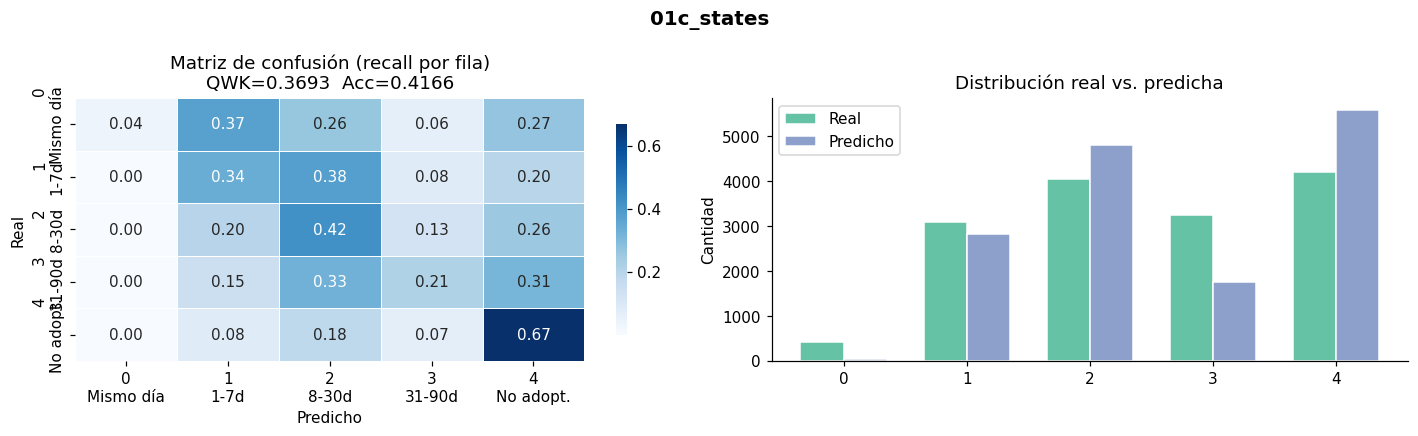

              precision    recall  f1-score   support

  0-MismoDía       0.47      0.04      0.07       410
  1-1ªSemana       0.37      0.34      0.35      3090
    2-1erMes       0.35      0.42      0.38      4035
 3-2do3erMes       0.39      0.21      0.28      3255
  4-NoAdopt.       0.50      0.67      0.57      4192

    accuracy                           0.42     14982
   macro avg       0.42      0.33      0.33     14982
weighted avg       0.41      0.42      0.40     14982



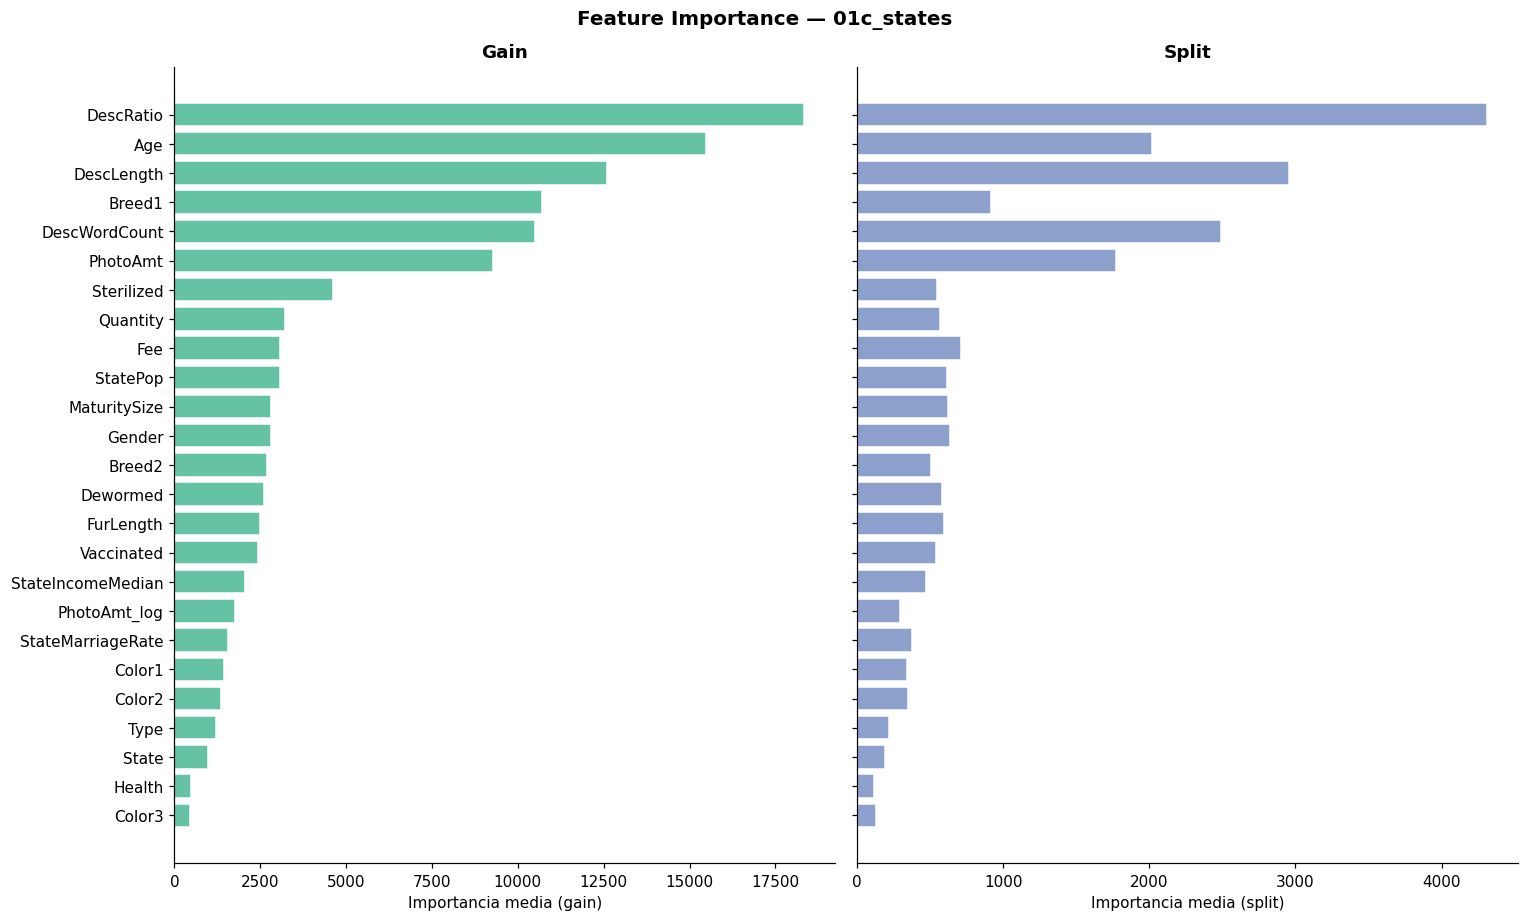

In [26]:
plot_results(y, result_41c['oof_preds'], title='01c_states')
plot_importance(result_41c['feat_imp'], top_n=25, title='Feature Importance — 01c_states')

In [27]:
should_keep(result_41c, best_result, result_41c['feat_imp'], top_n_check = 10)

  ΔQWK:          +0.0009
  Δstd:          +0.0036  (negativo = más estable)
  Nuevas en top-10: ['StatePop']
  → Mejora. Se sugiere INCORPORAR.


True

Las variables que aportan contexto sobre los Estados en que se adoptan los animales parecen aportar un ligero valor. Particularmente la variable que reporta la Población. Además, parecen mejorar la señal que aportaba la variable de State. Se replicará el experimento eliminando la variable de origen para identificar si la performance es mejor, o si las variables son complementarias.

In [28]:
features_sin_originales = [f for f in CURRENT_FEATURES
                            if f not in ['State']]

categoricals_sin_originales = [f for f in categoricals 
                            if f not in ['State']]


CURRENT_FEATURES_41c_reemplazo = features_sin_originales + NEW_VAR
X_41c_reemplazo = df_fe[CURRENT_FEATURES_41c_reemplazo]

print(f'Features nuevas (4.1c rep): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41c_reemplazo)}')
print('\n' + '='*55)
print('EXPERIMENTO 1c: + Contexto de Estados con reemplazo')
print('='*55)

result_41c_reemplazo = run_cv(X_41c_reemplazo, 
                    y, 
                    BASELINE_PARAMS, 
                    cat_features = categoricals_sin_originales,
                    experiment_name='01c_states_rep')
tracker.log(result_41c_reemplazo)
delta(result_41c_reemplazo, best_result)

Features nuevas (4.1c rep): ['StatePop', 'StateIncomeMedian', 'StateMarriageRate']
Total features: 29

EXPERIMENTO 1c: + Contexto de Estados con reemplazo
  Fold 1: QWK=0.3809  Acc=0.4268  F1=0.3464  (best iter=76)
  Fold 2: QWK=0.3468  Acc=0.4004  F1=0.3138  (best iter=51)
  Fold 3: QWK=0.3588  Acc=0.4146  F1=0.3233  (best iter=68)
  Fold 4: QWK=0.3542  Acc=0.4079  F1=0.3172  (best iter=75)
  Fold 5: QWK=0.3839  Acc=0.4209  F1=0.3495  (best iter=68)

  ► 01c_states_rep
    QWK  0.3649 ± 0.0148
    Acc  0.4141
    F1   0.3301
  ΔQWK vs. referencia: -0.0035


np.float64(-0.0034665107641018156)

El aporte parece ser complementario. Se mantiene la variable original y se incorporan las contextuales.

In [29]:
CURRENT_FEATURES = CURRENT_FEATURES_41c
best_result = result_41c

## 4.1d Variables de características del animal

Se realizan transformaciones para generar:
- Flags de características como si es de 1 sólo color, de raza pura
- Si la publicación corresponde a un grupo de animales o a uno solo.

In [30]:
df_fe['IsFree']     = (df_fe['Fee'] == 0).astype(int)
df_fe['MixedBreed'] = (
    (df_fe['Breed2Name'].notna() & (df_fe['Breed1'] != df_fe['Breed2'])) |
    (df_fe['Breed1Name'] == 'Mixed Breed')
).astype(int)
df_fe['MixedColor'] = ((df_fe['Color2'] != 0) & df_fe['Color2'].notna()).astype(int)
df_fe['IsGroup']    = (df_fe['Quantity'] > 1).astype(int)

NEW_VAR = ['IsFree', 
          'MixedBreed',
          'MixedColor',
          'IsGroup'
         ]

CURRENT_FEATURES_41d = CURRENT_FEATURES + NEW_VAR
X_41d = df_fe[CURRENT_FEATURES_41d]

print(f'Features nuevas (4.1d): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41d)}')
print('\n' + '='*55)
print('EXPERIMENTO 1d: + Características del animal')
print('='*55)

result_41d = run_cv(X_41d, 
                    y, 
                    BASELINE_PARAMS, 
                    cat_features = categoricals,
                    experiment_name='01d_caracs')
tracker.log(result_41d)
delta(result_41d, best_result)

Features nuevas (4.1d): ['IsFree', 'MixedBreed', 'MixedColor', 'IsGroup']
Total features: 34

EXPERIMENTO 1d: + Características del animal
  Fold 1: QWK=0.3575  Acc=0.4228  F1=0.3356  (best iter=77)
  Fold 2: QWK=0.3549  Acc=0.4198  F1=0.3352  (best iter=56)
  Fold 3: QWK=0.3659  Acc=0.4242  F1=0.3289  (best iter=67)
  Fold 4: QWK=0.3605  Acc=0.4095  F1=0.3228  (best iter=59)
  Fold 5: QWK=0.3867  Acc=0.4312  F1=0.3637  (best iter=82)

  ► 01d_caracs
    QWK  0.3651 ± 0.0114
    Acc  0.4215
    F1   0.3372
  ΔQWK vs. referencia: -0.0042


np.float64(-0.0042088933971455855)

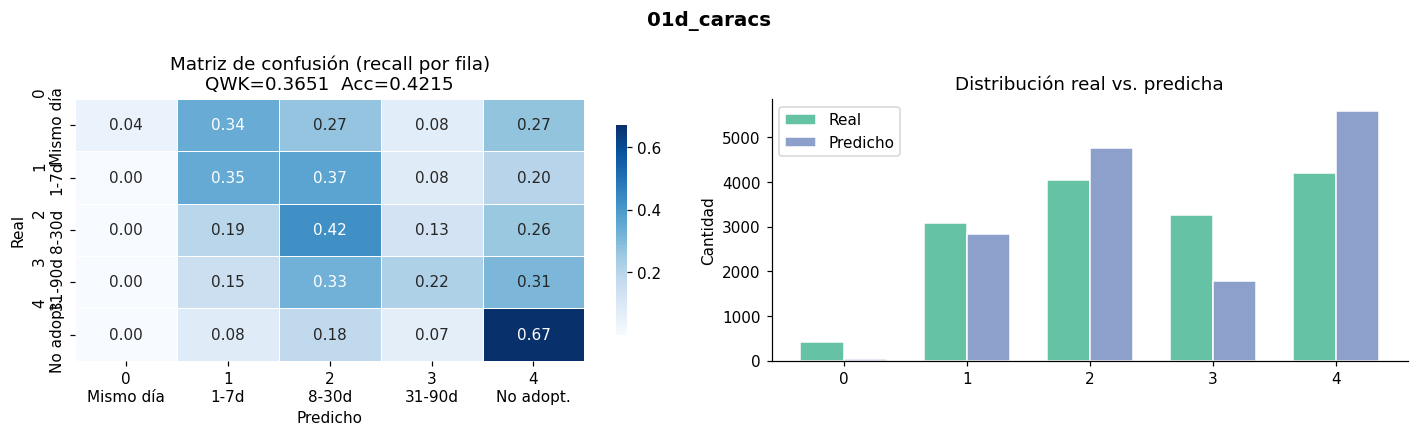

              precision    recall  f1-score   support

  0-MismoDía       0.44      0.04      0.08       410
  1-1ªSemana       0.38      0.35      0.36      3090
    2-1erMes       0.36      0.42      0.39      4035
 3-2do3erMes       0.40      0.22      0.28      3255
  4-NoAdopt.       0.50      0.67      0.57      4192

    accuracy                           0.42     14982
   macro avg       0.42      0.34      0.34     14982
weighted avg       0.41      0.42      0.40     14982



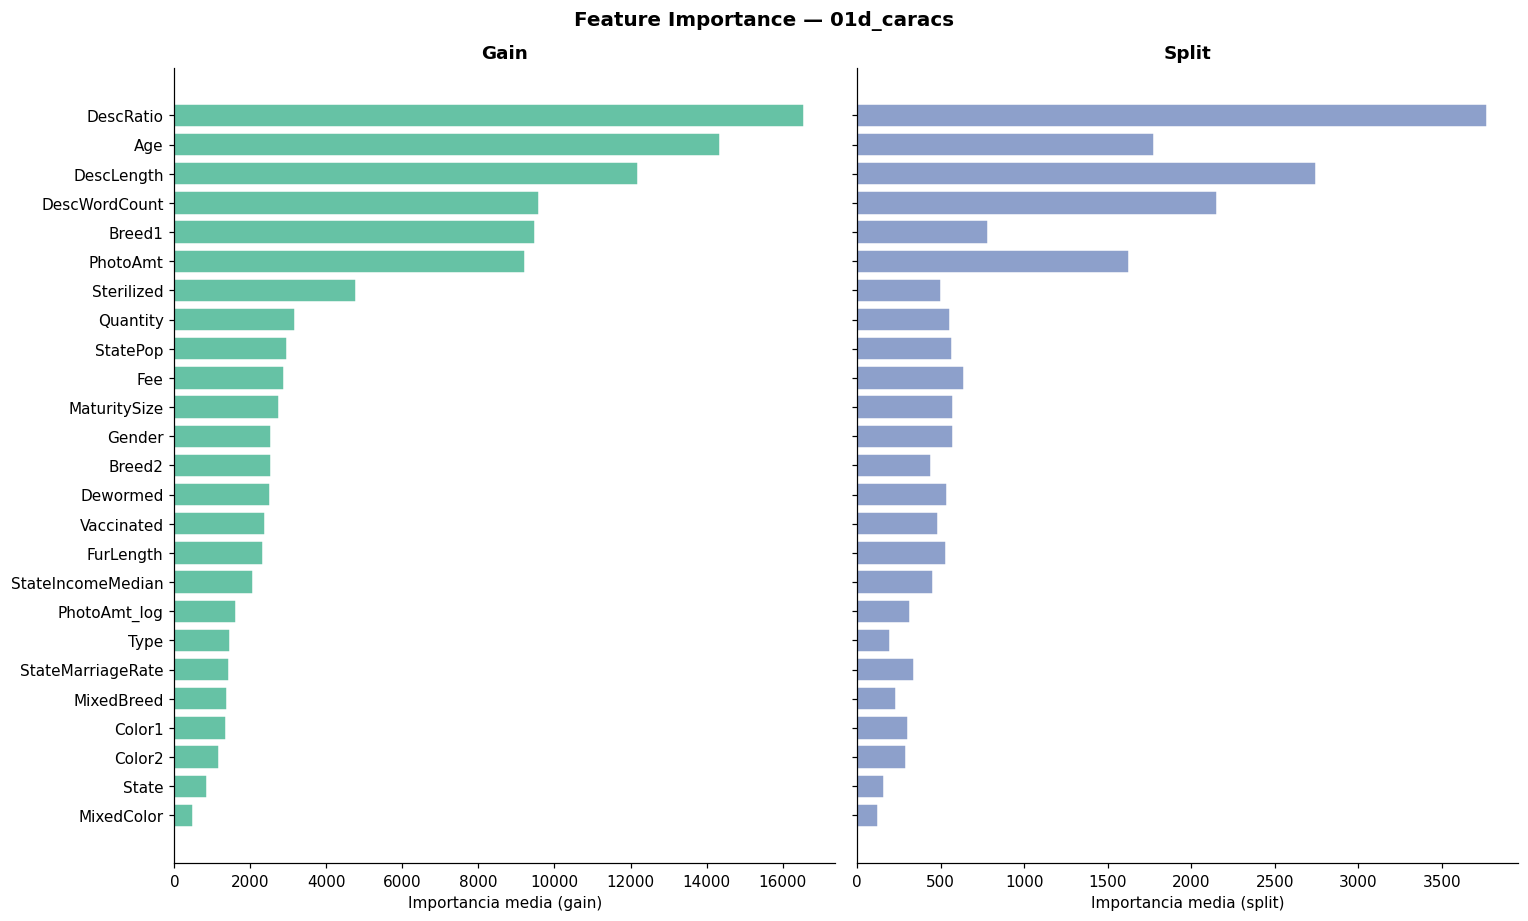

In [31]:
plot_results(y, result_41d['oof_preds'], title='01d_caracs')
plot_importance(result_41d['feat_imp'], top_n=25, title='Feature Importance — 01d_caracs')

In [32]:
should_keep(result_41d, best_result, result_41d['feat_imp'], top_n_check = 10)

  ΔQWK:          -0.0042
  Δstd:          -0.0054  (negativo = más estable)
  Nuevas en top-10: []
  → Caída mayor a 0.002. Se sugiere DESCARTAR.


False

Estas variables no mejoran la performance del modelo.

## 4.1e Variables relativas a la salud del animal
Las transformaciones buscan:
- Dicotomizar la información de si el animal fue Vacunado o no, Desparasitado o no, y Esterilizado o no (donde Sí = 1 y No / No sabe = 0)
- Generar un Score de salud general, identificando las características del animal.

In [33]:
# ── Score de salud combinado ──────────────────────────────────────────────────
# Vaccinated/Dewormed/Sterilized: 1=Sí, 2=No, 3=No sabe
# Health: 1=Sano, 2=Lesión leve, 3=Lesión grave, 0=No especificado

df_fe['VaccYes']   = (df_fe['Vaccinated']  == 1).astype(int)
df_fe['DewormYes'] = (df_fe['Dewormed']    == 1).astype(int)
df_fe['SterYes']   = (df_fe['Sterilized']  == 1).astype(int)
df_fe['Healthy']   = (df_fe['Health']  == 1).astype(int)

health_map = {0: np.nan, 1: 1.0, 2: 0.5, 3: 0.0}
df_fe['HealthScore'] = ( (df_fe['VaccYes'] + df_fe['DewormYes'] + df_fe['SterYes'])/3 * 0.4 ) + (df_fe['Health'].replace(health_map) * 0.6)

NEW_VAR = ['VaccYes', 
          'DewormYes',
          'SterYes',
          'HealthScore',
          'Healthy'
         ]

CURRENT_FEATURES_41e = CURRENT_FEATURES + NEW_VAR
X_41e = df_fe[CURRENT_FEATURES_41e]

print(f'Features nuevas (4.1e): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41e)}')
print('\n' + '='*55)
print('EXPERIMENTO 1e: + Salud del animal')
print('='*55)

result_41e = run_cv(X_41e, 
                    y, 
                    BASELINE_PARAMS, 
                    cat_features = categoricals,
                    experiment_name='01e_health')
tracker.log(result_41e)
delta(result_41e, best_result)

Features nuevas (4.1e): ['VaccYes', 'DewormYes', 'SterYes', 'HealthScore', 'Healthy']
Total features: 35

EXPERIMENTO 1e: + Salud del animal
  Fold 1: QWK=0.3785  Acc=0.4204  F1=0.3368  (best iter=77)
  Fold 2: QWK=0.3562  Acc=0.4101  F1=0.3171  (best iter=54)
  Fold 3: QWK=0.3656  Acc=0.4156  F1=0.3291  (best iter=90)
  Fold 4: QWK=0.3501  Acc=0.4075  F1=0.3222  (best iter=78)
  Fold 5: QWK=0.4125  Acc=0.4339  F1=0.3609  (best iter=91)

  ► 01e_health
    QWK  0.3726 ± 0.0222
    Acc  0.4175
    F1   0.3332
  ΔQWK vs. referencia: +0.0033


np.float64(0.0032603368733695737)

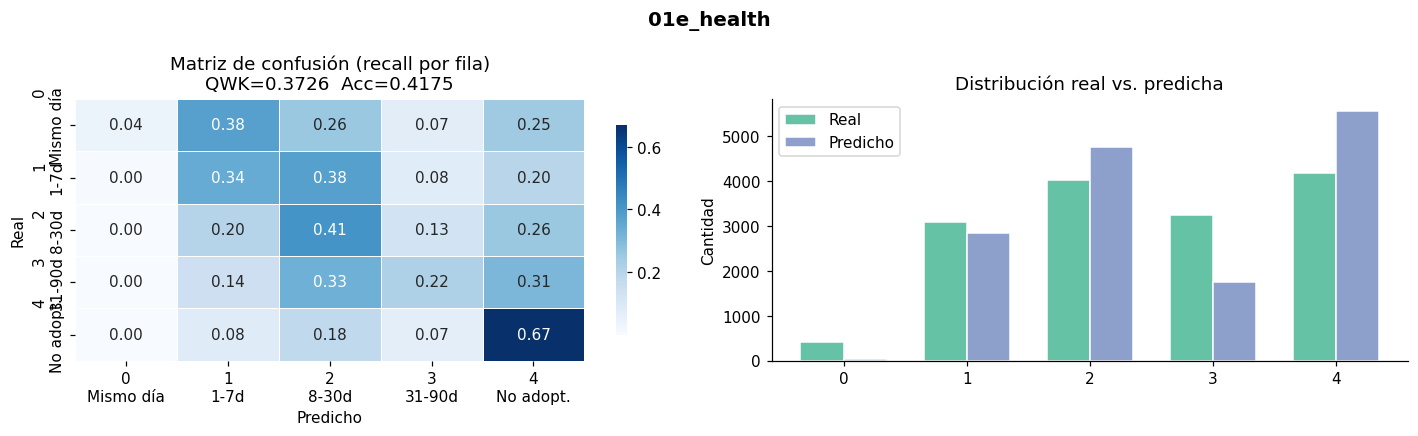

              precision    recall  f1-score   support

  0-MismoDía       0.41      0.04      0.08       410
  1-1ªSemana       0.37      0.34      0.36      3090
    2-1erMes       0.35      0.41      0.38      4035
 3-2do3erMes       0.40      0.22      0.28      3255
  4-NoAdopt.       0.50      0.67      0.58      4192

    accuracy                           0.42     14982
   macro avg       0.41      0.34      0.33     14982
weighted avg       0.41      0.42      0.40     14982



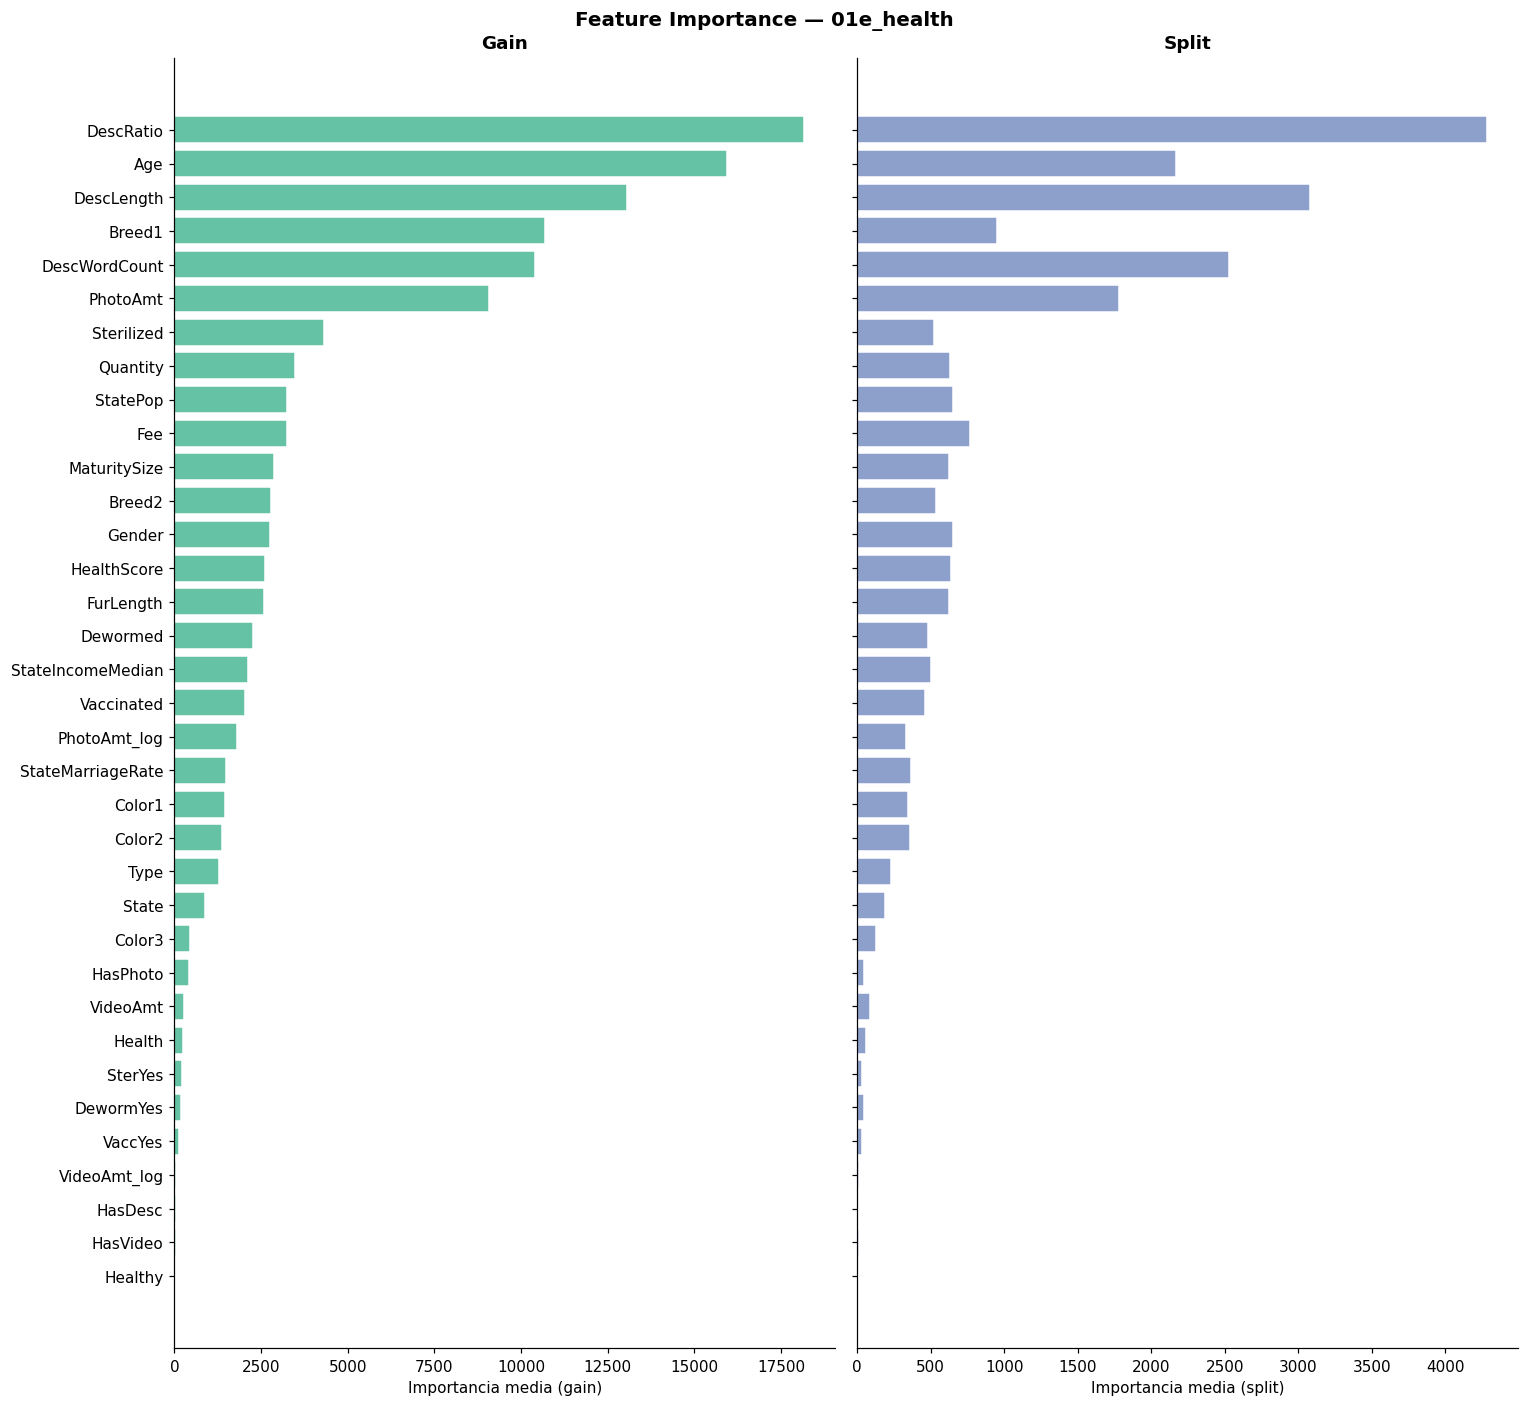

In [34]:
plot_results(y, result_41e['oof_preds'], title='01e_health')
plot_importance(result_41e['feat_imp'], top_n=40, title='Feature Importance — 01e_health')

In [35]:
should_keep(result_41e, best_result, result_41e['feat_imp'], top_n_check = 10)

  ΔQWK:          +0.0033
  Δstd:          +0.0053  (negativo = más estable)
  Nuevas en top-10: []
  → Mejora. Se sugiere INCORPORAR.


True

Se observa un efecto al incorporar estas nuevas features. Se evalúa el mismo experimento pero eliminando las variables origen del modelo.

In [36]:
NEW_VAR = ['VaccYes', 
          'DewormYes',
          'SterYes',
          'HealthScore',
          'Healthy'
         ]

features_sin_originales = [f for f in CURRENT_FEATURES 
                            if f not in ['Vaccinated', 
                                         'Dewormed', 
                                         'Sterilized', 
                                         'Health']]

categoricals_sin_originales = [f for f in categoricals 
                            if f not in ['Vaccinated', 'Dewormed', 'Sterilized', 'Health']]


CURRENT_FEATURES_41e_reemplazo = features_sin_originales + NEW_VAR
X_41erep = df_fe[CURRENT_FEATURES_41e_reemplazo]

print(f'Features nuevas (4.1e): {NEW_VAR}')
print(f'Total features: {len(CURRENT_FEATURES_41e_reemplazo)}')
print('\n' + '='*55)
print('EXPERIMENTO 1e: + Salud del animal con reemplazo')
print('='*55)

result_41erep = run_cv(X_41erep, 
                    y, 
                    BASELINE_PARAMS, 
                    cat_features = categoricals_sin_originales,
                    experiment_name='01e_health_replace')
tracker.log(result_41erep)
delta(result_41erep, best_result)


Features nuevas (4.1e): ['VaccYes', 'DewormYes', 'SterYes', 'HealthScore', 'Healthy']
Total features: 31

EXPERIMENTO 1e: + Salud del animal con reemplazo
  Fold 1: QWK=0.3668  Acc=0.4224  F1=0.3313  (best iter=72)
  Fold 2: QWK=0.3330  Acc=0.4077  F1=0.3214  (best iter=59)
  Fold 3: QWK=0.3613  Acc=0.4189  F1=0.3310  (best iter=65)
  Fold 4: QWK=0.3444  Acc=0.4002  F1=0.3115  (best iter=58)
  Fold 5: QWK=0.3939  Acc=0.4306  F1=0.3579  (best iter=92)

  ► 01e_health_replace
    QWK  0.3599 ± 0.0208
    Acc  0.4160
    F1   0.3306
  ΔQWK vs. referencia: -0.0094


np.float64(-0.009433376410715788)

In [37]:
should_keep(result_41erep, best_result, result_41erep['feat_imp'], top_n_check = 10)

  ΔQWK:          -0.0094
  Δstd:          +0.0040  (negativo = más estable)
  Nuevas en top-10: ['HealthScore']
  → Caída mayor a 0.002. Se sugiere DESCARTAR.


False

In [38]:
CURRENT_FEATURES = CURRENT_FEATURES_41e
best_result = result_41e

Al eliminar las variables de origen, el QWK es inferior al mejor resultado hasta el momento y el modelo se vuelve más inestable. Se mantienen las originales y se incorporan las derivadas.

## 4.2 Transformaciones de variables numéricas

Se aplicarán logaritmos naturales a las variables numéricas Age, Fee y Quantity. Esto busca reducir la asimetría de estas variables para evaluar si mejora la relación con la variable objetivo.

In [39]:
from scipy import stats
print(f"Asimetría de Age: {stats.skew(df_fe['Age'])} - Positiva")
print(f"Asimetría de Fee: {stats.skew(df_fe['Fee'])} - Positiva")
print(f"Asimetría de Quantity: {stats.skew(df_fe['Quantity'])} - Positiva")


Asimetría de Age: 3.7613490292262752 - Positiva
Asimetría de Fee: 8.917358935342522 - Positiva
Asimetría de Quantity: 4.604659051407468 - Positiva


In [40]:
# ── Transformaciones de skewness ──────────────────────────────────────────────
df_fe['Age_log']      = np.log1p(df_fe['Age'])
df_fe['Fee_log']      = np.log1p(df_fe['Fee'])
df_fe['Qty_log']      = np.log1p(df_fe['Quantity'])


print(f"Asimetría de Age: {stats.skew(df_fe['Age_log'])} - Positiva")
print(f"Asimetría de Fee: {stats.skew(df_fe['Fee_log'])} - Positiva")
print(f"Asimetría de Quantity: {stats.skew(df_fe['Qty_log'])} - Positiva")

NEW_NUM = ['Age_log',
          'Fee_log',
          'Qty_log']

CURRENT_FEATURES_42 = CURRENT_FEATURES + NEW_NUM
X_42 = df_fe[CURRENT_FEATURES_42]

print(f'Features nuevas (4.2): {NEW_NUM}')
print(f'Total features: {len(CURRENT_FEATURES_42)}')
print('\n' + '='*55)
print('EXPERIMENTO 2: + Transformaciones numéricas')
print('='*55)

result_42 = run_cv(X_42, 
                   y, 
                   BASELINE_PARAMS, 
                   cat_features = categoricals,
                   experiment_name='02_num_transforms')
tracker.log(result_42)
delta(result_42, best_result)

Asimetría de Age: 0.9472534664768041 - Positiva
Asimetría de Fee: 2.1700690067931387 - Positiva
Asimetría de Quantity: 2.2838352622620497 - Positiva
Features nuevas (4.2): ['Age_log', 'Fee_log', 'Qty_log']
Total features: 38

EXPERIMENTO 2: + Transformaciones numéricas
  Fold 1: QWK=0.3717  Acc=0.4201  F1=0.3363  (best iter=84)
  Fold 2: QWK=0.3504  Acc=0.4121  F1=0.3284  (best iter=61)
  Fold 3: QWK=0.3592  Acc=0.4219  F1=0.3320  (best iter=74)
  Fold 4: QWK=0.3558  Acc=0.4085  F1=0.3247  (best iter=67)
  Fold 5: QWK=0.4015  Acc=0.4292  F1=0.3499  (best iter=66)

  ► 02_num_transforms
    QWK  0.3677 ± 0.0183
    Acc  0.4184
    F1   0.3342
  ΔQWK vs. referencia: -0.0049


np.float64(-0.004871440271764338)

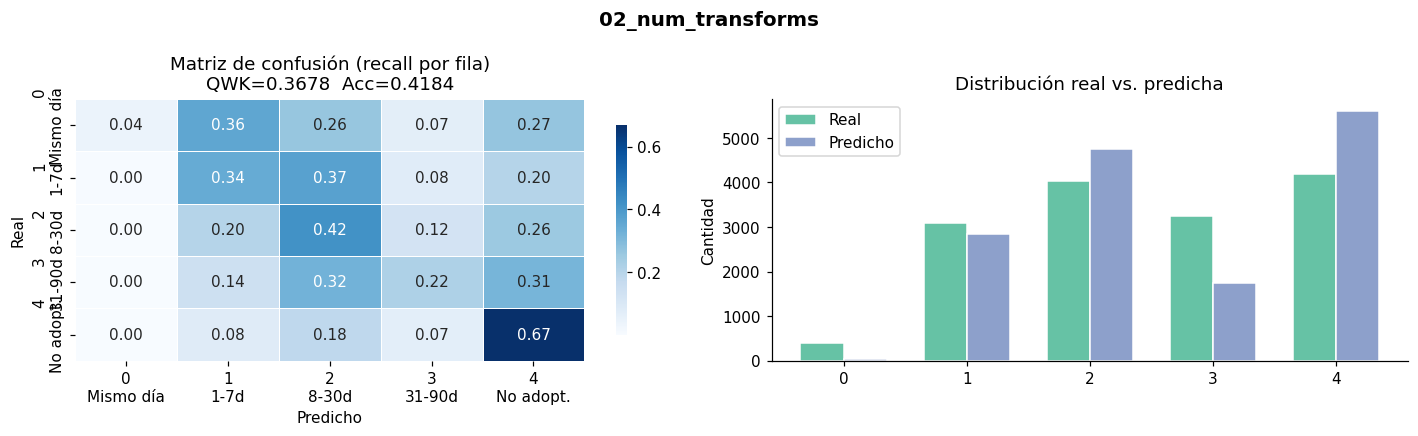

              precision    recall  f1-score   support

  0-MismoDía       0.41      0.04      0.08       410
  1-1ªSemana       0.37      0.34      0.36      3090
    2-1erMes       0.35      0.42      0.38      4035
 3-2do3erMes       0.40      0.22      0.28      3255
  4-NoAdopt.       0.50      0.67      0.57      4192

    accuracy                           0.42     14982
   macro avg       0.41      0.34      0.33     14982
weighted avg       0.41      0.42      0.40     14982



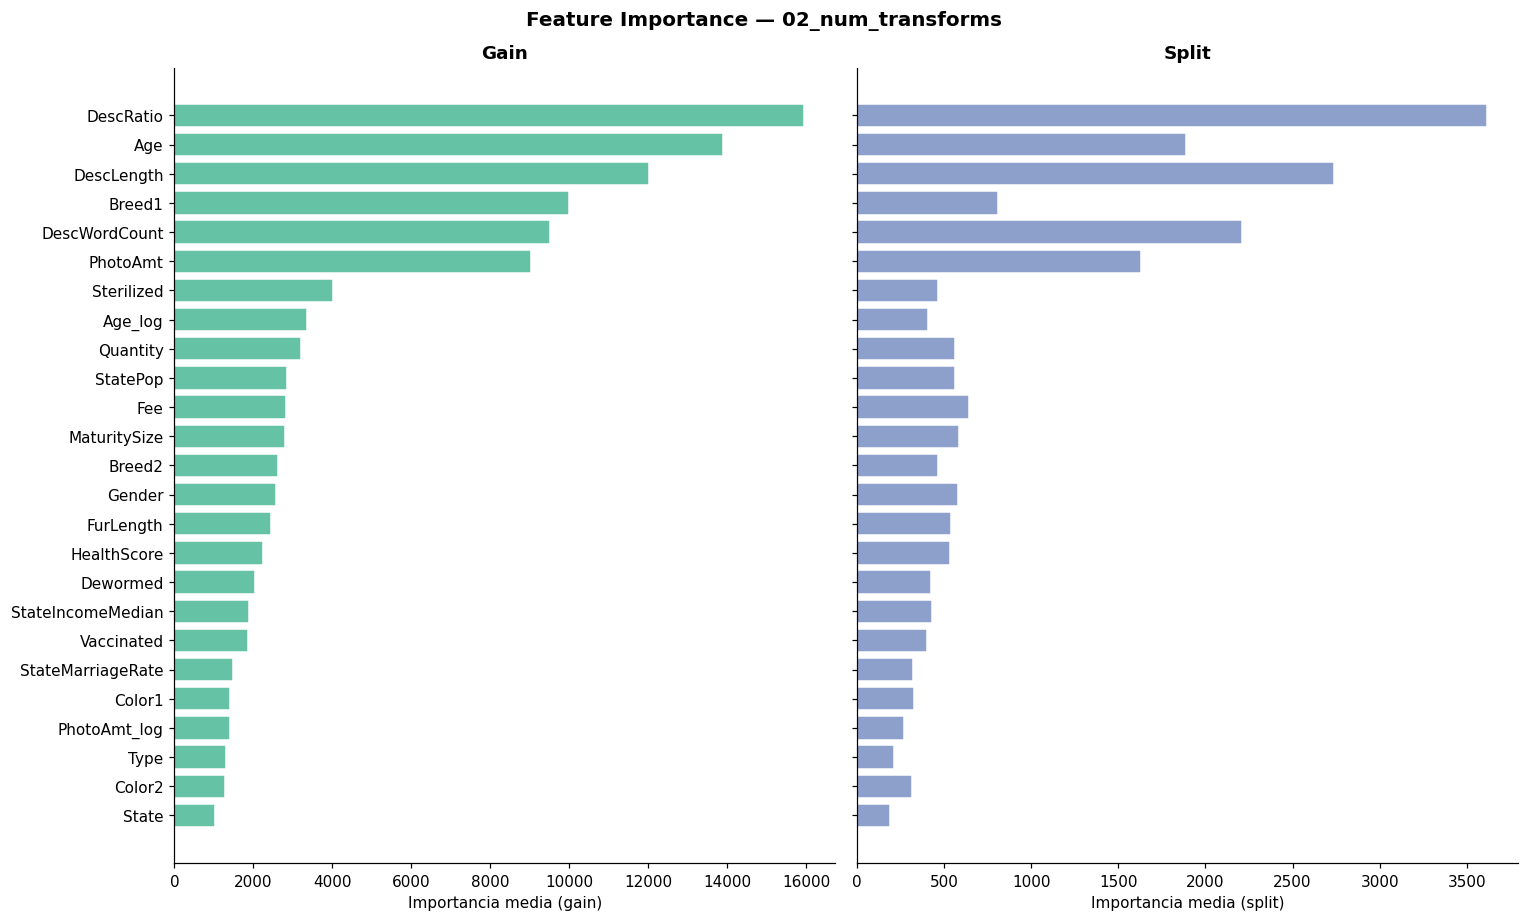

In [41]:
plot_results(y, result_42['oof_preds'], title='02_num_transforms')
plot_importance(result_42['feat_imp'], top_n=25, title='Feature Importance — 02_num_transforms')

In [42]:
should_keep(result_42, best_result, result_42['feat_imp'], top_n_check = 10)

  ΔQWK:          -0.0049
  Δstd:          -0.0039  (negativo = más estable)
  Nuevas en top-10: ['Age_log']
  → Caída mayor a 0.002. Se sugiere DESCARTAR.


False

Si bien no aporta mejoras en QWK, las métricas parecen tener valor en el Feature Importance. Se evalúa el mismo modelo pero eliminando las variables de origen.

In [43]:
NEW_NUM = ['Age_log',
          'Fee_log',
          'Qty_log'
          ]

features_sin_originales = [f for f in CURRENT_FEATURES 
                            if f not in ['Age', 
                                         'Fee', 
                                         'Quantity'
                            ]]

CURRENT_FEATURES_42_reemplazo = features_sin_originales + NEW_NUM
X_42rep = df_fe[CURRENT_FEATURES_42_reemplazo]

print(f'Features nuevas (4.2): {NEW_NUM}')
print(f'Total features: {len(CURRENT_FEATURES_42_reemplazo)}')
print('\n' + '='*55)
print('EXPERIMENTO 2: + Logaritmos con reemplazo')
print('='*55)

result_42rep = run_cv(X_42rep, 
                    y, 
                    BASELINE_PARAMS, 
                    cat_features = categoricals,
                    experiment_name='02_num_transforms_rep')
tracker.log(result_42rep)
delta(result_42rep, best_result)

Features nuevas (4.2): ['Age_log', 'Fee_log', 'Qty_log']
Total features: 35

EXPERIMENTO 2: + Logaritmos con reemplazo
  Fold 1: QWK=0.3724  Acc=0.4201  F1=0.3359  (best iter=95)
  Fold 2: QWK=0.3493  Acc=0.4094  F1=0.3181  (best iter=60)
  Fold 3: QWK=0.3630  Acc=0.4232  F1=0.3306  (best iter=69)
  Fold 4: QWK=0.3564  Acc=0.4052  F1=0.3142  (best iter=64)
  Fold 5: QWK=0.3942  Acc=0.4289  F1=0.3540  (best iter=79)

  ► 02_num_transforms_rep
    QWK  0.3671 ± 0.0156
    Acc  0.4174
    F1   0.3306
  ΔQWK vs. referencia: -0.0055


np.float64(-0.005510793390064328)

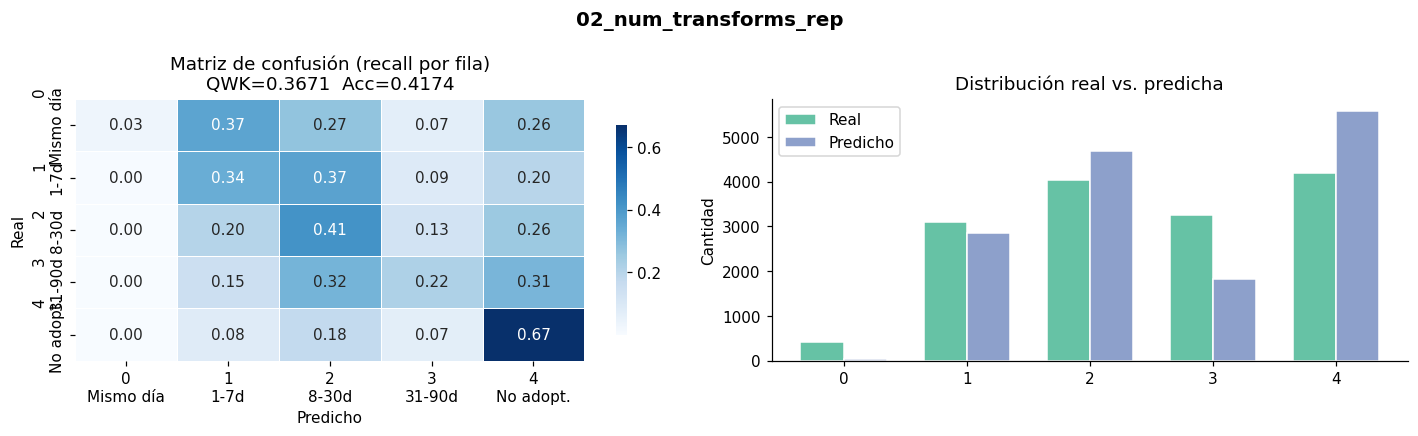

              precision    recall  f1-score   support

  0-MismoDía       0.34      0.03      0.06       410
  1-1ªSemana       0.37      0.34      0.35      3090
    2-1erMes       0.36      0.41      0.38      4035
 3-2do3erMes       0.39      0.22      0.28      3255
  4-NoAdopt.       0.50      0.67      0.57      4192

    accuracy                           0.42     14982
   macro avg       0.39      0.34      0.33     14982
weighted avg       0.41      0.42      0.40     14982



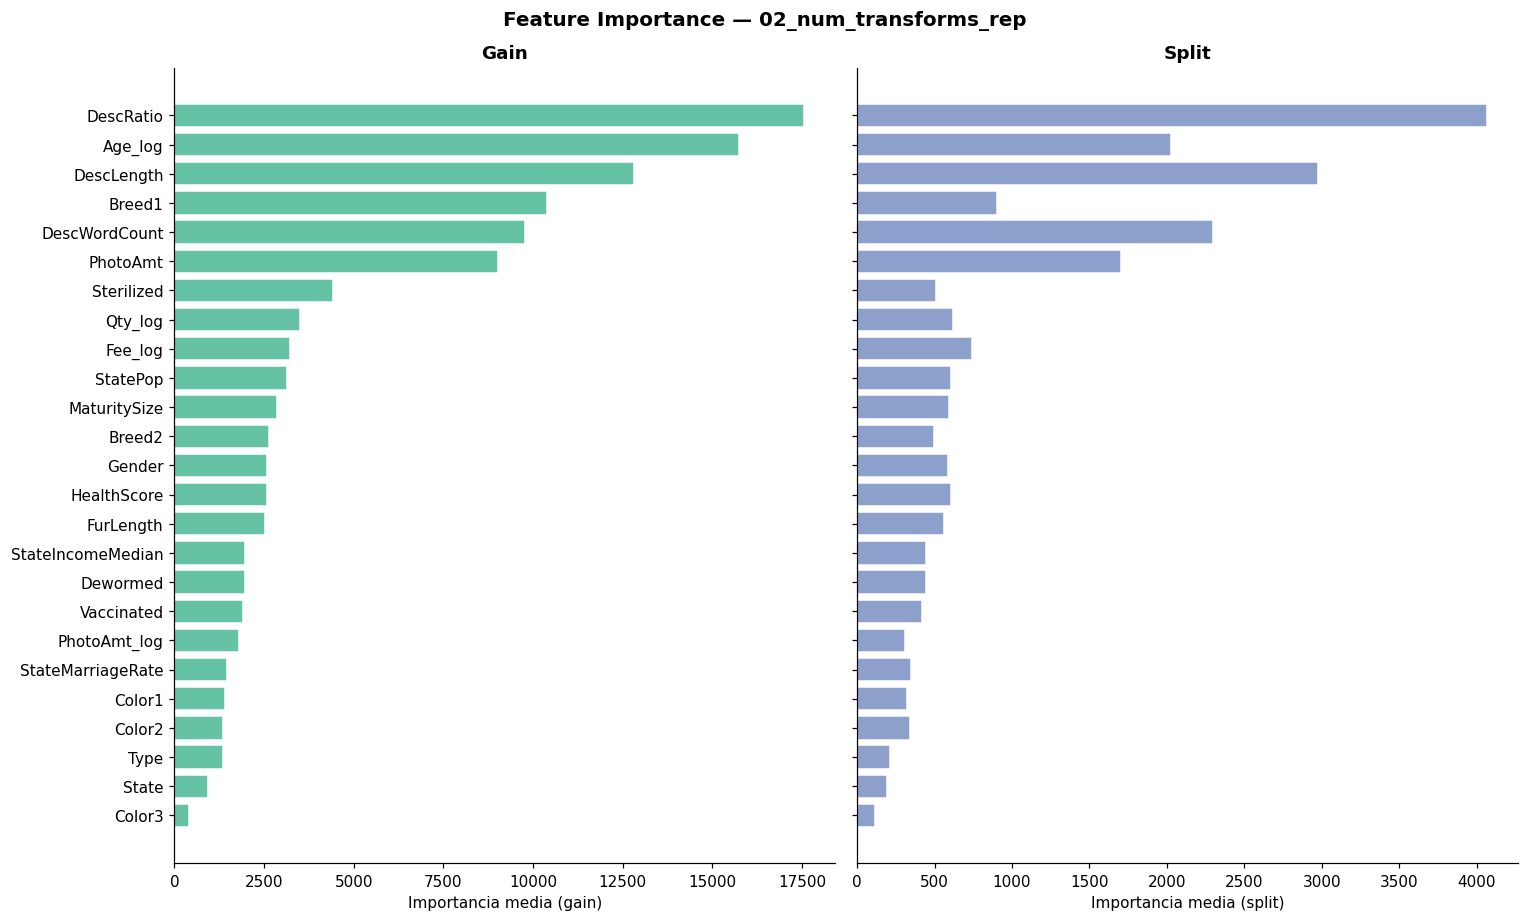

In [44]:
plot_results(y, result_42rep['oof_preds'], title='02_num_transforms_rep')
plot_importance(result_42rep['feat_imp'], top_n=25, title='Feature Importance — 02_num_transforms_rep')

In [45]:
should_keep(result_42rep, best_result, result_42rep['feat_imp'], top_n_check = 10)

  ΔQWK:          -0.0055
  Δstd:          -0.0066  (negativo = más estable)
  Nuevas en top-10: ['Age_log', 'Qty_log', 'Fee_log']
  → Caída mayor a 0.002. Se sugiere DESCARTAR.


False

Tampoco se registran mejoras al quitar las variables de origen.

## 4.3 Features de interacción

Multiplicaciones entre features. Se busca identificar interacciones entre variables que puedan ser explicativas de la variable objetivo, optimizando los cortes que realiza el algoritmo. 

In [46]:
df_fe['Type_x_Age']    = df_fe['Type']    * df_fe['Age']
df_fe['Type_x_IsFree'] = df_fe['Type']    * df_fe['IsFree']
df_fe['Age_x_IsFree']  = df_fe['Age'] * df_fe['IsFree']
df_fe['Fee_x_Photo']   = df_fe['Fee'] * df_fe['PhotoAmt']
df_fe['Age_x_Photo']   = df_fe['Age'] * df_fe['PhotoAmt']
df_fe['Health_x_Type'] = df_fe['Health']  * df_fe['Type']
df_fe['Type_x_Mixed']  = df_fe['Type']    * df_fe['MixedBreed']

NEW_INT = ['Type_x_Age', 
           'Type_x_IsFree', 
           'Age_x_IsFree',
           'Fee_x_Photo', 
           'Age_x_Photo', 
           'Health_x_Type', 
           'Type_x_Mixed'
          ]

CURRENT_FEATURES_43 = CURRENT_FEATURES + NEW_INT
X_43 = df_fe[CURRENT_FEATURES_43]

print(f'Features nuevas (4.3): {NEW_INT}')
print(f'Total features: {len(CURRENT_FEATURES_43)}')
print('\n' + '='*55)
print('EXPERIMENTO 3: + Interacciones')
print('='*55)

result_43 = run_cv(X_43, y, BASELINE_PARAMS, experiment_name='03_interactions')
tracker.log(result_43)
delta(result_43, best_result)

Features nuevas (4.3): ['Type_x_Age', 'Type_x_IsFree', 'Age_x_IsFree', 'Fee_x_Photo', 'Age_x_Photo', 'Health_x_Type', 'Type_x_Mixed']
Total features: 42

EXPERIMENTO 3: + Interacciones
  Fold 1: QWK=0.3674  Acc=0.4234  F1=0.3374  (best iter=76)
  Fold 2: QWK=0.3429  Acc=0.4117  F1=0.3305  (best iter=67)
  Fold 3: QWK=0.3272  Acc=0.4015  F1=0.3104  (best iter=68)
  Fold 4: QWK=0.3480  Acc=0.4095  F1=0.3217  (best iter=58)
  Fold 5: QWK=0.3890  Acc=0.4292  F1=0.3493  (best iter=98)

  ► 03_interactions
    QWK  0.3549 ± 0.0214
    Acc  0.4151
    F1   0.3299
  ΔQWK vs. referencia: -0.0177


np.float64(-0.017683423347332916)

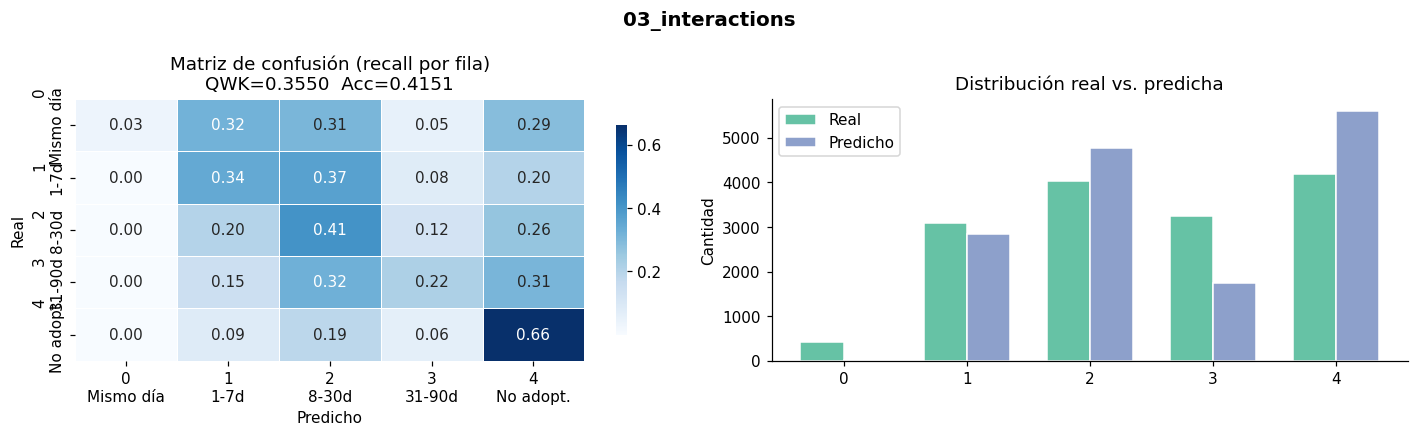

              precision    recall  f1-score   support

  0-MismoDía       0.50      0.03      0.06       410
  1-1ªSemana       0.37      0.34      0.36      3090
    2-1erMes       0.35      0.41      0.38      4035
 3-2do3erMes       0.41      0.22      0.28      3255
  4-NoAdopt.       0.50      0.66      0.57      4192

    accuracy                           0.42     14982
   macro avg       0.42      0.33      0.33     14982
weighted avg       0.41      0.42      0.40     14982



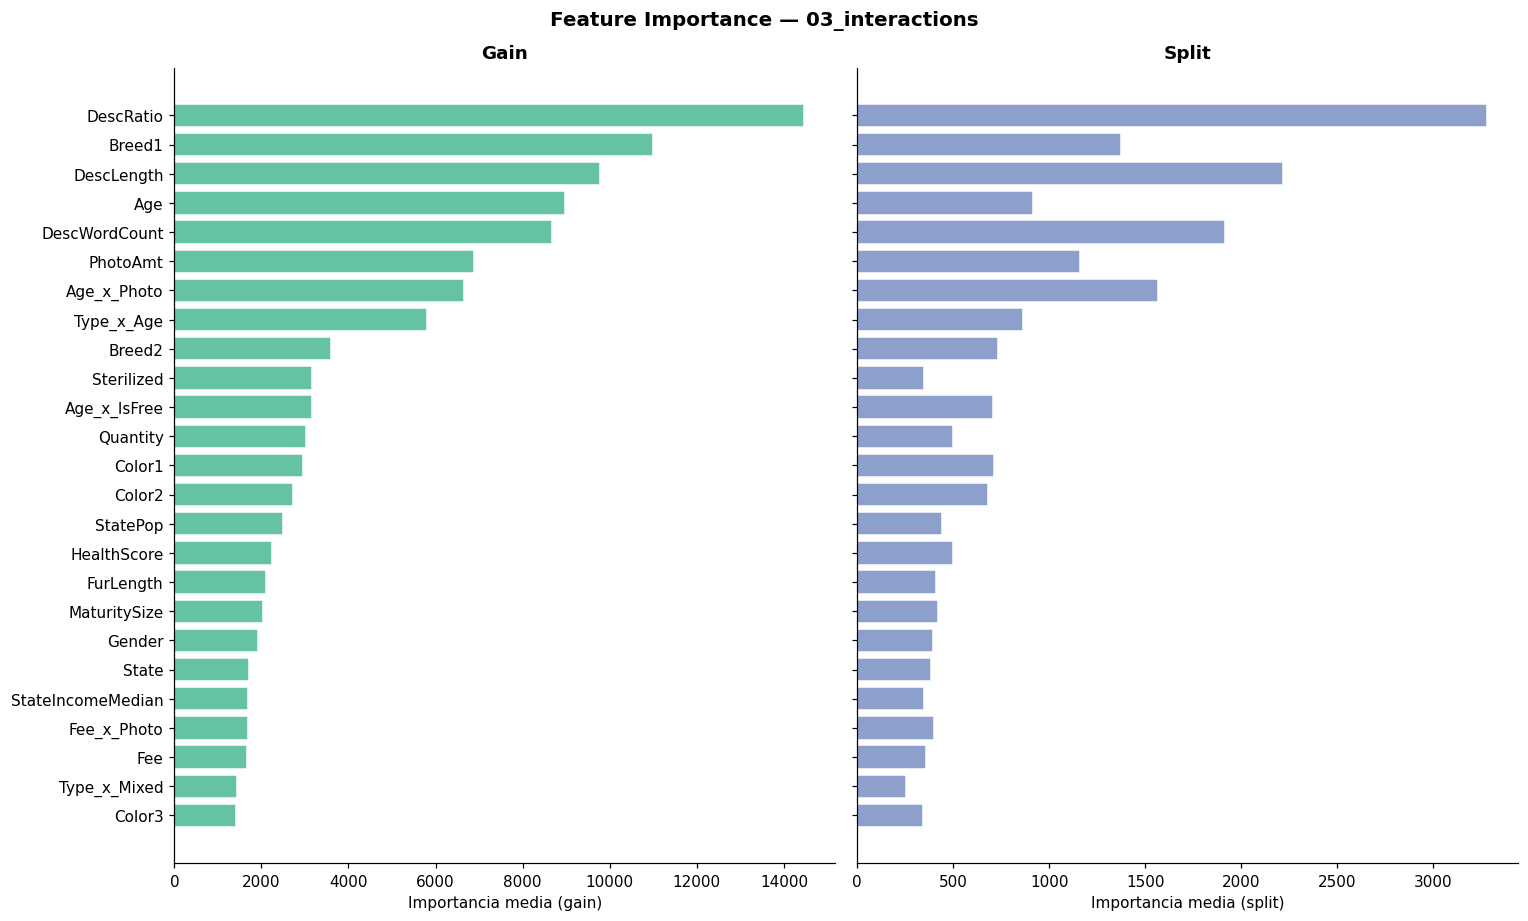

In [47]:
plot_results(y, result_43['oof_preds'], title='03_interactions')
plot_importance(result_43['feat_imp'], top_n=25, title='Feature Importance — 03_interactions')

In [48]:
should_keep(result_43, best_result, result_43['feat_imp'], top_n_check = 10)

  ΔQWK:          -0.0177
  Δstd:          -0.0008  (negativo = más estable)
  Nuevas en top-10: ['Age_x_Photo', 'Type_x_Age']
  → Caída mayor a 0.002. Se sugiere DESCARTAR.


False

Estas variables parecen generar interferencia. Particularmente se observa con la variable Age, que es utilizada en varios cruces y la variable original pierde mucho peso.

## 4.4a Aggregations por RescuerID

Estadísticas de comportamiento del rescatista: edad promedio de sus animales,
fee promedio, proporción de gratuitos, etc.

**Anti-leakage:** el parámetro `agg_config` le indica a `run_cv` que calcule
estas estadísticas dentro de cada fold, usando solo los datos de train.
Rescatistas que aparecen en val pero no en train reciben la media global de train.

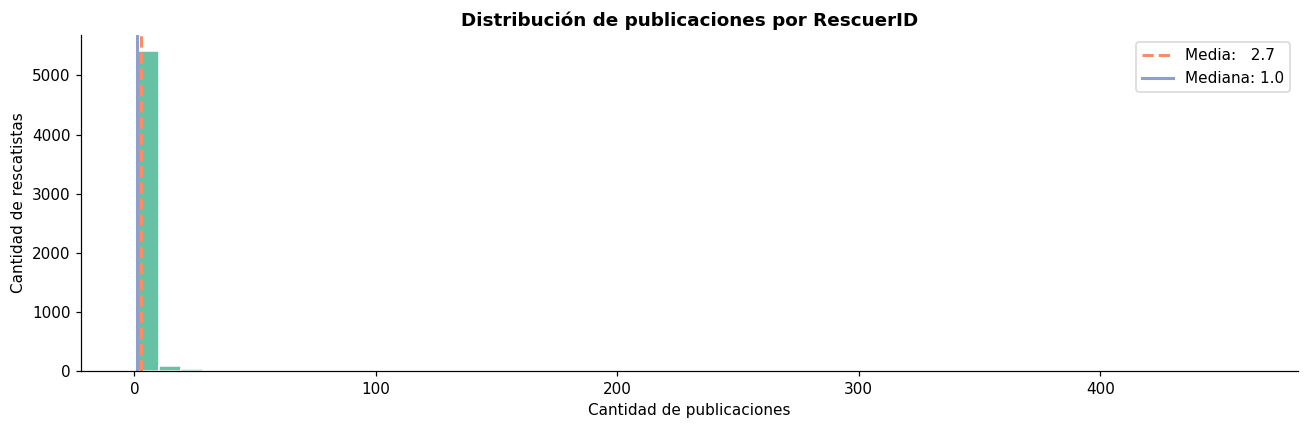

Total rescatistas únicos: 5,595
Media:                    2.7
Mediana:                  1.0
Máximo:                   459
% con 1 sola publicación: 67.7%
% con ≤2 publicaciones:   82.1%
% con ≤5 publicaciones:   93.0%
% con ≤10 publicaciones:  96.9%
% con ≤20 publicaciones:  98.6%
% con ≤50 publicaciones:  99.7%


In [49]:
# ── Distribución de frecuencias por RescuerID ─────────────────────────────────
freq_rescuer = df_fe['RescuerID'].value_counts()

media   = freq_rescuer.mean()
mediana = freq_rescuer.median()

fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(freq_rescuer.values, bins=50, color=PALETTE[0], edgecolor='white')

ax.axvline(media,   color=PALETTE[1], linewidth=2, linestyle='--', label=f'Media:   {media:.1f}')
ax.axvline(mediana, color=PALETTE[2], linewidth=2, linestyle='-',  label=f'Mediana: {mediana:.1f}')

ax.set_title('Distribución de publicaciones por RescuerID', fontweight='bold')
ax.set_xlabel('Cantidad de publicaciones')
ax.set_ylabel('Cantidad de rescatistas')
ax.legend()

plt.tight_layout()
plt.show()

# ── Resumen estadístico ───────────────────────────────────────────────────────
print(f'Total rescatistas únicos: {len(freq_rescuer):,}')
print(f'Media:                    {media:.1f}')
print(f'Mediana:                  {mediana:.1f}')
print(f'Máximo:                   {freq_rescuer.max()}')
print(f'% con 1 sola publicación: {(freq_rescuer == 1).mean()*100:.1f}%')
print(f'% con ≤2 publicaciones:   {(freq_rescuer <= 2).mean()*100:.1f}%')
print(f'% con ≤5 publicaciones:   {(freq_rescuer <= 5).mean()*100:.1f}%')
print(f'% con ≤10 publicaciones:  {(freq_rescuer <= 10).mean()*100:.1f}%')
print(f'% con ≤20 publicaciones:  {(freq_rescuer <= 20).mean()*100:.1f}%')
print(f'% con ≤50 publicaciones:  {(freq_rescuer <= 50).mean()*100:.1f}%')

RescuerID es una variable con fuerte asimetría: cuenta con muchos rescatistas con pocas publicaciones. Para evitar leakage con esta variable, se calculará el mejor parámetro de smoothing para acercar rescatistas con pocas publicaciones a la media global.

smoothing=   0  QWK=0.3925 ± 0.0153
smoothing=  10  QWK=0.3976 ± 0.0228
smoothing=  50  QWK=0.3923 ± 0.0120
smoothing= 100  QWK=0.3846 ± 0.0214


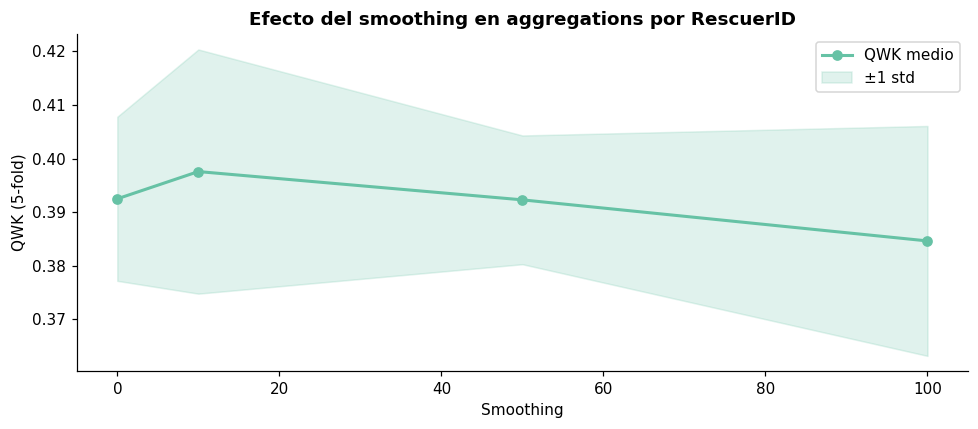

In [50]:
# ── Definición de las aggregations ────────────────────────────────────────────
# Formato: {columna_de_agrupación: {nombre_nueva_col: (col_fuente, función)}}
AGG_RESCUER = {
    'RescuerID': {
        'resc_mean_age'    : ('Age',      'mean'),
        'resc_mean_fee'    : ('Fee',      'mean'),
        'resc_mean_photos' : ('PhotoAmt', 'mean'),
        'resc_pct_dog'     : ('Type',     lambda x: (x == 1).mean()),
        'resc_n_breeds'    : ('Breed1',   'nunique'),
    }
}

# RescuerID debe estar en X para que run_cv pueda agrupar
AUX_COLS = ['RescuerID']
CURRENT_FEATURES_44a = CURRENT_FEATURES
X_44a = df_fe[CURRENT_FEATURES_44a + AUX_COLS]

resultados_smooth = []

for smooth in [0, 10, 50, 100]:
    r = run_cv(
        X_44a, y, BASELINE_PARAMS,
        cat_features=categoricals,
        agg_config=AGG_RESCUER,
        agg_smoothing=smooth,
        aux_cols=AUX_COLS,
        verbose=False,
        experiment_name=f'smooth_{smooth}'
    )
    resultados_smooth.append({
        'smoothing' : smooth,
        'qwk_mean'  : r['qwk_mean'],
        'qwk_std'   : r['qwk_std'],
    })
    print(f'smoothing={smooth:4d}  QWK={r["qwk_mean"]:.4f} ± {r["qwk_std"]:.4f}')

# Visualización
res_df = pd.DataFrame(resultados_smooth)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(res_df['smoothing'], res_df['qwk_mean'],
        marker='o', linewidth=2, color=PALETTE[0], label='QWK medio')
ax.fill_between(res_df['smoothing'],
                res_df['qwk_mean'] - res_df['qwk_std'],
                res_df['qwk_mean'] + res_df['qwk_std'],
                alpha=0.2, color=PALETTE[0], label='±1 std')
ax.set_title('Efecto del smoothing en aggregations por RescuerID', fontweight='bold')
ax.set_xlabel('Smoothing')
ax.set_ylabel('QWK (5-fold)')
ax.legend()
plt.tight_layout()
plt.show()

Un smoothing fijado en 50 mejora el QWK y genera el menor desvío estándar entre folds. Se utilizará este valor.

In [51]:
# ── Definición de las aggregations ────────────────────────────────────────────
# Formato: {columna_de_agrupación: {nombre_nueva_col: (col_fuente, función)}}
AGG_RESCUER = {
    'RescuerID': {
        'resc_mean_age'    : ('Age',      'mean'),
        'resc_mean_fee'    : ('Fee',      'mean'),
        'resc_mean_photos' : ('PhotoAmt', 'mean'),
        'resc_pct_dog'     : ('Type',     lambda x: (x == 1).mean()),
        'resc_n_breeds'    : ('Breed1',   'nunique'),
    }
}

AGG_SMOOTHING = {
    'RescuerID': 50
}

# RescuerID debe estar en X para que run_cv pueda agrupar
AUX_COLS = ['RescuerID']
CURRENT_FEATURES_44a = CURRENT_FEATURES
X_44a = df_fe[CURRENT_FEATURES_44a + AUX_COLS]

print('Features que se generarán dentro del fold:')
print([k for v in AGG_RESCUER.values() for k in v.keys()])
print(f'\nTotal features en X (incl. RescuerID auxiliar): {len(CURRENT_FEATURES_44a)}')
print('\n' + '='*55)
print('EXPERIMENTO 4a: + Aggregations por rescatista')
print('='*55)

result_44a = run_cv(
    X_44a, 
    y, 
    BASELINE_PARAMS,
    cat_features=categoricals,
    agg_config=AGG_RESCUER,
    agg_smoothing=AGG_SMOOTHING,       # rescatistas con <n publicaciones tiran a la media
    aux_cols=AUX_COLS, 
    experiment_name='04a_rescuer_agg'
)
tracker.log(result_44a)
delta(result_44a, best_result)

Features que se generarán dentro del fold:
['resc_mean_age', 'resc_mean_fee', 'resc_mean_photos', 'resc_pct_dog', 'resc_n_breeds']

Total features en X (incl. RescuerID auxiliar): 35

EXPERIMENTO 4a: + Aggregations por rescatista
  Fold 1: QWK=0.3874  Acc=0.4311  F1=0.3463  (best iter=82)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 2: QWK=0.3712  Acc=0.4341  F1=0.3504  (best iter=84)
  Fold 3: QWK=0.3974  Acc=0.4426  F1=0.3591  (best iter=63)
  Fold 4: QWK=0.4043  Acc=0.4332  F1=0.3563  (best iter=83)
  Fold 5: QWK=0.4012  Acc=0.4416  F1=0.3688  (best iter=75)

  ► 04a_rescuer_agg
    QWK  0.3923 ± 0.0120
    Acc  0.4365
    F1   0.3562
  ΔQWK vs. referencia: +0.0197


np.float64(0.01972933839905766)

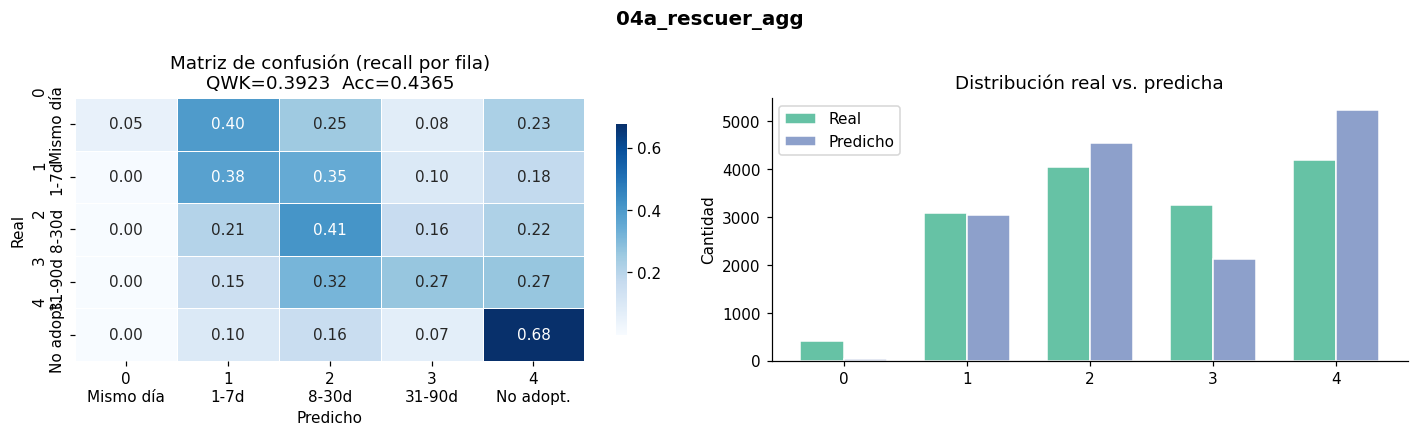

              precision    recall  f1-score   support

  0-MismoDía       0.58      0.05      0.09       410
  1-1ªSemana       0.38      0.38      0.38      3090
    2-1erMes       0.37      0.41      0.39      4035
 3-2do3erMes       0.40      0.27      0.32      3255
  4-NoAdopt.       0.54      0.68      0.60      4192

    accuracy                           0.44     14982
   macro avg       0.46      0.36      0.36     14982
weighted avg       0.43      0.44      0.42     14982



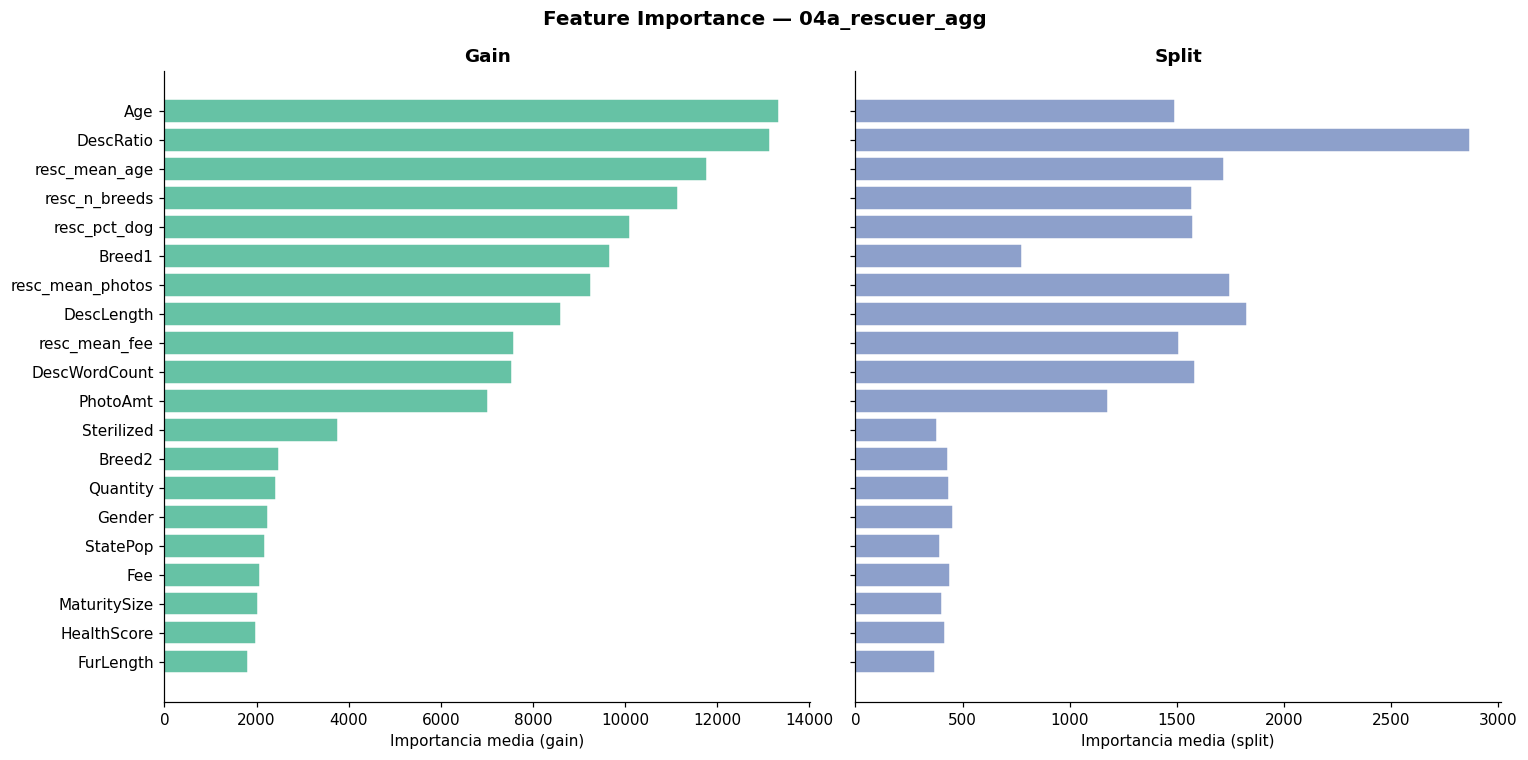

In [52]:
plot_results(y, result_44a['oof_preds'], title='04a_rescuer_agg')
plot_importance(result_44a['feat_imp'], title='Feature Importance — 04a_rescuer_agg')

Las variables agregadas a partir del Rescatista parecen cobrar mucha importancia. Esto puede deberse a que capturan información valiosa que correlaciona con la variable target, aunque también puede ser Leakage encubierto.
Para evaluar si este experimento genera Leakage, se realizará un experimento aleatorizando la variable target y evaluando el desempeño del modelo para identificar una memorización de falsos patrones.

In [53]:
# ── Test de leakage para aggregations ────────────────────────────────────────
# Si hay leakage, un target aleatorio también va a "mejorar" con las aggregations
# porque las estadísticas del grupo van a correlacionar con el target shuffleado

y_shuffled = y.sample(frac=1, random_state=SEED).reset_index(drop=True)

result_shuffle = run_cv(
    X_44a, y_shuffled, BASELINE_PARAMS,
    cat_features=categoricals,
    agg_config=AGG_RESCUER,
    agg_smoothing=AGG_SMOOTHING,
    aux_cols=AUX_COLS,
    experiment_name='leakage_test_shuffle'
)

result_baseline_shuffle = run_cv(
    X_base, y_shuffled, BASELINE_PARAMS,
    cat_features=categoricals,
    experiment_name='leakage_test_baseline'
)

print(f'\nQWK baseline con target real:     {result_baseline["qwk_mean"]:.4f}')
print(f'QWK baseline con target shuffle:  {result_baseline_shuffle["qwk_mean"]:.4f}')
print(f'QWK rescuer agg con target real:  {result_44a["qwk_mean"]:.4f}')
print(f'QWK rescuer agg con target shuffle: {result_shuffle["qwk_mean"]:.4f}')

  Fold 1: QWK=0.0025  Acc=0.2829  F1=0.1085  (best iter=1)
  Fold 2: QWK=-0.0059  Acc=0.2716  F1=0.1126  (best iter=1)
  Fold 3: QWK=0.0013  Acc=0.2794  F1=0.1110  (best iter=1)
  Fold 4: QWK=-0.0081  Acc=0.2797  F1=0.1114  (best iter=1)
  Fold 5: QWK=0.0104  Acc=0.2824  F1=0.1227  (best iter=2)

  ► leakage_test_shuffle
    QWK  0.0000 ± 0.0066
    Acc  0.2792
    F1   0.1132
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 1: QWK=0.0036  Acc=0.2796  F1=0.1271  (best iter=4)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 2: QWK=-0.0053  Acc=0.2756  F1=0.0974  (best iter=1)
[LightGBM] [Warning] Met categorical feature which contains sparse values. Consider renumbering to consecutive integers started from zero
  Fold 3: QWK=0.0053  Acc=0.2804  F1=0.1005  (best iter=1)
[LightGBM] [Warning] Met cat

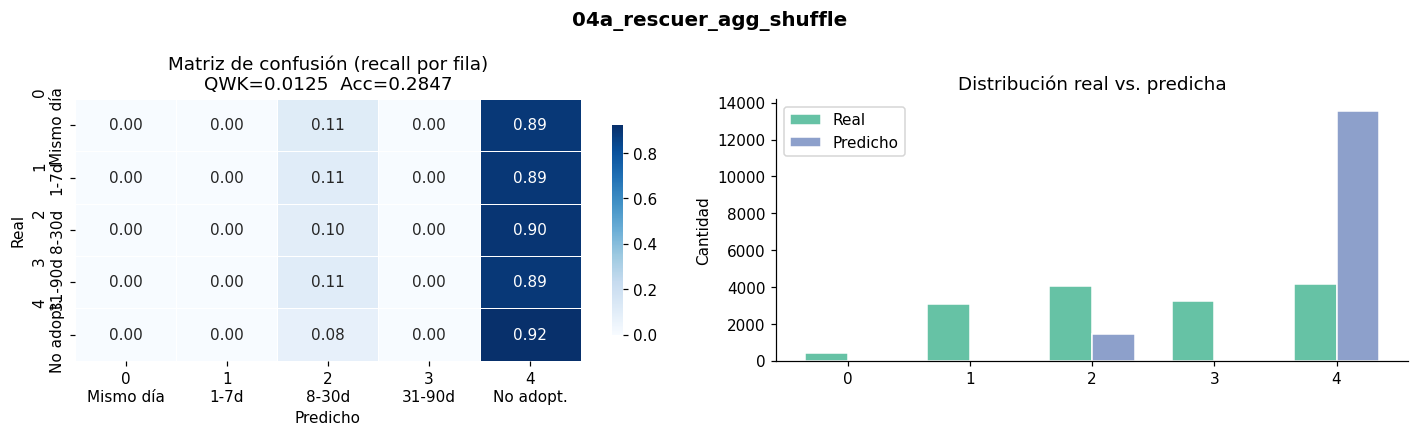

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

  0-MismoDía       0.00      0.00      0.00       410
  1-1ªSemana       0.00      0.00      0.00      3090
    2-1erMes       0.28      0.10      0.15      4035
 3-2do3erMes       0.00      0.00      0.00      3255
  4-NoAdopt.       0.29      0.92      0.44      4192

    accuracy                           0.28     14982
   macro avg       0.11      0.20      0.12     14982
weighted avg       0.15      0.28      0.16     14982



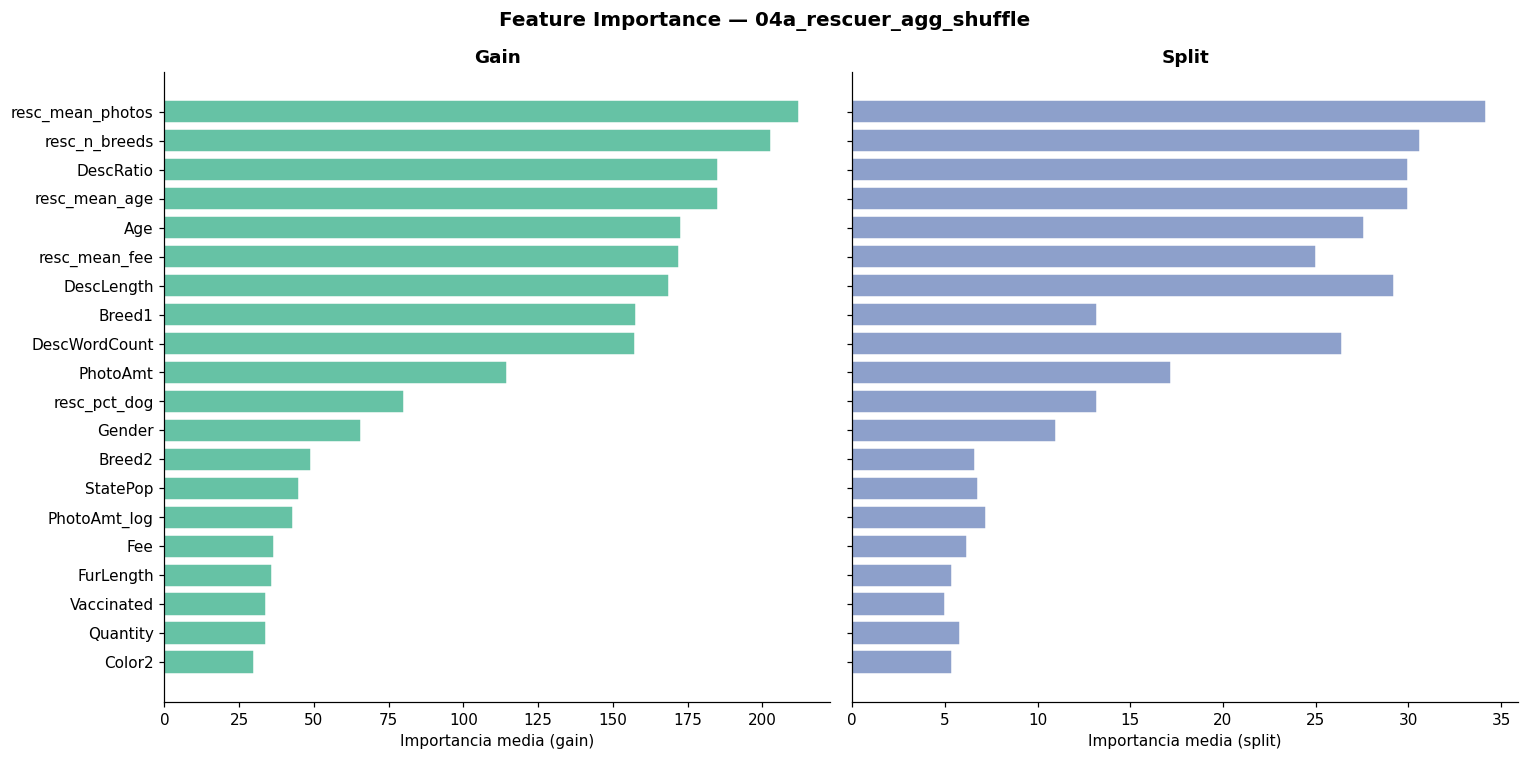

In [54]:
plot_results(y, result_shuffle['oof_preds'], title='04a_rescuer_agg_shuffle')
plot_importance(result_shuffle['feat_imp'], title='Feature Importance — 04a_rescuer_agg_shuffle')

El QWK se desploma, y si bien las variables de agregación de RescuerID aparecen en los primeros puestos del Feature Importance, no destacan frente a otras variables. Se incorporarán las variables

In [55]:
should_keep(result_44a, best_result, result_44a['feat_imp'], top_n_check = 10)
CURRENT_FEATURES = CURRENT_FEATURES_44a
best_result = result_44a

  ΔQWK:          +0.0197
  Δstd:          -0.0102  (negativo = más estable)
  Nuevas en top-10: ['resc_mean_age', 'resc_n_breeds', 'resc_pct_dog', 'resc_mean_photos', 'resc_mean_fee']
  → Mejora. Se sugiere INCORPORAR.


## 4.4b Aggregations por Breed

Estadísticas de comportamiento de la raza: edad promedio,
fee promedio, promedio de fotos.

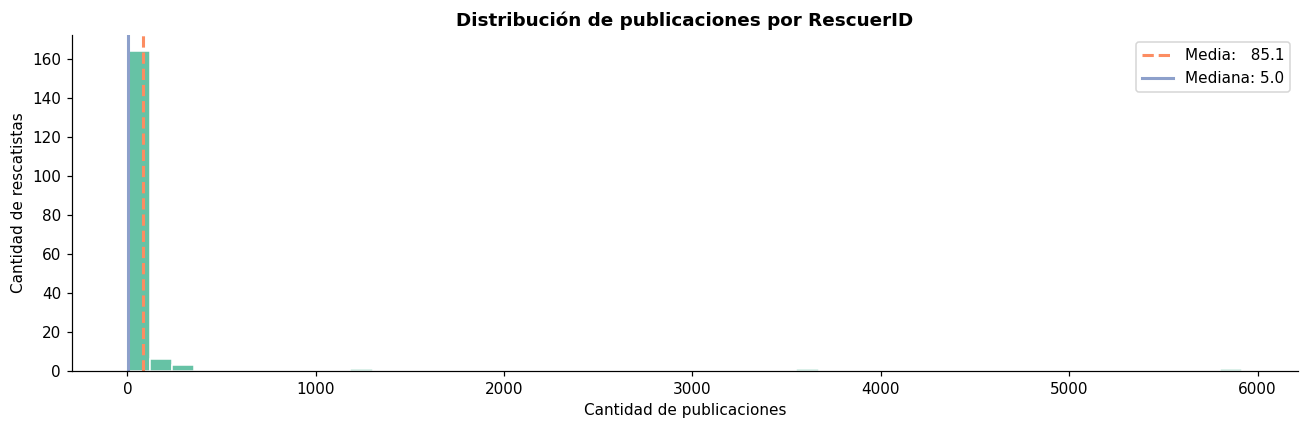

Total rescatistas únicos: 176
Media:                    85.1
Mediana:                  5.0
Máximo:                   5919
% con 1 sola publicación: 19.3%
% con ≤2 publicaciones:   34.7%
% con ≤5 publicaciones:   56.2%
% con ≤10 publicaciones:  66.5%
% con ≤20 publicaciones:  75.0%
% con ≤50 publicaciones:  85.8%


In [56]:
# ── Distribución de frecuencias por RescuerID ─────────────────────────────────
freq_rescuer = df_fe['Breed1'].value_counts()

media   = freq_rescuer.mean()
mediana = freq_rescuer.median()

fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(freq_rescuer.values, bins=50, color=PALETTE[0], edgecolor='white')

ax.axvline(media,   color=PALETTE[1], linewidth=2, linestyle='--', label=f'Media:   {media:.1f}')
ax.axvline(mediana, color=PALETTE[2], linewidth=2, linestyle='-',  label=f'Mediana: {mediana:.1f}')

ax.set_title('Distribución de publicaciones por RescuerID', fontweight='bold')
ax.set_xlabel('Cantidad de publicaciones')
ax.set_ylabel('Cantidad de rescatistas')
ax.legend()

plt.tight_layout()
plt.show()

# ── Resumen estadístico ───────────────────────────────────────────────────────
print(f'Total rescatistas únicos: {len(freq_rescuer):,}')
print(f'Media:                    {media:.1f}')
print(f'Mediana:                  {mediana:.1f}')
print(f'Máximo:                   {freq_rescuer.max()}')
print(f'% con 1 sola publicación: {(freq_rescuer == 1).mean()*100:.1f}%')
print(f'% con ≤2 publicaciones:   {(freq_rescuer <= 2).mean()*100:.1f}%')
print(f'% con ≤5 publicaciones:   {(freq_rescuer <= 5).mean()*100:.1f}%')
print(f'% con ≤10 publicaciones:  {(freq_rescuer <= 10).mean()*100:.1f}%')
print(f'% con ≤20 publicaciones:  {(freq_rescuer <= 20).mean()*100:.1f}%')
print(f'% con ≤50 publicaciones:  {(freq_rescuer <= 50).mean()*100:.1f}%')

La cardinalidad de las razas principales es menor que la de los rescatistas, y la distribución es algo más equilibrada. Esto permite disminuir el parámetro de smoothing.

In [57]:
# ── Definición de las aggregations ────────────────────────────────────────────
# Formato: {columna_de_agrupación: {nombre_nueva_col: (col_fuente, función)}}
AGG_BREED = {
    'RescuerID': {
        'resc_mean_age'    : ('Age',      'mean'),
        'resc_mean_fee'    : ('Fee',      'mean'),
        'resc_mean_photos' : ('PhotoAmt', 'mean'),
        'resc_pct_dog'     : ('Type',     lambda x: (x == 1).mean()),
        'resc_n_breeds'    : ('Breed1',   'nunique'),
    },
    'Breed1': {
        'breed_mean_age'    : ('Age',      'mean'),
        'breed_mean_fee'    : ('Fee',      'mean'),
        'breed_mean_photos' : ('PhotoAmt', 'mean')
    }
}

AGG_SMOOTHING = {
    'RescuerID': 50,
    'Breed1':    20
}

# RescuerID debe estar en X para que run_cv pueda agrupar
AUX_COLS = ['RescuerID']
CURRENT_FEATURES_44b = CURRENT_FEATURES
X_44b = df_fe[CURRENT_FEATURES_44b + AUX_COLS]

print('Features que se generarán dentro del fold:')
print([k for v in AGG_BREED.values() for k in v.keys()])
print(f'\nTotal features en X (incl. RescuerID auxiliar): {len(CURRENT_FEATURES_44b)}')
print('\n' + '='*55)
print('EXPERIMENTO 4b: + Aggregations por raza')
print('='*55)

categoricals_4b = [f for f in categoricals if f not in ['Breed1']]

result_44b = run_cv(
    X_44b, 
    y, 
    BASELINE_PARAMS,
    cat_features=categoricals_4b,
    agg_config=AGG_BREED,
    agg_smoothing=AGG_SMOOTHING,       # razas con <n publicaciones tiran a la media
    aux_cols=AUX_COLS, 
    experiment_name='04b_breed_agg'
)
tracker.log(result_44b)
delta(result_44b, best_result)

print('CURRENT_FEATURES:', CURRENT_FEATURES)
print('AUX_COLS:', AUX_COLS)
print('Columnas de X_44b:')
print(X_44b.dtypes[X_44b.dtypes == 'object'])

Features que se generarán dentro del fold:
['resc_mean_age', 'resc_mean_fee', 'resc_mean_photos', 'resc_pct_dog', 'resc_n_breeds', 'breed_mean_age', 'breed_mean_fee', 'breed_mean_photos']

Total features en X (incl. RescuerID auxiliar): 35

EXPERIMENTO 4b: + Aggregations por raza
  Fold 1: QWK=0.3939  Acc=0.4311  F1=0.3562  (best iter=82)
  Fold 2: QWK=0.3702  Acc=0.4284  F1=0.3587  (best iter=74)
  Fold 3: QWK=0.3947  Acc=0.4423  F1=0.3597  (best iter=78)
  Fold 4: QWK=0.4004  Acc=0.4299  F1=0.3408  (best iter=89)
  Fold 5: QWK=0.4158  Acc=0.4496  F1=0.3700  (best iter=83)

  ► 04b_breed_agg
    QWK  0.3950 ± 0.0147
    Acc  0.4363
    F1   0.3571
  ΔQWK vs. referencia: +0.0027
CURRENT_FEATURES: ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'Type', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'Breed1', 'Breed2', 'HasDesc', 'DescLength', 'DescWordCount', 'DescRatio', 'HasPhoto', 'HasVideo', 'PhotoAm

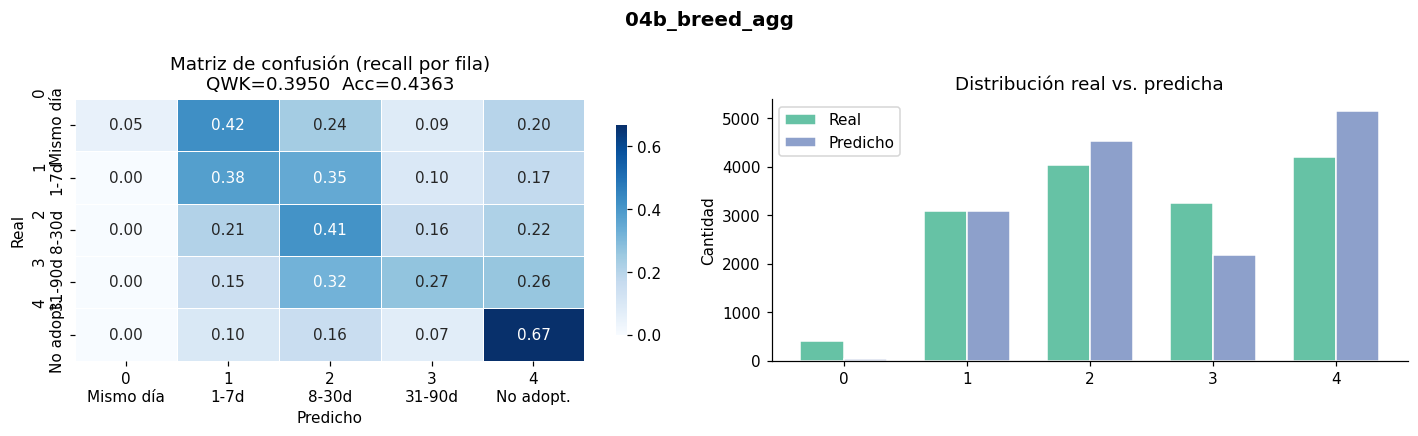

              precision    recall  f1-score   support

  0-MismoDía       0.68      0.05      0.10       410
  1-1ªSemana       0.38      0.38      0.38      3090
    2-1erMes       0.37      0.41      0.39      4035
 3-2do3erMes       0.40      0.27      0.32      3255
  4-NoAdopt.       0.54      0.67      0.60      4192

    accuracy                           0.44     14982
   macro avg       0.47      0.36      0.36     14982
weighted avg       0.44      0.44      0.42     14982



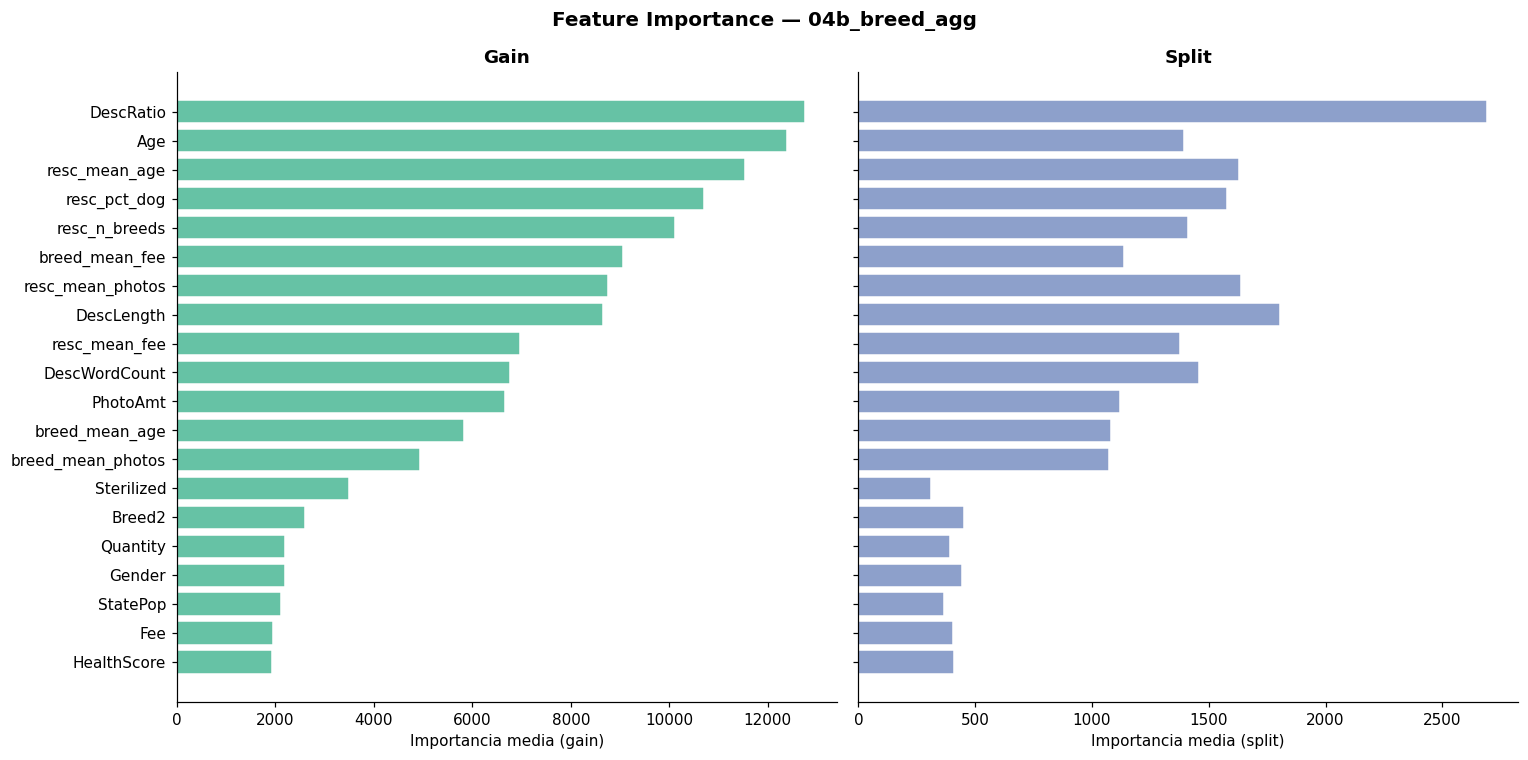

In [58]:
plot_results(y, result_44b['oof_preds'], title='04b_breed_agg')
plot_importance(result_44b['feat_imp'], title='Feature Importance — 04b_breed_agg')

Se observa efecto de las variables de raza: el QWK mejora y también se refleja en el Feature Importance.

In [59]:
should_keep(result_44b, best_result, result_44b['feat_imp'], top_n_check = 10)
CURRENT_FEATURES = CURRENT_FEATURES_44b
best_result = result_44b

  ΔQWK:          +0.0027
  Δstd:          +0.0027  (negativo = más estable)
  Nuevas en top-10: ['breed_mean_fee']
  → Mejora. Se sugiere INCORPORAR.


## 4.4c Aggregations por State

Estadísticas de comportamiento del rescatista: edad promedio de sus animales,
fee promedio, promedio de fotos, porcentaje de perros, y número de razas únicas.

In [60]:
# ── Definición de las aggregations ────────────────────────────────────────────
# Formato: {columna_de_agrupación: {nombre_nueva_col: (col_fuente, función)}}
AGG_STATE = {
    'RescuerID': {
        'resc_mean_age'    : ('Age',      'mean'),
        'resc_mean_fee'    : ('Fee',      'mean'),
        'resc_mean_photos' : ('PhotoAmt', 'mean'),
        'resc_pct_dog'     : ('Type',     lambda x: (x == 1).mean()),
        'resc_n_breeds'    : ('Breed1',   'nunique'),
    },
    'Breed1': {
        'breed_mean_age'    : ('Age',      'mean'),
        'breed_mean_fee'    : ('Fee',      'mean'),
        'breed_mean_photos' : ('PhotoAmt', 'mean')
    },
    'State' :{
        'state_mean_age'    : ('Age',      'mean'),
        'state_mean_fee'    : ('Fee',      'mean'),
        'state_mean_photos' : ('PhotoAmt', 'mean'),
        'state_pct_dog'     : ('Type',     lambda x: (x == 1).mean()),
        'state_n_breeds'    : ('Breed1',   'nunique'),
    }
}

AGG_SMOOTHING = {
    'RescuerID': 50,
    'Breed1':    20,
    'State':      10,
}

# RescuerID y State deben estar en X para que run_cv pueda agrupar
AUX_COLS = ['RescuerID', 'State']
CURRENT_FEATURES_44c = CURRENT_FEATURES
X_44c = df_fe[CURRENT_FEATURES_44c + AUX_COLS]

print('Features que se generarán dentro del fold:')
print([k for v in AGG_STATE.values() for k in v.keys()])
print(f'\nTotal features en X (incl. RescuerID y State auxiliar): {len(CURRENT_FEATURES_44c)}')
print('\n' + '='*55)
print('EXPERIMENTO 4c: + Aggregations por estado')
print('='*55)

categoricals_sin_state = [f for f in categoricals if f not in ['State', 'Breed1']]

result_44c = run_cv(
    X_44c, 
    y, 
    BASELINE_PARAMS,
    cat_features=categoricals_sin_state,
    agg_config=AGG_STATE,
    agg_smoothing=AGG_SMOOTHING,       # rescatistas con <n publicaciones tiran a la media
    aux_cols=AUX_COLS, 
    experiment_name='04c_state_agg'
)
tracker.log(result_44c)
delta(result_44c, best_result)

print('CURRENT_FEATURES:', CURRENT_FEATURES)
print('AUX_COLS:', AUX_COLS)
print('Columnas de X_44c:')
print(X_44c.dtypes[X_44c.dtypes == 'object'])

Features que se generarán dentro del fold:
['resc_mean_age', 'resc_mean_fee', 'resc_mean_photos', 'resc_pct_dog', 'resc_n_breeds', 'breed_mean_age', 'breed_mean_fee', 'breed_mean_photos', 'state_mean_age', 'state_mean_fee', 'state_mean_photos', 'state_pct_dog', 'state_n_breeds']

Total features en X (incl. RescuerID y State auxiliar): 35

EXPERIMENTO 4c: + Aggregations por estado
  Fold 1: QWK=0.3812  Acc=0.4314  F1=0.3477  (best iter=77)
  Fold 2: QWK=0.3648  Acc=0.4274  F1=0.3427  (best iter=55)
  Fold 3: QWK=0.3779  Acc=0.4332  F1=0.3469  (best iter=73)
  Fold 4: QWK=0.3897  Acc=0.4319  F1=0.3454  (best iter=66)
  Fold 5: QWK=0.4174  Acc=0.4506  F1=0.3660  (best iter=95)

  ► 04c_state_agg
    QWK  0.3862 ± 0.0176
    Acc  0.4349
    F1   0.3497
  ΔQWK vs. referencia: -0.0088
CURRENT_FEATURES: ['Age', 'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt', 'Type', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State', 'Bree

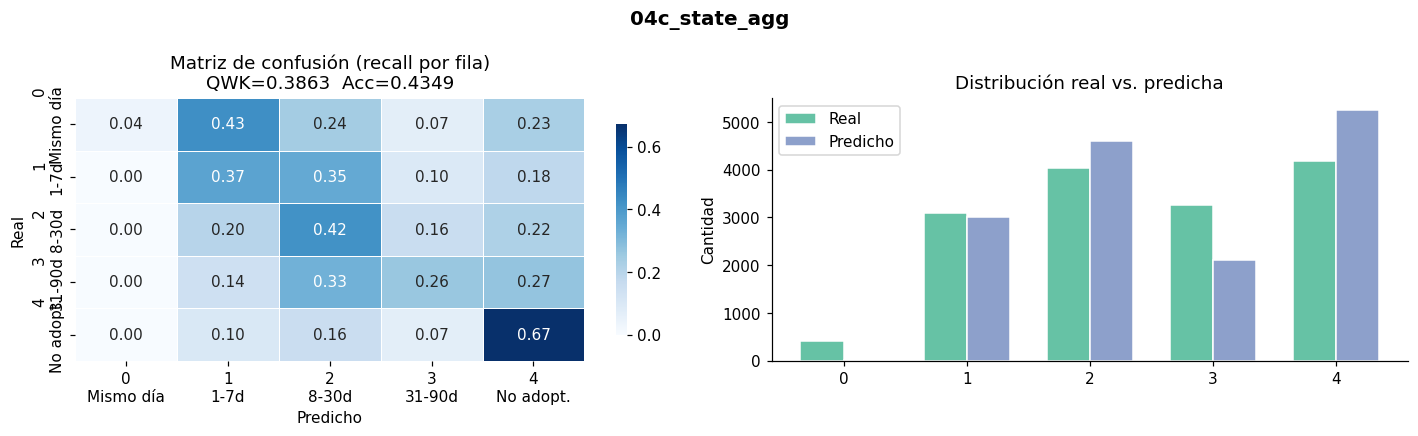

              precision    recall  f1-score   support

  0-MismoDía       0.56      0.04      0.07       410
  1-1ªSemana       0.38      0.37      0.37      3090
    2-1erMes       0.37      0.42      0.39      4035
 3-2do3erMes       0.40      0.26      0.32      3255
  4-NoAdopt.       0.54      0.67      0.60      4192

    accuracy                           0.43     14982
   macro avg       0.45      0.35      0.35     14982
weighted avg       0.43      0.43      0.42     14982



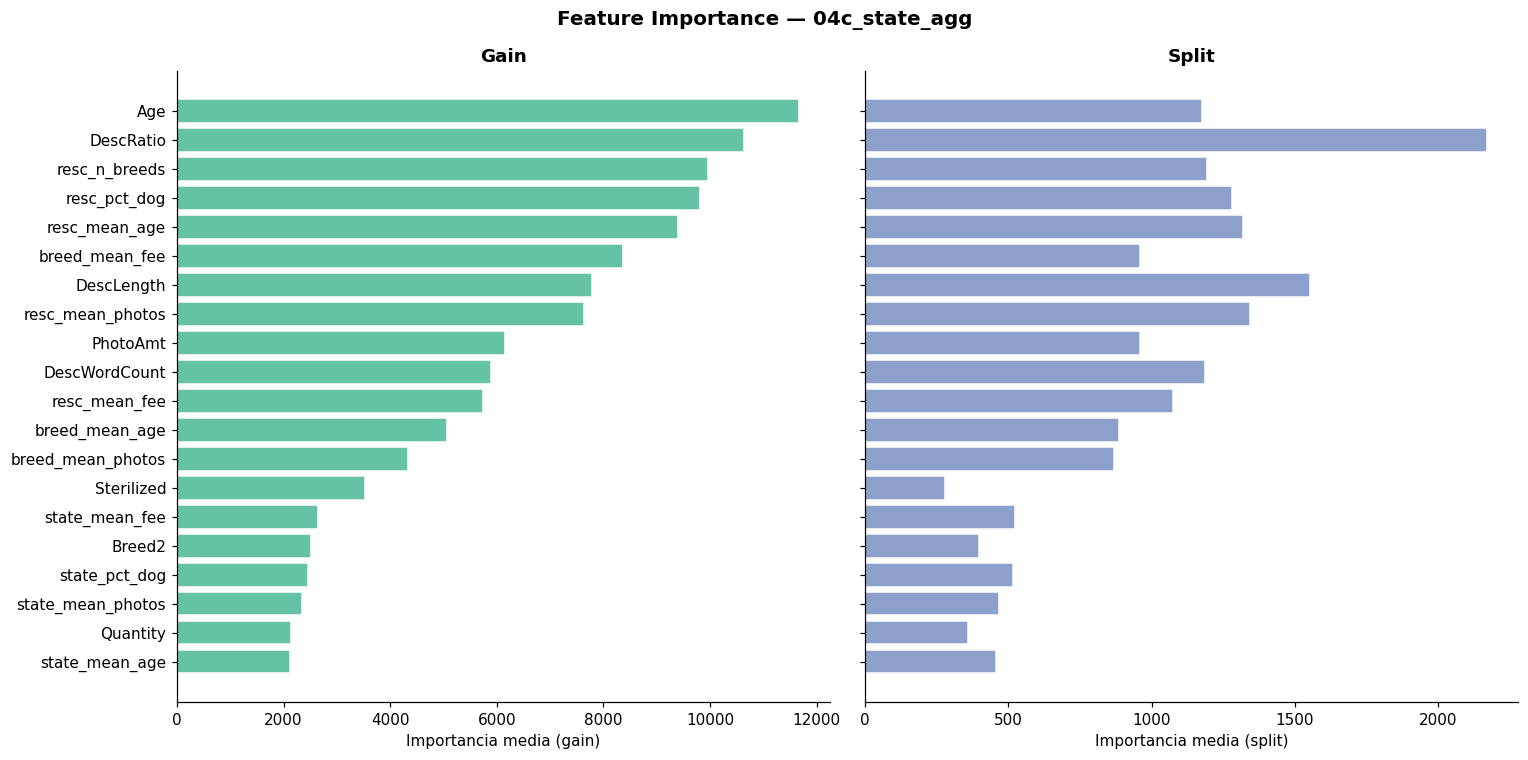

In [61]:
plot_results(y, result_44c['oof_preds'], title='04c_state_agg')
plot_importance(result_44c['feat_imp'], title='Feature Importance — 04c_state_agg')

In [62]:
should_keep(result_44c, best_result, result_44c['feat_imp'], top_n_check = 10)


  ΔQWK:          -0.0088
  Δstd:          +0.0029  (negativo = más estable)
  Nuevas en top-10: []
  → Caída mayor a 0.002. Se sugiere DESCARTAR.


False

## 4.5 Target Encoding

Variables de alta cardinalidad (`Breed1`, `State`, `RescuerID`) codificadas
con la media suavizada del target.

**Anti-leakage:** el parámetro `te_cols` le indica a `run_cv` que calcule
el encoding dentro de cada fold usando solo `y_tr`. El suavizado (smoothing=50)
hace que categorías con pocas observaciones tiren hacia la media global,
reduciendo el riesgo de overfitting en categorías raras.

In [63]:
TE_COLS = ['Breed1', 'State', 'RescuerID']
# run_cv generará automáticamente col+'_te' para cada una.

X_45 = df_fe[CURRENT_FEATURES + AUX_COLS]   # usa el mejor conjunto hasta ahora

print(f'Columnas a encodear: {TE_COLS}')
print(f'Columnas generadas dentro del fold: {[c+"_te" for c in TE_COLS]}')
print('\n' + '='*55)
print('EXPERIMENTO 5: + Target Encoding (Breed1, State, RescuerID)')
print('='*55)


result_45 = run_cv(
    X_45, y, BASELINE_PARAMS,
    agg_config=AGG_STATE,
    agg_smoothing=AGG_SMOOTHING,
    te_cols=TE_COLS,       # ← calculado dentro del fold, sin leakage
    te_smoothing='auto',
    aux_cols=AUX_COLS, 
    cat_features=categoricals_sin_state,
    experiment_name='05_target_encoding'
)
tracker.log(result_45)
delta(result_45, best_result)

Columnas a encodear: ['Breed1', 'State', 'RescuerID']
Columnas generadas dentro del fold: ['Breed1_te', 'State_te', 'RescuerID_te']

EXPERIMENTO 5: + Target Encoding (Breed1, State, RescuerID)
  Fold 1: QWK=0.3802  Acc=0.4348  F1=0.3523  (best iter=86)
  Fold 2: QWK=0.3693  Acc=0.4398  F1=0.3537  (best iter=73)
  Fold 3: QWK=0.3882  Acc=0.4469  F1=0.3572  (best iter=73)
  Fold 4: QWK=0.3955  Acc=0.4346  F1=0.3478  (best iter=70)
  Fold 5: QWK=0.4174  Acc=0.4546  F1=0.3660  (best iter=88)

  ► 05_target_encoding
    QWK  0.3901 ± 0.0162
    Acc  0.4421
    F1   0.3554
  ΔQWK vs. referencia: -0.0049


np.float64(-0.004871892210403295)

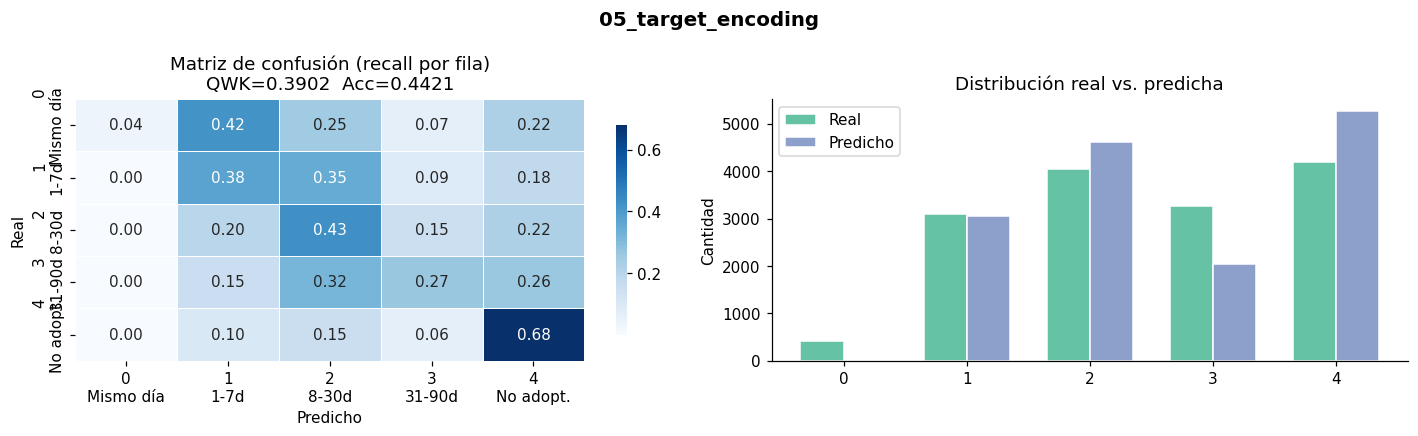

              precision    recall  f1-score   support

  0-MismoDía       0.60      0.04      0.07       410
  1-1ªSemana       0.38      0.38      0.38      3090
    2-1erMes       0.38      0.43      0.40      4035
 3-2do3erMes       0.42      0.27      0.33      3255
  4-NoAdopt.       0.54      0.68      0.60      4192

    accuracy                           0.44     14982
   macro avg       0.46      0.36      0.36     14982
weighted avg       0.44      0.44      0.43     14982



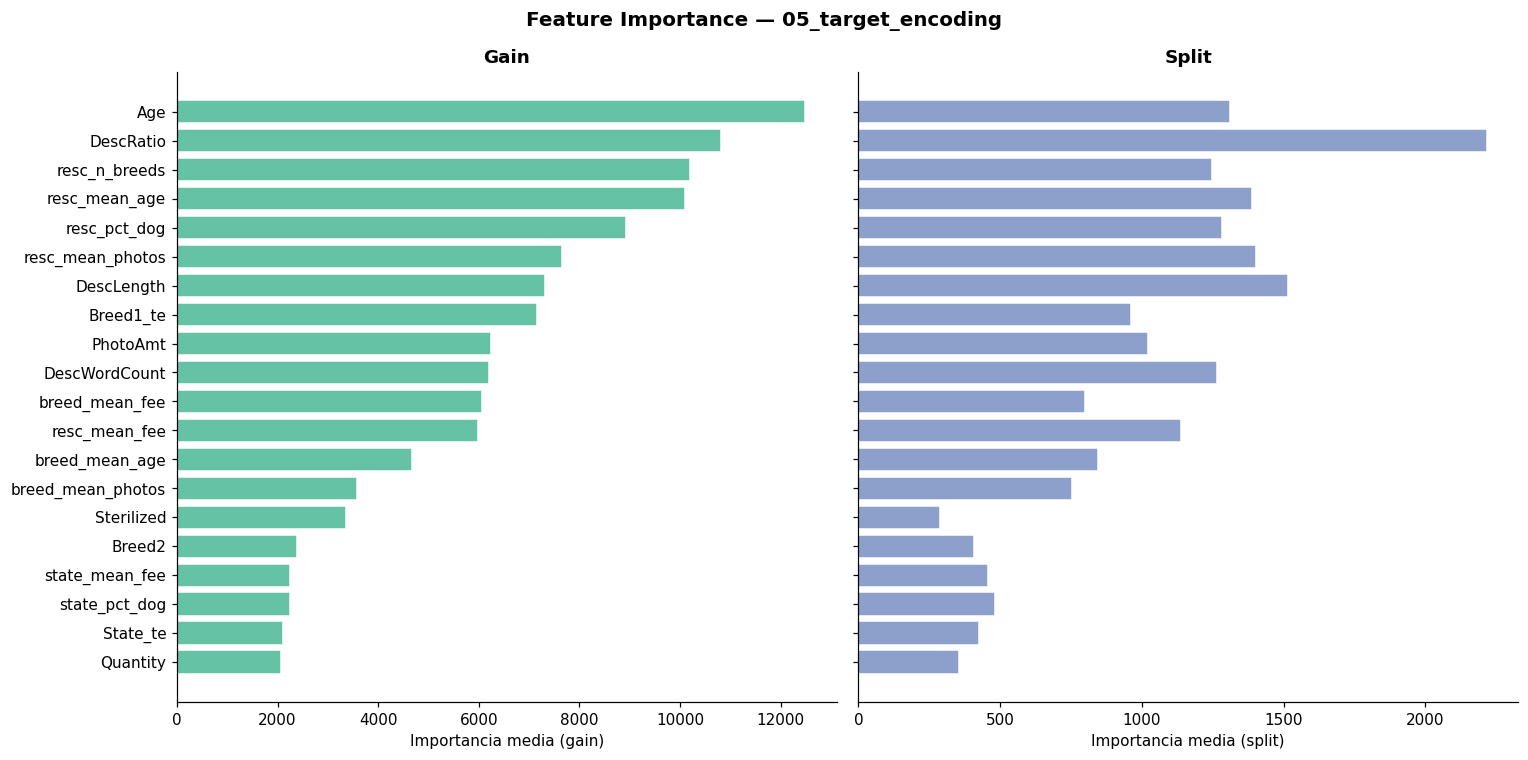

In [64]:
plot_results(y, result_45['oof_preds'], title='05_target_encoding')
plot_importance(result_45['feat_imp'], title='Feature Importance — 05_target_encoding')

El modelo empeora al incorproar el Target Encoding. Se realizará el mismo experimento, pero sin utilizar las variables que provienen de la agregación para evaluar si hubo interferencia.

In [65]:

AUX_COLS = ['RescuerID']
TE_COLS = ['Breed1', 'State', 'RescuerID']
# run_cv generará automáticamente col+'_te' para cada una.

X_45b = df_fe[CURRENT_FEATURES_41e + AUX_COLS]   # usa el mejor conjunto hasta ahora

print(f'Columnas a encodear: {TE_COLS}')
print(f'Columnas generadas dentro del fold: {[c+"_te" for c in TE_COLS]}')
print('\n' + '='*55)
print('EXPERIMENTO 5b: + Target Encoding (Breed1, State, RescuerID)')
print('='*55)


result_45b = run_cv(
    X_45b, y, BASELINE_PARAMS,
    #agg_config=AGG_STATE,
    #agg_smoothing=AGG_SMOOTHING,
    te_cols=TE_COLS,       # ← calculado dentro del fold, sin leakage
    te_smoothing='auto',
    aux_cols=AUX_COLS, 
    cat_features=categoricals_sin_state,
    experiment_name='05b_target_encoding'
)
tracker.log(result_45b)
delta(result_45b, result_41e)

Columnas a encodear: ['Breed1', 'State', 'RescuerID']
Columnas generadas dentro del fold: ['Breed1_te', 'State_te', 'RescuerID_te']

EXPERIMENTO 5b: + Target Encoding (Breed1, State, RescuerID)
  Fold 1: QWK=0.4585  Acc=0.4611  F1=0.3718  (best iter=77)
  Fold 2: QWK=0.4363  Acc=0.4645  F1=0.3696  (best iter=86)
  Fold 3: QWK=0.4100  Acc=0.4453  F1=0.3562  (best iter=73)
  Fold 4: QWK=0.4509  Acc=0.4666  F1=0.3731  (best iter=73)
  Fold 5: QWK=0.4502  Acc=0.4640  F1=0.3850  (best iter=78)

  ► 05b_target_encoding
    QWK  0.4412 ± 0.0172
    Acc  0.4603
    F1   0.3711
  ΔQWK vs. referencia: +0.0686


np.float64(0.06861846924415849)

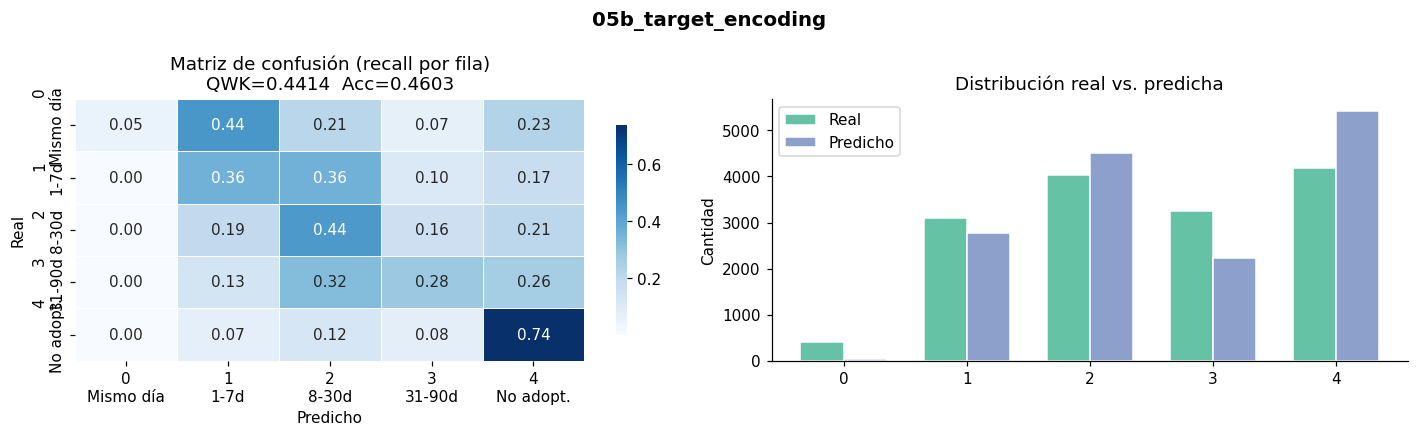

              precision    recall  f1-score   support

  0-MismoDía       0.54      0.05      0.09       410
  1-1ªSemana       0.40      0.36      0.38      3090
    2-1erMes       0.39      0.44      0.41      4035
 3-2do3erMes       0.41      0.28      0.33      3255
  4-NoAdopt.       0.57      0.74      0.64      4192

    accuracy                           0.46     14982
   macro avg       0.46      0.37      0.37     14982
weighted avg       0.45      0.46      0.44     14982



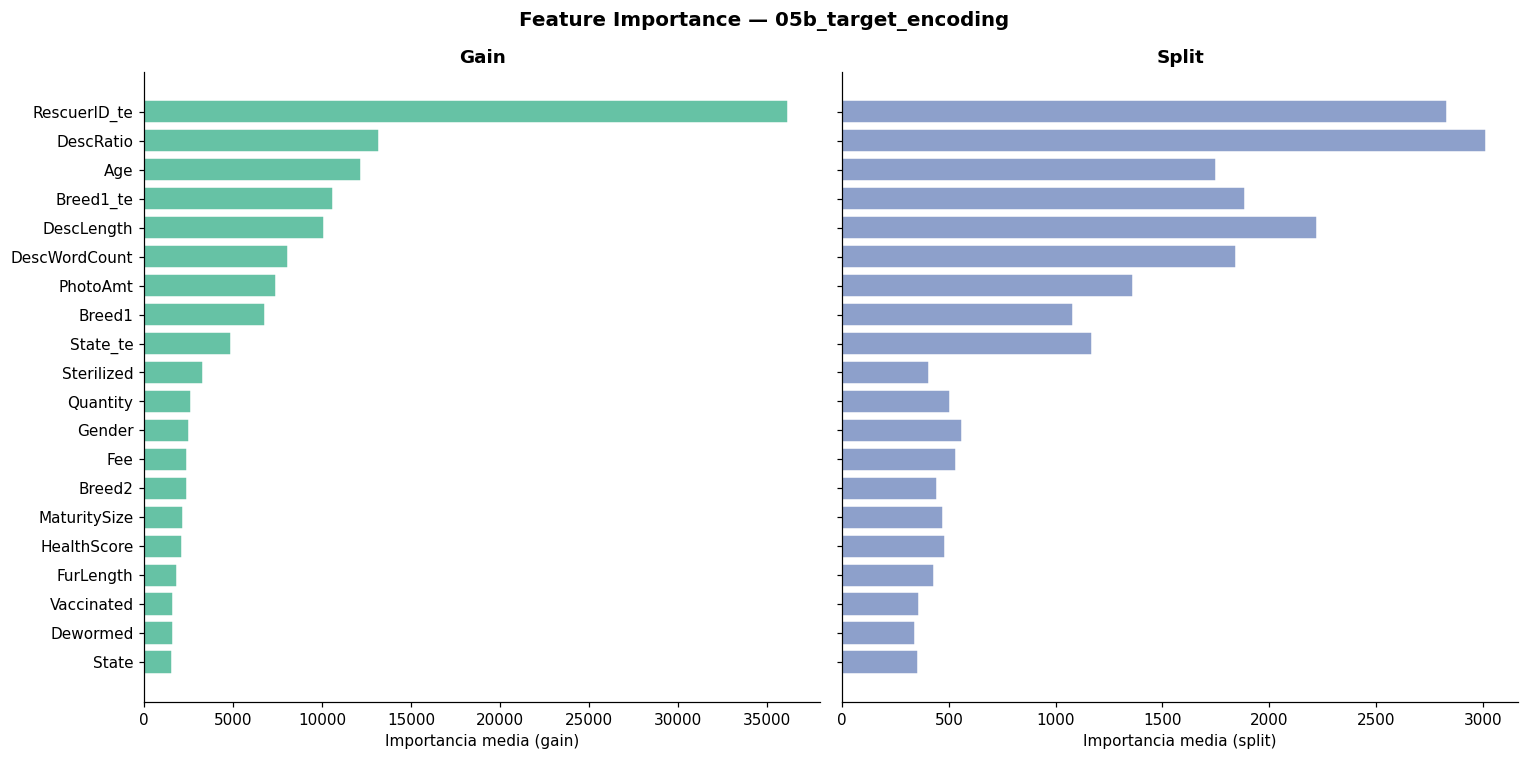

In [66]:
plot_results(y, result_45b['oof_preds'], title='05b_target_encoding')
plot_importance(result_45b['feat_imp'], title='Feature Importance — 05b_target_encoding')

El QWK crece fuertemente, la variable de Target Encoding calculada sobre el RescuerID cobra una importancia muy alta. Se sospecha Leakage.
Se realizará el experimento luego de aplicar un shuffle sobre la variable target.

In [67]:
y_shuffled = y.sample(frac=1, random_state=SEED).reset_index(drop=True)
result_45b_sanity = run_cv(
    X_45b, y_shuffled, BASELINE_PARAMS,
    agg_config=AGG_STATE,
    agg_smoothing=AGG_SMOOTHING,
    te_cols=TE_COLS,
    te_smoothing='auto',
    aux_cols=AUX_COLS,
    cat_features=categoricals_sin_state,
    experiment_name='05b_sanity_shuffle'
)

  Fold 1: QWK=-0.0053  Acc=0.2769  F1=0.1115  (best iter=1)
  Fold 2: QWK=-0.0014  Acc=0.2743  F1=0.1177  (best iter=2)
  Fold 3: QWK=-0.0020  Acc=0.2820  F1=0.1053  (best iter=1)
  Fold 4: QWK=0.0015  Acc=0.2790  F1=0.1072  (best iter=1)
  Fold 5: QWK=0.0059  Acc=0.2824  F1=0.1028  (best iter=1)

  ► 05b_sanity_shuffle
    QWK  -0.0003 ± 0.0038
    Acc  0.2789
    F1   0.1089


El QWK colapsa a valores menores a 0. Esto permite rechazar la idea del Leakage. Se evaluará, como segundo experimento, cómo cambia la correlación entre la variable de RescuerID con Target Encoder y la variable target en los sets de entrenamiento y testeo.

In [68]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
tr_idx, val_idx = next(skf.split(X_45, y))

X_tr = X_45b.iloc[tr_idx]
X_val = X_45b.iloc[val_idx]
y_tr = y.iloc[tr_idx]
y_val = y.iloc[val_idx]

te = TargetEncoder(smooth='auto', target_type='continuous', cv=5, random_state=SEED)
te_tr  = te.fit_transform(X_tr[['RescuerID']], y_tr)
te_val = te.transform(X_val[['RescuerID']])

print(f'Corr train: {np.corrcoef(te_tr.ravel(), y_tr)[0,1]:.4f}')
print(f'Corr val:   {np.corrcoef(te_val.ravel(), y_val)[0,1]:.4f}')
print(f'Diferencia: {np.corrcoef(te_tr.ravel(), y_tr)[0,1] - np.corrcoef(te_val.ravel(), y_val)[0,1]:.4f}')

Corr train: 0.3369
Corr val:   0.3972
Diferencia: -0.0603


La correlación crece en validación, lo que demuestra que la variable tiene capacidad explicativa por sí misma en lugar de Leakage.

## 4.6 Incorporación de los encoders de texto con PCA


---
# 5. Tuning de hiperparámetros con Optuna

Búsqueda bayesiana sobre el espacio de hiperparámetros de LightGBM.
Se usa 3-fold durante la búsqueda (velocidad) y se valida el mejor trial con 5-fold.

In [69]:
# X_final usa el mejor conjunto de features encontrado en FE

FINAL_FEATURES = CURRENT_FEATURES_41e
FINAL_CAT_FEATURES = categoricals_sin_state # categoricals_4b
#FINAL_AGG_CONFIG = 'None' #AGG_BREED
#FINAL_AGG_SMOOTHING = 'None' #AGG_SMOOTHING
FINAL_AUX_COLS = AUX_COLS
FINAL_TE_COLS = TE_COLS
FINAL_TE_SMOOTHING = 'auto'
X_final = df_fe[FINAL_FEATURES + FINAL_AUX_COLS].copy()

def objective(trial):
    params = {
    # ── Fijos ────────────────────────────────────────────────────────────────
    'objective'   : 'multiclass',
    'num_class'   : 5,
    'metric'      : 'multi_logloss',
    'verbose'     : -1,
    'n_estimators': 4000, 
    'learning_rate'    : trial.suggest_float('learning_rate',     0.001, 0.05, log=True),
    'num_leaves'       : trial.suggest_int('num_leaves',          31, 150),
    'max_depth'        : trial.suggest_int('max_depth',           4, 9),
    'min_child_samples': trial.suggest_int('min_child_samples',   20, 150),
    'subsample'        : trial.suggest_float('subsample',         0.3, 1.0),
    'bagging_freq'     : trial.suggest_int('bagging_freq',        1, 7),
    'colsample_bytree' : trial.suggest_float('colsample_bytree',  0.5, 1.0),
    #'reg_alpha'        : trial.suggest_float('reg_alpha',         1e-8, 1.0, log=True),
    #'reg_lambda'       : trial.suggest_float('reg_lambda',        1e-8, 1.0, log=True),
    'min_sum_hessian_in_leaf': trial.suggest_float('min_sum_hessian_in_leaf', 1e-3, 10.0, log=True),
}

    results = run_cv(
        X = X_final,   # mismas features que en FE
        y = y,
        params = params,
        cat_features = FINAL_CAT_FEATURES,   # los mismos que usaste en FE
        n_folds = 3,                   # 3 folds para velocidad
        verbose = False,
        experiment_name = f'trial_{trial.number}',
        te_cols=FINAL_TE_COLS,       # ← calculado dentro del fold, sin leakage
        te_smoothing=FINAL_TE_SMOOTHING,
        #agg_config=FINAL_AGG_CONFIG,
        #agg_smoothing=FINAL_AGG_SMOOTHING,
        aux_cols=FINAL_AUX_COLS,
    )

    # Pruning por fold (necesitás exponer fold_qwk de run_cv)
    for fold, qwk_fold in enumerate(results['fold_qwk']):
        trial.report(qwk_fold, fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return results['qwk_mean']


print('Función objetivo definida.')

Función objetivo definida.


In [70]:
import joblib

BO_VERSION = 'v1_target_encoding'  # ← cambiás esto para cada versión
BO_CACHE_PATH = f'/kaggle/working/study_{BO_VERSION}.pkl'

if os.path.exists(BO_CACHE_PATH):
    study = joblib.load(BO_CACHE_PATH)
    print(f'Study cargado desde caché: {BO_CACHE_PATH}')
    print(f'Trials completados: {len(study.trials)}')

else:
    N_TRIALS = 80
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1)
    )
    print(f'Iniciando búsqueda: {N_TRIALS} trials...')
    t0 = time.time()
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    print(f'\nTiempo total: {(time.time()-t0)/60:.1f} min')

    joblib.dump(study, BO_CACHE_PATH)
    print(f'Study guardado en: {BO_CACHE_PATH}')

print(f'\nMejor QWK (3-fold): {study.best_value:.4f}')
print('Mejores hiperparámetros:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Iniciando búsqueda: 80 trials...


  0%|          | 0/80 [00:00<?, ?it/s]


Tiempo total: 132.5 min
Study guardado en: /kaggle/working/study_v1_target_encoding.pkl

Mejor QWK (3-fold): 0.4460
Mejores hiperparámetros:
  learning_rate: 0.0019560010803163887
  num_leaves: 84
  max_depth: 5
  min_child_samples: 50
  subsample: 0.6990866027292076
  bagging_freq: 2
  colsample_bytree: 0.8376518487131104
  min_sum_hessian_in_leaf: 0.0015319413849570144


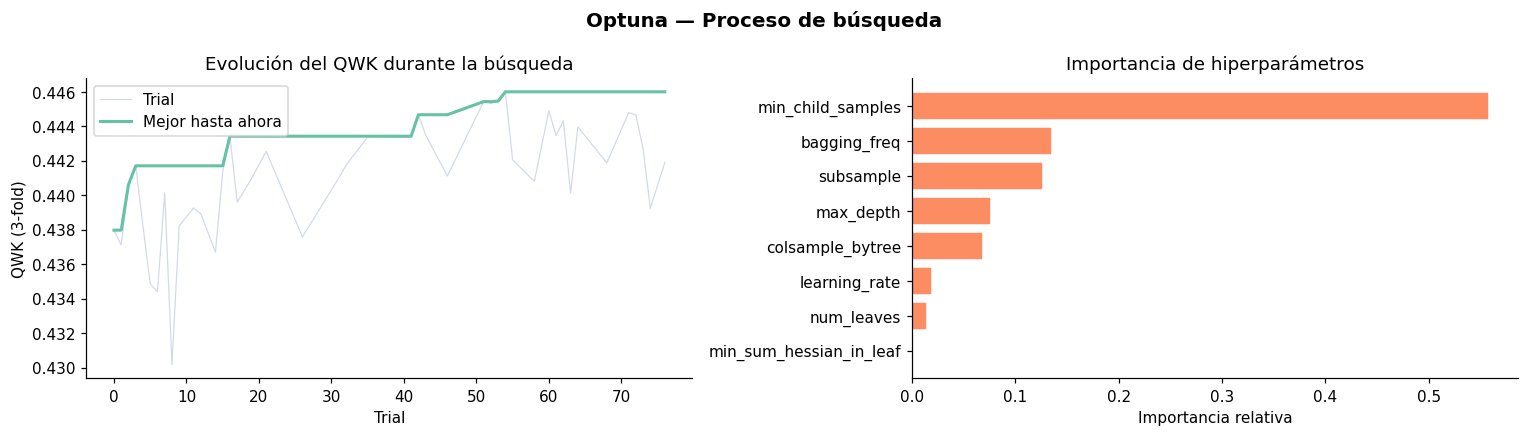

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trials_df = study.trials_dataframe()
completed = trials_df[trials_df['state'] == 'COMPLETE'].copy()
completed['best_so_far'] = completed['value'].cummax()

axes[0].plot(completed.index, completed['value'],
             alpha=0.4, color=PALETTE[2], linewidth=0.8, label='Trial')
axes[0].plot(completed.index, completed['best_so_far'],
             color=PALETTE[0], linewidth=2, label='Mejor hasta ahora')
axes[0].set_title('Evolución del QWK durante la búsqueda')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('QWK (3-fold)')
axes[0].legend()

try:
    imp = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame(list(imp.items()), columns=['Param','Importance']).sort_values('Importance')
    axes[1].barh(imp_df['Param'], imp_df['Importance'], color=PALETTE[1], edgecolor='white')
    axes[1].set_title('Importancia de hiperparámetros')
    axes[1].set_xlabel('Importancia relativa')
except Exception as e:
    axes[1].text(0.5, 0.5, f'No disponible:\n{e}', ha='center', va='center')
    axes[1].axis('off')

plt.suptitle('Optuna — Proceso de búsqueda', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [72]:
# Validación final del mejor trial con 5-fold
BEST_PARAMS = {
    'objective'   : 'multiclass',
    'num_class'   : 5,
    'metric'      : 'multi_logloss',
    'verbose'     : -1,
    'n_estimators': 3000,   # más estimadores con el LR bajo del tuning
    **study.best_params
}

print('='*55)
print('EXPERIMENTO FINAL: Mejor FE + Hiperparámetros tuneados (5-fold)')
print('='*55)

result_tuned = run_cv(
    X = X_final,   # mismas features que en FE
    y = y,
    params = BEST_PARAMS,
    cat_features = FINAL_CAT_FEATURES,   # los mismos que usaste en FE
    n_folds = 3,                   # 3 folds para velocidad
    verbose = False,
    experiment_name='09_tuned',

    te_cols=FINAL_TE_COLS,       # ← calculado dentro del fold, sin leakage
    te_smoothing=FINAL_TE_SMOOTHING,
    #agg_config=FINAL_AGG_CONFIG,
    #agg_smoothing=FINAL_AGG_SMOOTHING,
    aux_cols=FINAL_AUX_COLS,
    )


tracker.log(result_tuned)
delta(result_tuned, best_result)

EXPERIMENTO FINAL: Mejor FE + Hiperparámetros tuneados (5-fold)
  ΔQWK vs. referencia: +0.0500


np.float64(0.05001002701246832)

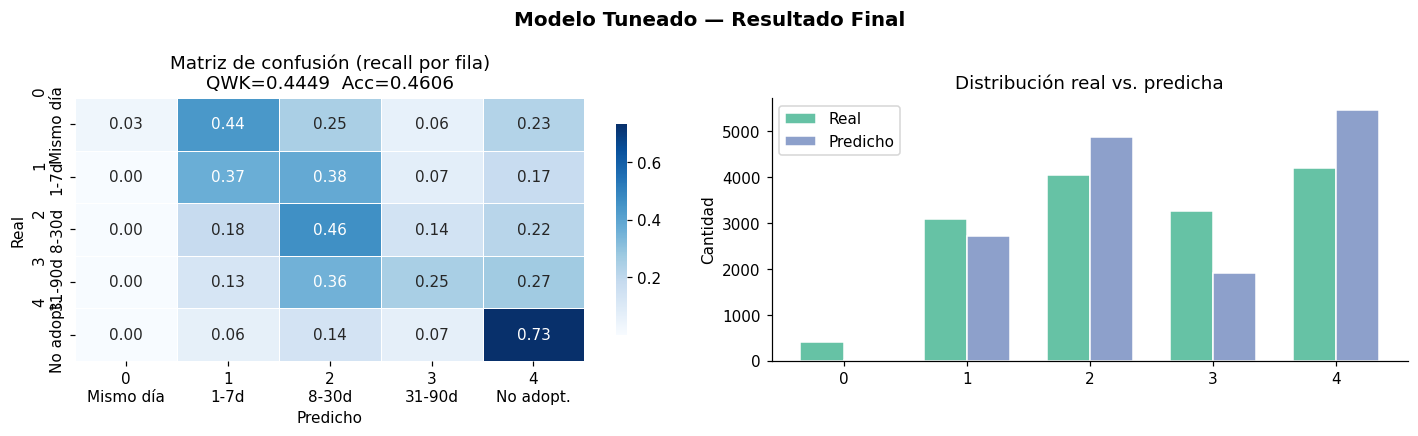

              precision    recall  f1-score   support

  0-MismoDía       0.50      0.03      0.06       410
  1-1ªSemana       0.42      0.37      0.39      3090
    2-1erMes       0.38      0.46      0.42      4035
 3-2do3erMes       0.43      0.25      0.32      3255
  4-NoAdopt.       0.56      0.73      0.64      4192

    accuracy                           0.46     14982
   macro avg       0.46      0.37      0.36     14982
weighted avg       0.45      0.46      0.44     14982



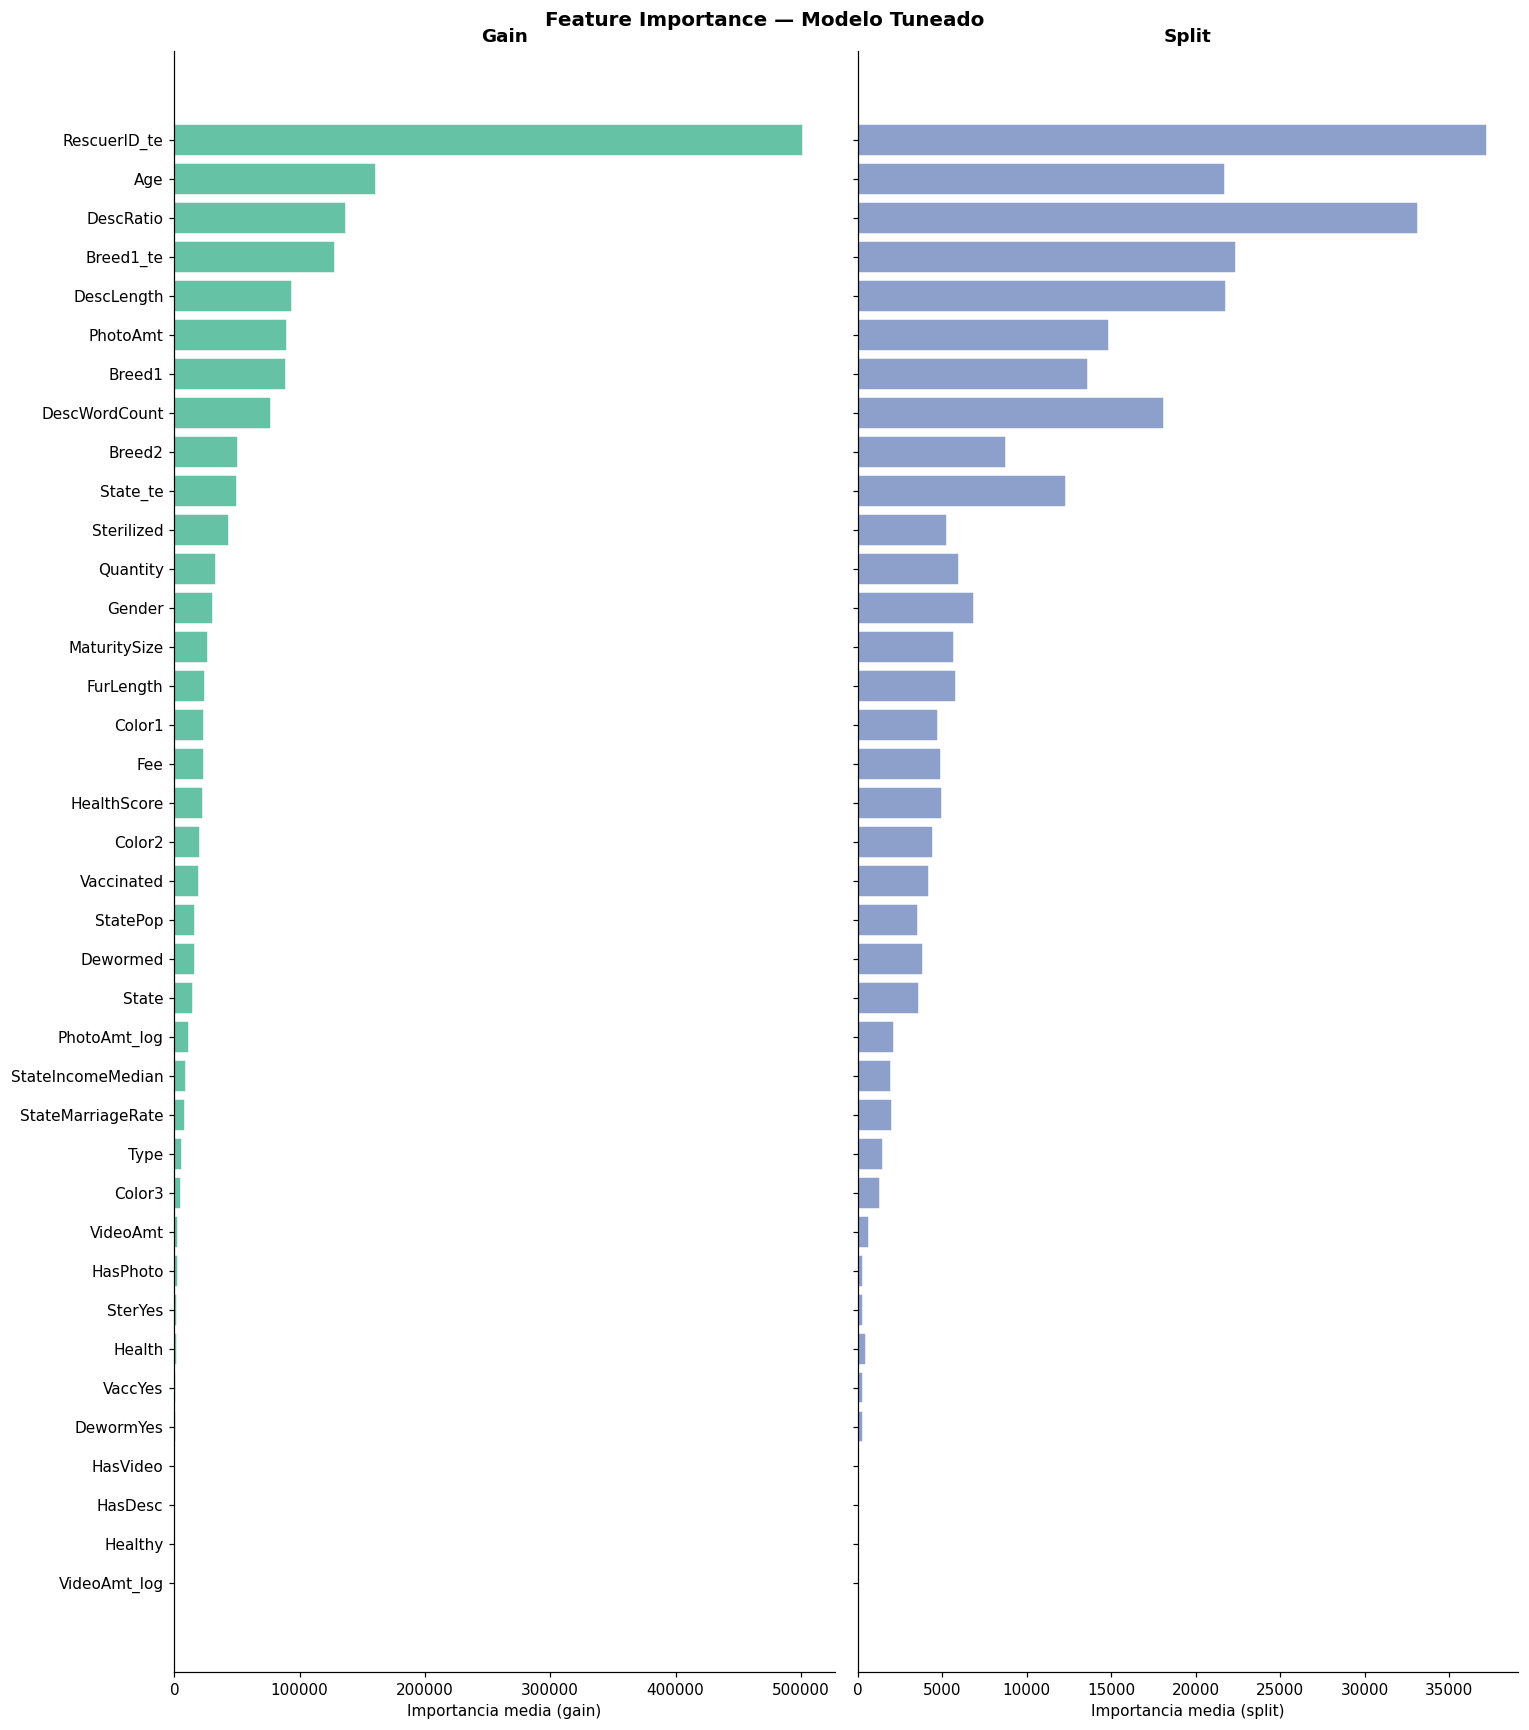

In [73]:
plot_results(y, result_tuned['oof_preds'], title='Modelo Tuneado — Resultado Final')
plot_importance(result_tuned['feat_imp'], top_n=50, title='Feature Importance — Modelo Tuneado')

---
# 6. Resumen final y análisis de errores


TABLA RESUMEN — TODOS LOS EXPERIMENTOS


,Experimento,QWK,QWK±std,Accuracy,F1 macro
0,09_tuned,0.4450,0.0130,0.4606,0.3634
1,05b_target_encoding,0.4412,0.0172,0.4603,0.3711
2,04b_breed_agg,0.3950,0.0147,0.4363,0.3571
3,04a_rescuer_agg,0.3923,0.0120,0.4365,0.3562
4,05_target_encoding,0.3901,0.0162,0.4421,0.3554
5,04c_state_agg,0.3862,0.0176,0.4349,0.3497
6,01e_health,0.3726,0.0222,0.4175,0.3332
7,01c_states,0.3693,0.0169,0.4166,0.3305
8,01b_video_photo_add,0.3684,0.0133,0.4205,0.3362
9,02_num_transforms,0.3677,0.0183,0.4184,0.3342


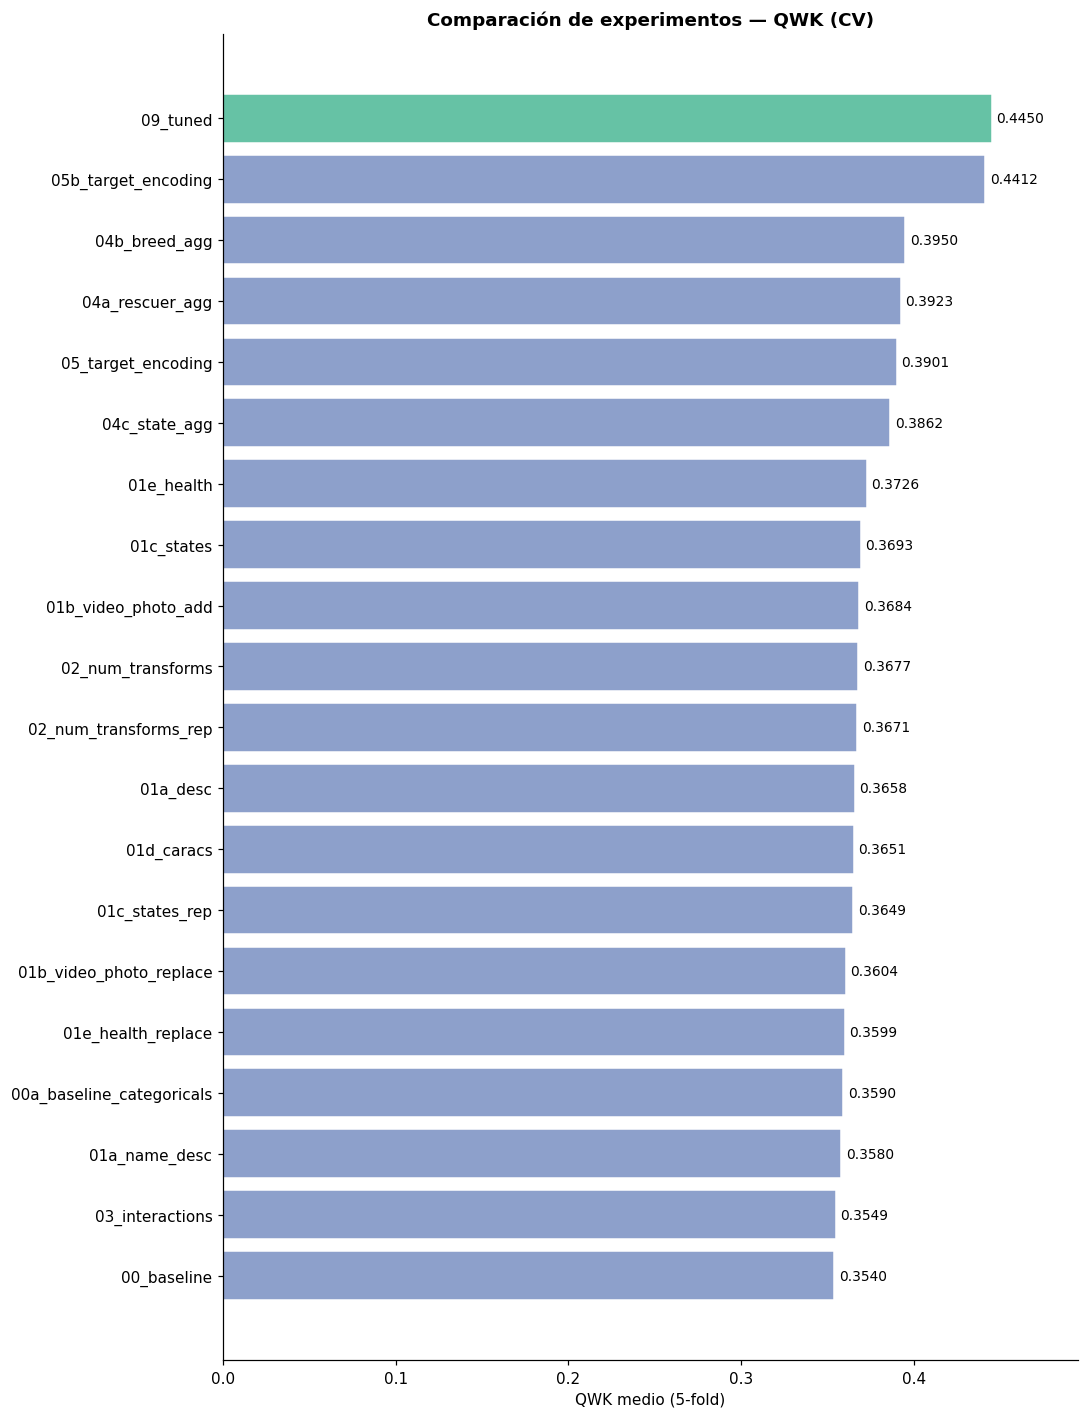

In [74]:
print('\n' + '='*55)
print('TABLA RESUMEN — TODOS LOS EXPERIMENTOS')
print('='*55)
display(tracker.table())
tracker.plot()

Distribución de errores por magnitud:
error_size
0    6900
1    4969
2    2186
3     833
4      94

Error de 0 clases (correcto): 46.1%
Error de 1 clase:             33.2%
Error de 2+ clases:           20.8%


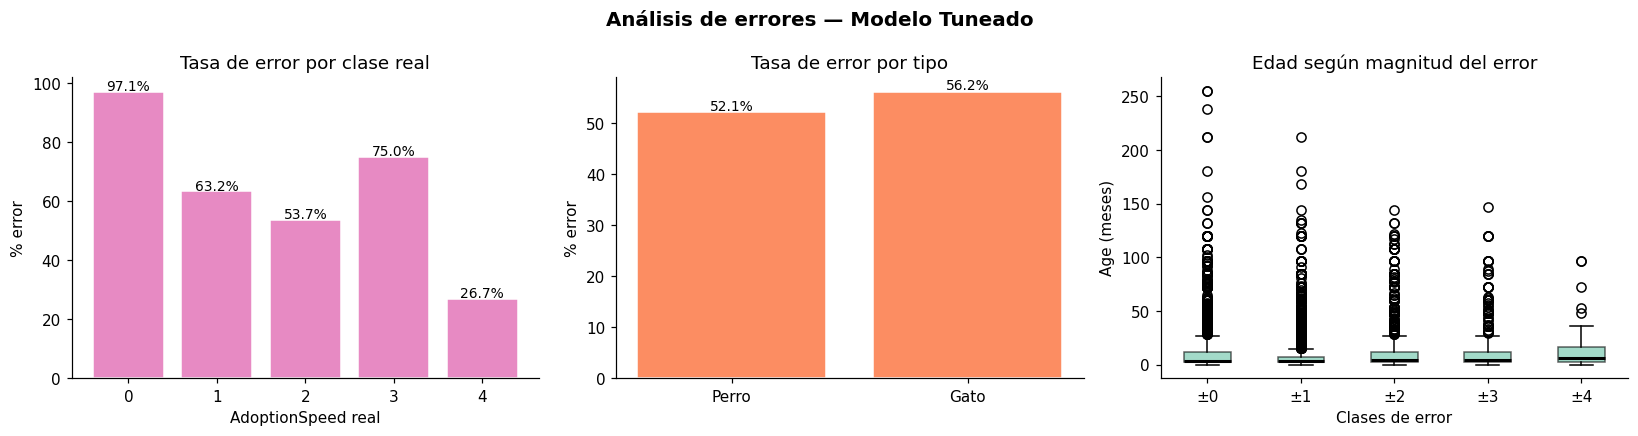

In [75]:
preds_final = result_tuned['oof_preds'].astype(int)
errors = df.copy()
errors['pred']       = preds_final
errors['error']      = (errors['pred'] != errors[TARGET]).astype(int)
errors['error_size'] = (errors['pred'] - errors[TARGET]).abs()

print('Distribución de errores por magnitud:')
print(errors['error_size'].value_counts().sort_index().to_string())
print(f'\nError de 0 clases (correcto): {(errors["error_size"]==0).mean()*100:.1f}%')
print(f'Error de 1 clase:             {(errors["error_size"]==1).mean()*100:.1f}%')
print(f'Error de 2+ clases:           {(errors["error_size"]>=2).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

err_by_class = errors.groupby(TARGET)['error'].mean() * 100
axes[0].bar(err_by_class.index, err_by_class.values, color=PALETTE[3], edgecolor='white')
axes[0].set_title('Tasa de error por clase real')
axes[0].set_xlabel('AdoptionSpeed real')
axes[0].set_ylabel('% error')
for i, v in enumerate(err_by_class.values):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)

err_by_type = errors.groupby('Type')['error'].mean() * 100
err_by_type.index = ['Perro', 'Gato']
axes[1].bar(err_by_type.index, err_by_type.values, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Tasa de error por tipo')
axes[1].set_ylabel('% error')
for i, v in enumerate(err_by_type.values):
    axes[1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)

axes[2].boxplot(
    [errors[errors['error_size']==k]['Age'].dropna() for k in [0,1,2,3,4]],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    boxprops=dict(facecolor=PALETTE[0], alpha=0.6)
)
axes[2].set_xticklabels(['±0','±1','±2','±3','±4'])
axes[2].set_title('Edad según magnitud del error')
axes[2].set_xlabel('Clases de error')
axes[2].set_ylabel('Age (meses)')

plt.suptitle('Análisis de errores — Modelo Tuneado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [76]:
# ── Threshold optimization (post-hoc) ────────────────────────────────────────
from scipy.optimize import minimize

# Obtener oof_proba usando run_cv con el pipeline completo del mejor experimento
result_final = run_cv(
    X_final, y, BEST_PARAMS,
    cat_features=FINAL_CAT_FEATURES,
    experiment_name='09_tuned_proba',    
    te_cols=FINAL_TE_COLS,       # ← calculado dentro del fold, sin leakage
    te_smoothing=FINAL_TE_SMOOTHING,
    #agg_config=FINAL_AGG_CONFIG,
    #agg_smoothing=FINAL_AGG_SMOOTHING,
    aux_cols=FINAL_AUX_COLS,
)
oof_proba = result_final['oof_proba']


def apply_thresholds(proba, thresholds):
    """Convierte probabilidades en clases usando umbrales optimizados."""
    cum_proba  = proba.cumsum(axis=1)[:, :-1]  # 4 columnas; la última siempre es 1.0
    thresholds = np.sort(thresholds)
    # Para cada fila: cuenta cuántos umbrales no superó → esa es la clase
    return (cum_proba < thresholds).sum(axis=1).astype(int)


def neg_qwk(thresholds, proba, y_true):
    thresholds = np.sort(np.clip(thresholds, 0.01, 0.99))
    return -qwk(y_true, apply_thresholds(proba, thresholds))


result_thresh  = minimize(neg_qwk, [0.2, 0.4, 0.6, 0.8], args=(oof_proba, y),
                          method='Nelder-Mead', options={'maxiter': 2000, 'xatol': 1e-4})
opt_thresholds = np.sort(np.clip(result_thresh.x, 0.01, 0.99))
preds_thresh   = apply_thresholds(oof_proba, opt_thresholds)

qwk_base_proba = qwk(y, oof_proba.argmax(axis=1))
qwk_thresh     = qwk(y, preds_thresh)

print(f'\nThresholds optimizados: {opt_thresholds.round(3)}')
print(f'QWK argmax  (sin opt.): {qwk_base_proba:.4f}')
print(f'QWK con thresholds:     {qwk_thresh:.4f}')
print(f'ΔQWK: {qwk_thresh - qwk_base_proba:+.4f}')

  Fold 1: QWK=0.4612  Acc=0.4651  F1=0.3646  (best iter=2998)
  Fold 2: QWK=0.4401  Acc=0.4625  F1=0.3556  (best iter=2982)
  Fold 3: QWK=0.4167  Acc=0.4533  F1=0.3557  (best iter=2390)
  Fold 4: QWK=0.4562  Acc=0.4653  F1=0.3652  (best iter=2998)
  Fold 5: QWK=0.4478  Acc=0.4613  F1=0.3641  (best iter=2999)

  ► 09_tuned_proba
    QWK  0.4444 ± 0.0156
    Acc  0.4615
    F1   0.3610

Thresholds optimizados: [0.24  0.352 0.489 0.52 ]
QWK argmax  (sin opt.): 0.4445
QWK con thresholds:     0.4907
ΔQWK: +0.0462


In [77]:
resumen = pd.DataFrame([
    {'Modelo': 'Baseline (sin FE)',
     'QWK': result_baseline['qwk_mean'], 'Acc': result_baseline['acc_mean'], 'F1': result_baseline['f1_mean']},
    {'Modelo': f'Mejor FE ({best_result["name"]})',
     'QWK': best_result['qwk_mean'],     'Acc': best_result['acc_mean'],     'F1': best_result['f1_mean']},
    {'Modelo': 'FE + Tuning (Optuna)',
     'QWK': result_tuned['qwk_mean'],    'Acc': result_tuned['acc_mean'],    'F1': result_tuned['f1_mean']},
    {'Modelo': 'FE + Tuning + Thresholds',
     'QWK': qwk_thresh, 'Acc': accuracy_score(y, preds_thresh), 'F1': f1_score(y, preds_thresh, average='macro')},
])
resumen[['QWK','Acc','F1']] = resumen[['QWK','Acc','F1']].round(4)

print('\n' + '='*65)
print('RESUMEN FINAL')
print('='*65)
display(resumen)

delta_total = resumen['QWK'].iloc[-1] - resumen['QWK'].iloc[0]
print(f'\nMejora total sobre baseline: ΔQWK = {delta_total:+.4f}')


RESUMEN FINAL


,Modelo,QWK,Acc,F1
0,Baseline (sin FE),0.3590,0.4127,0.3251
1,Mejor FE (04b_breed_agg),0.3950,0.4363,0.3571
2,FE + Tuning (Optuna),0.4450,0.4606,0.3634
3,FE + Tuning + Thresholds,0.4907,0.4337,0.3671



Mejora total sobre baseline: ΔQWK = +0.1317


---
# 7. Hiperparámetros finales y conclusiones

In [78]:
print('Hiperparámetros del modelo final:')
for k, v in BEST_PARAMS.items():
    if k not in ['objective','num_class','metric','verbose']:
        print(f'  {k}: {v}')

print(f'\nFeatures en el modelo final ({len(FINAL_FEATURES)}):')
for f in sorted(FINAL_FEATURES):
    print(f'  {f}')

Hiperparámetros del modelo final:
  n_estimators: 3000
  learning_rate: 0.0019560010803163887
  num_leaves: 84
  max_depth: 5
  min_child_samples: 50
  subsample: 0.6990866027292076
  bagging_freq: 2
  colsample_bytree: 0.8376518487131104
  min_sum_hessian_in_leaf: 0.0015319413849570144

Features en el modelo final (35):
  Age
  Breed1
  Breed2
  Color1
  Color2
  Color3
  DescLength
  DescRatio
  DescWordCount
  DewormYes
  Dewormed
  Fee
  FurLength
  Gender
  HasDesc
  HasPhoto
  HasVideo
  Health
  HealthScore
  Healthy
  MaturitySize
  PhotoAmt
  PhotoAmt_log
  Quantity
  State
  StateIncomeMedian
  StateMarriageRate
  StatePop
  SterYes
  Sterilized
  Type
  VaccYes
  Vaccinated
  VideoAmt
  VideoAmt_log


### Conclusiones

**Baseline** establece el piso de QWK con las features originales y HealthScore.

**Feature Engineering** — los bloques que típicamente aportan más en este dataset:
- Target encoding de `Breed1`, `State` y `RescuerID` (captura señales de alta cardinalidad)
- Transformaciones logarítmicas de `Fee`, `Age` y `PhotoAmt` (reduce el impacto de outliers)
- SVD sobre `Description` (captura semántica del texto)
- Aggregations por rescatista (captura el "estilo" de publicación)

**Tuning con Optuna** — el espacio más sensible es `num_leaves` y `learning_rate`.
`min_child_samples` controla el overfitting más que la regularización L1/L2.

**Threshold optimization** — en problemas ordinales como este, optimizar los umbrales
post-hoc casi siempre da un pequeño delta positivo de QWK sin costo adicional.

**Próximos pasos:** modelo de imágenes con embeddings preentrenados → fusión con el modelo tabular.

In [79]:
# ── 1. Cargar y preprocesar test (igual que train) ────────────────────────────
test = pd.read_csv(os.path.join(input_path, 'test/test.csv'))
df_test = test.copy()

# Limpieza de Name
df_test['Name'] = df_test['Name'].astype(str).str.lower().str.strip()
mask_name = (
    df_test['Name'].str.contains('|'.join(invalid_kw), na=False) |
    (df_test['Name'].str.len() <= 1) |
    df_test['Name'].str.match(r'^[^a-zA-Z0-9]+$') |
    df_test['Name'].str.isnumeric() |
    (df_test['Name'] == 'nan')
)
df_test.loc[mask_name, 'Name'] = np.nan

# Limpieza de Description
mask_kw    = df_test['Description'].str.lower().str.contains('|'.join(generic_phrases), na=False)
mask_short = df_test['Description'].str.len() < 40
df_test.loc[mask_kw & mask_short, 'Description'] = np.nan
df_test['Description'] = df_test['Description'].str.strip()
df_test.loc[df_test['Description'].str.len() < 5, 'Description'] = np.nan

# Merge con breeds, colors, states (igual que en train)
df_test['Type']   = df_test['Type'].astype(int)
df_test['Breed1'] = df_test['Breed1'].astype(int)
df_test['Breed2'] = df_test['Breed2'].astype(int)
df_test = df_test.merge(breeds_, left_on=['Type','Breed1'], right_on=['Type','BreedID'], how='left')
df_test.rename(columns={'BreedName': 'Breed1Name'}, inplace=True)
df_test.drop(columns=['BreedID'], inplace=True)
df_test = df_test.merge(breeds_, left_on=['Type','Breed2'], right_on=['Type','BreedID'], how='left')
df_test.rename(columns={'BreedName': 'Breed2Name'}, inplace=True)
df_test.drop(columns=['BreedID'], inplace=True)
df_test['StateName']   = df_test['State'].map(state_map)
df_test['Color1Label'] = df_test['Color1'].map(color_map)

# ── 3. Aplicar el mismo feature engineering que en df_fe ─────────────────────
# (todas las transformaciones que aplicaste para construir df_fe,
#  pero sobre df_test — flags, logs, bins, HealthScore, etc.)
# Por ejemplo:

df_test['HasPhoto']     = (df_test['PhotoAmt'] > 0).astype(int)
df_test['HasVideo']     = (df_test['VideoAmt'] > 0).astype(int)
df_test['PhotoAmt_log'] = np.log1p(df_test['PhotoAmt'])
df_test['VideoAmt_log'] = np.log1p(df_test['VideoAmt'])
df_test['StatePop']       = df_test['State'].map(malaysia_stats.set_index('StateID')['population'].to_dict())
df_test['StateIncomeMedian'] = df_test['State'].map(malaysia_stats.set_index('StateID')['income_median'].to_dict())
df_test['StateMarriageRate'] = df_test['State'].map(malaysia_stats.set_index('StateID')['marriage_rate'].to_dict())
df_test['HasDesc']       = df_test['Description'].notna().astype(int)
df_test['DescLength']    = df_test['Description'].str.len().fillna(0)
df_test['DescWordCount'] = df_test['Description'].fillna('').str.split().str.len()
df_test['DescRatio']     = df_test['DescLength'] / df_test['DescWordCount'].replace(0, np.nan)
df_test['VaccYes']   = (df_test['Vaccinated']  == 1).astype(int)
df_test['DewormYes'] = (df_test['Dewormed']    == 1).astype(int)
df_test['SterYes']   = (df_test['Sterilized']  == 1).astype(int)
df_test['Healthy']   = (df_test['Health']  == 1).astype(int)

health_map = {0: np.nan, 1: 1.0, 2: 0.5, 3: 0.0}
df_test['HealthScore'] = ( (df_test['VaccYes'] + df_test['DewormYes'] + df_test['SterYes'])/3 * 0.4 ) + (df_test['Health'].replace(health_map) * 0.6)

"""
# ── 2. Calcular las aggregations fitteadas sobre TODO el train ────────────────
# Esto reemplaza lo que run_cv hace dentro de cada fold
for group_col, aggs in FINAL_AGG_CONFIG.items():
    agg_kwargs = {
        new_name: pd.NamedAgg(column=src_col, aggfunc=func)
        for new_name, (src_col, func) in aggs.items()
    }
    agg_df = df_fe.groupby(group_col).agg(**agg_kwargs).reset_index()
    
    # Mergear a test — rescatistas nuevos en test → fillna con media de train
    df_test = df_test.merge(agg_df, on=group_col, how='left')
    for new_name in aggs.keys():
        df_test[new_name].fillna(agg_df[new_name].mean(), inplace=True)

agg_col_names = [
    new_name
    for aggs in FINAL_AGG_CONFIG.values()
    for new_name in aggs.keys()
]

FINAL_FEATURES_TEST = FINAL_FEATURES + agg_col_names
"""

# ── 3. Armar X_test ───────────────────────────────────────────────────────────
X_test = df_test[FINAL_FEATURES].copy()

for col in FINAL_CAT_FEATURES:
    if col in X_test.columns:
        X_test[col] = X_test[col].fillna(-1).astype(int)

"""
# ── 4. Reentrenar sobre todo el train ────────────────────────────────────────
X_train_full = df_fe[FINAL_FEATURES + FINAL_AUX_COLS].copy()

for group_col, aggs in FINAL_AGG_CONFIG.items():
    agg_kwargs = {
        new_name: pd.NamedAgg(column=src_col, aggfunc=func)
        for new_name, (src_col, func) in aggs.items()
    }
    agg_df = df_fe.groupby(group_col).agg(**agg_kwargs).reset_index()
    X_train_full = X_train_full.merge(agg_df, on=group_col, how='left')

# Solo dropear las aux_cols, no los group_cols que son features del modelo
cols_to_drop = [col for col in FINAL_AUX_COLS if col not in FINAL_FEATURES_TEST]
X_train_full = X_train_full.drop(columns=cols_to_drop, errors='ignore')
X_train_full = X_train_full[FINAL_FEATURES_TEST]

for col in FINAL_CAT_FEATURES:
    if col in X_train_full.columns:
        X_train_full[col] = X_train_full[col].fillna(-1).astype(int)

model_final = lgb.LGBMClassifier(**BEST_PARAMS, random_state=SEED)
model_final.fit(
    X_train_full, y,
    categorical_feature=FINAL_CAT_FEATURES or 'auto',
    callbacks=[lgb.log_evaluation(period=-1)]
)
"""
# ── 4. Reentrenar sobre todo el train ────────────────────────────────────────
X_train_full = df_fe[FINAL_FEATURES + FINAL_AUX_COLS].copy()

# Target Encoding fitteado sobre TODO el train (sin CV, porque no hay fold de val)
te_final = TargetEncoder(smooth=FINAL_TE_SMOOTHING, target_type='continuous', random_state=SEED)
te_cols_encoded = [c + '_te' for c in FINAL_TE_COLS]
X_train_full[te_cols_encoded] = te_final.fit_transform(X_train_full[FINAL_TE_COLS], y)

# Dropear aux_cols que no son features del modelo
cols_to_drop = [col for col in FINAL_AUX_COLS if col not in FINAL_FEATURES]
X_train_full = X_train_full.drop(columns=cols_to_drop, errors='ignore')

for col in FINAL_CAT_FEATURES:
    if col in X_train_full.columns:
        X_train_full[col] = X_train_full[col].fillna(-1).astype(int)

model_final = lgb.LGBMClassifier(**BEST_PARAMS, random_state=SEED)
model_final.fit(
    X_train_full, y,
    categorical_feature=FINAL_CAT_FEATURES or 'auto',
    callbacks=[lgb.log_evaluation(period=-1)]
)

# ── 5. Aplicar el mismo TE a test ─────────────────────────────────────────────
X_test = df_test[FINAL_FEATURES + FINAL_AUX_COLS].copy()
X_test[te_cols_encoded] = te_final.transform(X_test[FINAL_TE_COLS])  # solo transform, no fit
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

for col in FINAL_CAT_FEATURES:
    if col in X_test.columns:
        X_test[col] = X_test[col].fillna(-1).astype(int)

# ── 6. Predecir y generar submission ──────────────────────────────────────────
test_proba = model_final.predict_proba(X_test)
test_preds = apply_thresholds(test_proba, opt_thresholds)

submission = pd.DataFrame({
    'PetID': test['PetID'],
    'AdoptionSpeed': test_preds.astype(int)
})
submission.to_csv('submission.csv', index=False)
print(submission['AdoptionSpeed'].value_counts().sort_index())

AdoptionSpeed
0       7
1     506
2    1066
3    1044
4    1349
Name: count, dtype: int64
